In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
from myalgo import M_method_feas, M_method_opt
import pickle
from timeit import default_timer as timer
from qiskit_optimization.translators import from_docplex_mp
from docplex.mp.model_reader import ModelReader
import cvxpy as cp
from scipy.optimize import minimize
import scipy as sp
from matplotlib.colors import ListedColormap
import tqdm
# import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import os
import warnings
from collections import Counter
import glob, re, pickle, pandas as pd


import pennylane as qml
from pennylane import qaoa
from pytket.passes import AutoRebase, FullPeepholeOptimise, SequencePass, DecomposeBoxes
from qnexus.models.job_status import JobStatusEnum


from qaoa_sampling_oneshot import qaoa_sampling_oneshot, maqaoa_sampling_oneshot



## Funcs

### Old general functs

In [4]:
### general

def symmetrize(Q):
    return (Q + Q.T) / 2

def L1_norm(Q, const):
    return const + np.sum(np.abs(Q))

def L1_norm_hot(Q, const, n_bits, temperature, min_pfeas):
    return L1_norm(Q, const) + temperature * (n_bits * np.log(2) - np.log(1-min_pfeas))

def evaluate_energy(solution, Q, const):
    return const + np.dot(solution, np.dot(Q, solution))


# NPP specifics

def get_QUBO_NPP(N, P, M, seed, penalization=True, objective=True):
    """build a NPP QUBO with N integers, P partitions, M penalty factor, for problem identified with seed"""
    Q, const = np.zeros((N * P, N * P)), 0
    if objective:
        numbs = build_numbs_set(N, P, seed)
        Ho, const_o = build_obj_NPP(numbs, N, P)
        Q += Ho
        const += const_o
    if penalization:
        Hp, const_p = build_pen_NPP(N, P)
        Q += M * Hp
        const += M * const_p
    return Q, const

def build_numbs_set(N, P, seed):
    random.seed(seed)
    numbs = np.array([int(1000 * random.uniform(0.0, 1.0)) for _ in range(N)])
    total = sum(numbs)
    if numbs[-1] - (total % P) > 1:
        numbs[-1] -= total % P
    else:
        numbs[-1] += P - (total % P)
    total = sum(numbs)
    return numbs

def idx_onehot(i, p, P):
    return i * P + p

def build_obj_NPP(numbs, N, P):
    H = np.zeros((N * P, N * P))
    alpha = np.sum(numbs) / P
    for p in range(P):
        for i in range(N):
            H[idx_onehot(i, p, P), idx_onehot(i, p, P)] = numbs[i]**2 - 2*alpha*numbs[i]
            for i_prime in range(N):
                if i_prime == i:
                    continue
                H[idx_onehot(i, p, P), idx_onehot(i_prime, p, P)] = numbs[i] * numbs[i_prime]
    const = P * alpha**2
    H = symmetrize(H)
    return H, const

def build_pen_NPP(N, P):
    H = np.zeros((N * P, N * P))
    for p in range(P):
        for i in range(N):
            H[idx_onehot(i, p, P), idx_onehot(i, p, P)] = -1
            for p_prime in range(P):
                if p_prime == p:
                    continue
                H[idx_onehot(i, p, P), idx_onehot(i, p_prime, P)] = 1
    const = N
    H = symmetrize(H)
    return H, const


# TSP specific

def build_adjacency(Nc, info_instance, info_type):
    if info_type == "circle":
        # trivial construction of adj. matrix of graph with N cities on a circle. Modify this function to get more complex structures
        coordinates = [(1_000_000 * np.cos((index / Nc) * 2 * np.pi), 1_000_000 * np.sin((index / Nc) * 2 * np.pi)) for index in range(Nc)]
        distance_table = [[int(np.sqrt((coordinates[c_1][0] - coordinates[c_0][0]) ** 2 + (coordinates[c_1][1] - coordinates[c_0][1]) ** 2)) for c_0 in range(Nc)] for c_1 in range(Nc)]
    elif info_type == "seed":
        # random construction of the adjacency matrix, based on euclidian distance. (cities are uniformly randomly placed inside a square)
        seed = info_instance
        np.random.seed(seed)
        coordinates = 1e6 * np.array( [np.random.uniform(low = -1, high = 1, size = 2) for i in range(Nc)] )
        distance_table = [[int(np.sqrt((coordinates[c_1][0] - coordinates[c_0][0]) ** 2 + (coordinates[c_1][1] - coordinates[c_0][1]) ** 2)) for c_0 in range(Nc)] for c_1 in range(Nc)]
    elif info_type == "adjacency":
        distance_table = info_instance
    return np.array(distance_table)

def build_obj_TSP(distances, Nc):
    H = np.zeros((Nc**2, Nc**2))
    for t in range(Nc):
        for i in range(Nc):
            for i_prime in range(Nc):
                if i_prime != i:
                    H[idx_onehot(t, i, Nc), idx_onehot((t+1)%Nc, i_prime, Nc)] = distances[i, i_prime]
    H = symmetrize(H)
    const = 0
    return H, const

def build_pen_TSP(Nc):
    H = np.zeros((Nc**2, Nc**2))
    for t in range(Nc):
        for i in range(Nc):
            H[idx_onehot(t, i, Nc), idx_onehot(t, i, Nc)] = -2
            for i_prime in range(Nc):
                if i_prime != i:
                    H[idx_onehot(t, i, Nc), idx_onehot(t, i_prime, Nc)] += 1
            for t_prime in range(Nc):
                if t_prime != t:
                    H[idx_onehot(t, i, Nc), idx_onehot(t_prime, i, Nc)] += 1
    const = 2*Nc
    H = symmetrize(H)
    return H, const


def get_QUBO_TSP(Nc, M, info_instance, info_type, objective = True, penalization=True):
    # build a TSP QUBO with Nc cities, M penalty factor, for problem identified with seed or on a circle
    Q, const = np.zeros((Nc**2, Nc**2)), 0
    if objective:
        distances = build_adjacency(Nc, info_instance, info_type)
        Ho, const_o = build_obj_TSP(distances, Nc)
        Q += Ho
        const += const_o
    if penalization:
        Hp, const_p = build_pen_TSP(Nc)
        Q += M*Hp
        const += M*const_p
    return Q, const


# PO specific


def lower_bound_obj_PO(N, w, info_instance):
    n_bits = N*w
    directory, vseed = info_instance
    filename = f"../../data/{directory}/{n_bits}/random{vseed}_{n_bits}.lp"
    m = ModelReader.read(filename, ignore_names=True)
    qp = from_docplex_mp(m)
    n = qp.get_num_binary_vars()
    obj = qp.objective
    Q = obj.quadratic.to_array()
    L = obj.linear.to_array()

    Q_tilde = np.ndarray((n+1, n+1))
    Q_tilde[1:, 1:] = Q
    Q_tilde[0, 0] = 0
    Q_tilde[0, 1:] = .5*L.T
    Q_tilde[1:, 0] = .5*L
    X = cp.Variable((n+1, n+1), symmetric=True)
    constraints = [X >> 0]
    constraints += [X[i,i] == X[0,i] for i in range(1, n+1) ]
    constraints += [X[0,0] == 1]      ###### alternative way of imposing boundness, rather than  0 <= X_ij <= 1  for all i,j (2 previous lines)
    prob = cp.Problem(cp.Minimize(cp.trace(Q_tilde @ X)), constraints)
    prob.solve(solver = "MOSEK")
    return prob.value

def build_pen_PO(N, w):
    ''' return quadratic part and constant part of the penalization part of the hamiltonian '''
    # constraints in the formulation      Ax = b 
    A = np.array( [2**i for i in range(w-1, -1, -1)]*N )
    b = 2**w - 1
    # build [H, const] from [A, b]. easier formulation since b is scalar and A only 1 row, since there's only 1 constraint.
    H = np.outer(A, A)
    H -= 2*b*np.diag(A)
    const = b**2
    H = symmetrize(H)
    return H, const

def get_PO_obj(n_bits, info_instance):
    directory, vseed = info_instance
    filename = f"../../data/{directory}/{n_bits}/random{vseed}_{n_bits}.lp"
    m = ModelReader.read(filename, ignore_names=True)
    qp = from_docplex_mp(m)
    obj = qp.objective
    Q = obj.quadratic.to_array()
    L = obj.linear.to_array()
    Q = symmetrize(Q)
    return Q, L

def get_QUBO_PO(N, w, M, info_type, info_instance, objective = True, penalization=True):
    ''' build a PO QUBO with N stocks, w qubits per stock, M penalty factor, for problem identified with seed '''
    Q, const = np.zeros(((N*w), (N*w))), 0
    if objective:
        if info_type == "seed":
            Q_o, L_o = get_PO_obj(N*w, info_instance)
            Q += Q_o + np.diag(L_o)
        else:
            raise ValueError(f"info_type = {info_type} not understood for PO instance")
    if penalization:
        Hp, const_p = build_pen_PO(N, w)
        Q += M*Hp
        const += M*const_p
    return Q, const

In [5]:
def fit_temp_from_histograms(
    sd_eners, eners_qaoa, bins=50,
    use_probs=False, probs_qaoa=None, Q=None, const=None,
    n_retries=6, verbose=False
):
    """
    Fit an effective Gibbs temperature T* such that:
        p_model(E) ∝ g(E) * exp(-(E - E_min) / T*)
    matches the target distribution (exact QAOA probs or empirical samples).

    Returns
    -------
    temp_opt   : float, best-fit temperature
    bin_edges  : array
    model_hist : normalised model probabilities per bin
    qaoa_hist  : normalised target probabilities per bin
    result     : OptimizeResult (for diagnostics)
    """
    # ── 1. shared bin edges ──────────────────────────────────────────────
    all_eners = np.concatenate([sd_eners, eners_qaoa])
    bin_edges = np.histogram_bin_edges(all_eners, bins=bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    emin = bin_edges[0]                     # use the global min, not sample min

    # ── 2. spectral density (prior) ──────────────────────────────────────
    sd_counts, _ = np.histogram(sd_eners, bins=bin_edges)
    sd_counts = sd_counts.astype(float)

    # ── 3. target distribution ───────────────────────────────────────────
    if use_probs:
        assert probs_qaoa is not None and Q is not None and const is not None
        n_qubits, _ = np.shape(Q)           # local variable, no shadowing
        state_energies = np.array([
            evaluate_energy(state_inttobin(i, n_qubits), Q, const)
            for i in range(2**n_qubits)
        ])
        bin_idx = np.clip(np.digitize(state_energies, bin_edges) - 1,
                          0, len(bin_centers) - 1)
        qaoa_prob = np.zeros(len(bin_centers))
        np.add.at(qaoa_prob, bin_idx, probs_qaoa)   # vectorised accumulation
    else:
        counts, _ = np.histogram(eners_qaoa, bins=bin_edges)
        qaoa_prob = counts / counts.sum()

    # guard against all-zero target
    if qaoa_prob.sum() == 0:
        raise ValueError("Target distribution is all-zero — check inputs.")

    # ── 4. model & loss ──────────────────────────────────────────────────
    def model_prob(log_temp):
        temp = np.exp(log_temp)
        # subtract max for numerical stability before exp
        log_w = -(bin_centers - emin) / temp
        log_w -= log_w.max()
        weights = np.exp(log_w) * sd_counts
        Z = weights.sum()
        return weights / Z if Z > 0 else np.zeros_like(weights)

    def loss_kl(log_temp):
        p = model_prob(log_temp[0])
        # KL(qaoa ‖ model)  — only where both are positive
        # clamp p to avoid log(qaoa/p) overflow when p is subnormal but nonzero
        p = np.clip(p, 1e-300, None)
        mask = qaoa_prob > 0
        if not mask.any():
            return 1e12                     # no overlap → huge penalty
        return float(np.sum(qaoa_prob[mask] * np.log(qaoa_prob[mask] / p[mask])))

    # ── 5. smart initial guesses ─────────────────────────────────────────
    # Primary: match variance of Gibbs on flat DOS to variance of target
    #   Var[E]_Gibbs ≈ T^2  →  T_init ≈ std(E_target)
    if use_probs:
        mean_e = np.dot(qaoa_prob, bin_centers)
        var_e  = np.dot(qaoa_prob, (bin_centers - mean_e)**2)
    else:
        var_e = np.var(eners_qaoa)
    t_var = max(np.sqrt(var_e), 1e-3)

    # Spread initial conditions over several decades around that estimate
    log_t_center = np.log(t_var)
    offsets = [0.0, 1.5, -1.5, 3.0, -3.0, 5.0]   # log-scale offsets
    x0_candidates = [log_t_center + d for d in offsets[:n_retries]]

    # ── 6. multi-start optimisation ──────────────────────────────────────
    best_result = None
    best_loss   = np.inf

    for x0 in x0_candidates:
        try:
            res = minimize(
                loss_kl, x0=[x0],
                method="Nelder-Mead",       # gradient-free; robust for 1-D
                options={"xatol": 1e-6, "fatol": 1e-8, "maxiter": 5000},
            )
            # accept only if converged and finite
            if res.fun < best_loss and np.isfinite(res.fun):
                best_loss   = res.fun
                best_result = res
                if verbose:
                    print(f"  x0={x0:.2f} → T={np.exp(res.x[0]):.4g}, KL={res.fun:.4g}")
        except Exception as e:
            if verbose:
                print(f"  x0={x0:.2f} failed: {e}")

    if best_result is None or not best_result.success:
        import warnings
        warnings.warn(
            f"Temperature fit may not have converged (best KL={best_loss:.4g}). "
            "Consider widening n_retries or checking your energy scale."
        )

    temp_opt  = np.exp(best_result.x[0])
    model_out = model_prob(best_result.x[0])
    return temp_opt, bin_edges, model_out, qaoa_prob, best_result

### QAOA-M

In [6]:

from pennylane import numpy as pl_np  # PennyLane's numpy wrapper (supports requires_grad)


def temperature_from_layers(p, N):
    return (2.8*p/(N**(3/2)))**-1

def layers_from_temperature(T, N):
    return N**(3/2) / (2.8*T)

def combine_obj_pen(popul, qaoa_samples, M):
    assert np.sum(popul[:,2]) == qaoa_samples

    ener_ls = []
    len_states, _ = np.shape(popul)
    for i in range(len_states):
        e = popul[i, 0] + M*popul[i, 1]
        ener_ls += int(popul[i,2])*[e]
    assert len(ener_ls) == qaoa_samples
    return ener_ls

def spectral_density(Q, const):
    n, _ = np.shape(Q)
    ener = np.array([ evaluate_energy(state_inttobin(i, n), Q, const) for i in range(2**n)])
    return ener

def state_inttobin(i, n):
    state_string = bin(i)[2:].zfill(n)
    return [int(b) for b in state_string]




# ──────────────────────────────────────────────
#   Main function
# ──────────────────────────────────────────────
def run_qaoa_with_solution(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    init_params=None,            # NEW: warm-start, shape (2, p); None → linear ramp + noise
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    mixer_weights=None,             # NEW: array of length num_qubits; None → standard X-mixer
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt:float = 1e-4,
) -> dict:
    """
    Run QAOA on a QUBO problem and return samples from the optimised circuit.

    The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
    Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

    Args:
        qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
                     Diagonal entries (i==i) are linear coefficients.
                     Off-diagonal entries can be upper-triangular or full;
                     symmetric duplicates are handled correctly.
        num_qubits : number of binary variables (= problem size n)
        p          : QAOA depth — number of (cost + mixer) layer pairs
        steps      : Adam optimisation steps
        stepsize   : Adam learning rate
        n_samples  : shots for final sampling from the optimised circuit
        seed       : RNG seed for reproducibility (None = random)
        verbose    : print cost every 10 steps

    Returns a dict with keys:
        "best_bitstring" : str   — bitstring of highest-probability basis state
        "best_x"         : list  — binary vector corresponding to best_bitstring
        "params"         : array — optimised [gammas, betas] of shape (2, p)
        "counts"         : dict  — {bitstring: count} from n_samples shots
        "cost_history"   : list  — cost value recorded every 10 steps
    """

    # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
    # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
    #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
    #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j: # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else: # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))
    cost_h  = qml.simplify( qml.dot(coeffs, obs) )

    # ── 1b. Build mixer Hamiltonian ────────────────────────────────
    if mixer_weights is None:
        mixer_h = qaoa.x_mixer(range(num_qubits))
    else:
        w = np.asarray(mixer_weights, dtype=float)
        if w.shape != (num_qubits,):
            raise ValueError(
                f"mixer_weights must have length num_qubits={num_qubits}, "
                f"got shape {w.shape}"
            )
        if np.any(w <= 0):
            raise ValueError("mixer_weights must be strictly positive")
        # Normalise so mean(w) = 1 → overall mixing scale comparable to standard X-mixer
        w_norm = w / np.mean(w)
        mixer_h = qml.simplify(
            qml.dot(w_norm.tolist(), [qml.PauliX(i) for i in range(num_qubits)])
        )
        if verbose:
            print(f"  Weighted mixer: raw w = {w.tolist()}")
            print(f"                  normalised w = {np.round(w_norm, 4).tolist()}")


    # ── 2. Devices ────────────────────────────────────────────────────────────
    dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

    # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
    def qaoa_ansatz(gammas, betas):
        # Equal superposition starting state  |+⟩^n
        for wire in range(num_qubits):
            qml.Hadamard(wires=wire)
        # Alternating cost / mixer layers
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)
            qaoa.mixer_layer(betas[layer], mixer_h)

    # ── 4. QNodes ─────────────────────────────────────────────────────────────
    @qml.qnode(dev_sv)
    def cost_node(params):
        """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
        qaoa_ansatz(params[0], params[1])
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(params):
        """Returns the full 2^n probability vector (exact, no shots)."""
        qaoa_ansatz(params[0], params[1])
        return qml.probs(wires=range(num_qubits))
    
    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(params):
        """Draws shots from the optimised circuit and returns counts."""
        qaoa_ansatz(params[0], params[1])
        return qml.counts(wires=range(num_qubits))

    # ── 5. Parameter initialisation: input-give orlinear ramp heuristic ──────────────────
    if init_params is not None:
        init_params = np.asarray(init_params, dtype=float)
        if init_params.shape != (2, p):
            raise ValueError(
                f"init_params shape {init_params.shape} doesn't match (2, p) = (2, {p})"
            )
        params = pl_np.array(init_params.copy(), requires_grad=True)
    else: # Empirically good starting point: γ small→large, β large→small
        rng    = np.random.default_rng(seed)
        noise  = rng.uniform(-0.05, 0.05, size=(2, p))   # tiny noise to break symmetry
        init_gammas = np.linspace(0.01, 1, p) + noise[0]
        init_betas  = np.linspace(1, 0.01, p) + noise[1]
        params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

    # ── 6. Optimisation ───────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_params = None
    best_cost = np.inf 

    epsilon = tolerance_opt
    step_check = 10
    for step in range(steps):
        params, cost_val = optimizer.step_and_cost(cost_node, params)
        if cost_val < best_cost:
            best_cost = cost_val
            best_params = params.copy()

        # cost_history.append(float(cost_val))
        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
            if len(cost_history)>1:
                diff_10 = np.abs(cost_history[-2] - cost_history[-1])
                if diff_10 < epsilon:
                    print(f"...breaking at iteration {step} out of {steps}")
                    break


    # ── 7. Draw samples (& extract best state)─────────────────────────────────
    probs = np.array(prob_node(best_params))

    # best_idx       = int(np.argmax(probs))
    # best_bitstring = format(best_idx, f"0{num_qubits}b")
    # best_x         = [int(b) for b in best_bitstring]
    # if verbose:
    #     print(f"\n  Best bitstring : {best_bitstring}")
    #     print(f"  Best x vector  : {best_x}")
    #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

    params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
    if draw_samples:
        counts = sample_node(params)
        return params, counts, probs, float(best_cost)
    else:
        return params, probs, float(best_cost)
    





def build_qaoa_ansatz_from_pars(Q, n, p, params):
    """
    Build ONLY the QAOA circuit function from already-trained parameters, no device,
    no simulation, no probability vector. Returns `full_circuit`, a zero-arg callable
    that applies the gates (+state preparation + p layers of cost + X mixer), meant to
    be dropped inside your own QNode / drawer / transpiler.
    """
    Q = np.asarray(Q, float)
    n = int(n)
    params = np.asarray(params, float).ravel()
    gammas, betas = params[:p], params[p:]

    qubo_dict = {idx: val for idx, val in np.ndenumerate(Q) if not np.isclose(val, 0)}
    # QUBO -> Ising (x_i = (1 - z_i)/2)
    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j: # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else: # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))
    cost_h  = qml.simplify( qml.dot(coeffs, obs) )
    mixer_h = qaoa.x_mixer(range(n))

    def state_prep():
        for wire in range(n):
            qml.Hadamard(wires=wire)

    def qaoa_layers(gammas=gammas, betas=betas):
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)                
            qaoa.mixer_layer(betas[layer], mixer_h)

    def full_circuit():
        state_prep()
        qaoa_layers(gammas, betas)

    return full_circuit









def select_normalization(Q_pen, const_pen, Q_obj, const_obj): # TODO: refine this
    max_all = np.max(np.abs(Q_pen + Q_obj + const_obj + const_pen))
    frob =  np.linalg.norm(Q_pen + Q_obj + const_obj + const_pen, ord = 'fro')
    spectral = np.linalg.norm(Q_pen + Q_obj + const_obj + const_pen, ord = 2)
    # print(f"Norms: max = {max_all}\t frob = {frob}\t spectral = {spectral}")
    return spectral

In [7]:
### normalized temperature and pipeline

def qaoa_sampling(problem_type, N_idx, info_instance, Mstrategy, eta_required, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
    temperature_normalized = temperature_from_layers(layers, n_bits)
    norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
    temperature_unnormalized = norm_guess * temperature_normalized

    beta = 1 / temperature_unnormalized
    min_pfeas = eta_required  # eta
    peak_max = 4 # 4 for NPP and TSP, 9 for PO
    if problem_type == "PO":
        E_LB = lower_bound_obj_PO(N, w, info_instance)
        peak_max = 25
    else:
        E_LB = 0
    if Mstrategy == "optimality":
        E_f = select_Ef(problem_type, N_idx)
        M_star, eta_guaranteed = M_method_opt(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_f, E_LB, log_stable = True)
    elif Mstrategy == "feasibility":
        M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temperature_unnormalized, min_pfeas)
    # print(f"With an instance with {n_bits} bits, {layers} layers and (thus) est. temp. (UNnorm) {np.round(temperature_unnormalized, 3)} [norm -> {np.round(temperature_normalized, 3)}], the appropriate M is {M_star}")
    # print(f"With an instance with {n_bits} bits, {layers} layers, M* is {M_star}, M_L1 is {M_L1}")
    # print(f"M choice from old strategy is {M_star}, norm guess is {norm_guess}; M_L1 is {M_L1}")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M_star, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M_star, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M_star, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")

    # Normalizing Q according to the temperature scaling we did in step 2
    Q_norm, const_norm = Q/norm_guess, const/norm_guess

    ## Re-normalizing Q
    norm_final = np.max(np.abs(Q_norm))
    Q_norm, const_norm = Q_norm/norm_final, const_norm/norm_final

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, draw_samples=True)

    ### 4. From [LCBO, X] computed sampled energies [E_o, E_p](both objective and penalization)
    eners = np.ndarray((len(states), 3))  # second index discriminate obj=0 energy and pen=1 energy, and the number of those states for idx=2
    for i, x in enumerate(states):
        x_list = [int(j) for j in x]
        eners[i, 0] = evaluate_energy(x_list, Q_obj, const_obj)
        eners[i, 1] = evaluate_energy(x_list, Q_pen, const_pen)
        eners[i, 2] = states[x]

    ### 5. From [E_o, E_p] compute \eta_{effective} from samples
    if Mstrategy == "feasibility":
        eta_eff = np.sum( np.isclose(eners[:, 1], 0)*eners[:, 2]) / qaoa_samples
    elif Mstrategy == "optimality":
        eta_eff = np.sum( np.logical_and(np.isclose(eners[:, 1], 0), eners[:, 0] <= E_f) * eners[:, 2] ) / qaoa_samples

    eta_eff_exact = 0
    if Mstrategy == "feasibility":
        for i in range(2**n_bits):
            if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
                eta_eff_exact += probs_qaoa[i]
    elif Mstrategy == "optimality":
        for i in range(2**n_bits):
            if np.logical_and(  np.isclose(  evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0)  ,  evaluate_energy(state_inttobin(i, n_bits), Q_obj, const_obj) <= E_f   ):
                eta_eff_exact += probs_qaoa[i]


    #print(f"Recommended M for strategy: {Mstrategy} is \t {M_star}")
    print(f"Etas: req = {np.round(eta_required, 3)} \t gua = {np.round(eta_guaranteed, 3)} \t eff_ex = {np.round(eta_eff_exact, 3)}")

    t2 = timer()
    if print_time:
        print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")

    # fill up results dictionary
    results = {}
    results["eta_req"] = eta_required
    results["layers"] = layers
    results["n_bits"] = n_bits
    results["eta_eff_ex"] = eta_eff_exact
    results["norm_guess"] = norm_guess
    results["norm_final"] = norm_final
    results["temperature_norm"] = temperature_normalized
    results["energies_samples"] = eners
    results["probability_states"] = probs_qaoa
    results["M_star"] = M_star
    results["QUBO"] = (Q, const)
    return results

### Circuit translation and compiling

In [8]:
from pytket import OpType
from pytket.circuit import QControlBox, Op
from pytket import Circuit as pCircuit
from pytket.passes import (
    RemoveRedundancies, CommuteThroughMultis,
    SquashCustom, AutoRebase, DecomposeBoxes,
    SequencePass,
)
import qnexus as qnx
from pathlib import Path
from pytket.extensions.quantinuum import QuantinuumBackend
from datetime import datetime



# Pure single-qubit, parameter-free gates
SIMPLE_GATES = {
    "Hadamard": OpType.H,
    "PauliX":   OpType.X,
    "PauliY":   OpType.Y,
    "PauliZ":   OpType.Z,
    "S":        OpType.S,
    "T":        OpType.T,
    "Adjoint(S)": OpType.Sdg,
    "Adjoint(T)": OpType.Tdg,
    "SX":       OpType.SX,
}

# Parameter-free 2-qubit gates
TWO_QUBIT_GATES = {
    "CNOT":   OpType.CX,
    "CZ":     OpType.CZ,
    "CY":     OpType.CY,
    "SWAP":   OpType.SWAP,
    "ISWAP":  OpType.ISWAP,
}

# Parameter-free 3-qubit gates
THREE_QUBIT_GATES = {
    "Toffoli": OpType.CCX,
    "CSWAP":   OpType.CSWAP,
}

# Single-qubit rotations: PennyLane name -> pytket OpType
ROTATIONS = {
    "RX": OpType.Rx,
    "RY": OpType.Ry,
    "RZ": OpType.Rz,
    "PhaseShift": OpType.U1,    # PhaseShift(phi) = U1(phi) in pytket
}

# Two-qubit rotations (parametric)
TWO_QUBIT_ROTATIONS = {
    "IsingXX": OpType.XXPhase,
    "IsingYY": OpType.YYPhase,
    "IsingZZ": OpType.ZZPhase,
}

# Controlled rotations: PennyLane name -> base pytket OpType
# These are 2-qubit controlled gates with 1 parameter.
CONTROLLED_ROTATIONS = {
    "CRX": OpType.Rx,
    "CRY": OpType.Ry,
    "CRZ": OpType.Rz,
    "ControlledPhaseShift": OpType.U1,
}



def pennylane_op_to_tket(op, circ):
    """Add a single PennyLane operation to a pytket Circuit (in place)."""

    name = op.name
    wires = [int(w) for w in op.wires]


    # # Debug print — REMOVE after fixing
    # print(f"  translating: name={name!r}, "
    #       f"wires={wires}, "
    #       f"params_count={len(op.parameters)}, "
    #       f"has_control_wires={hasattr(op, 'control_wires')}, "
    #       f"has_target_wires={hasattr(op, 'target_wires')}")
    # # if hasattr(op, 'control_wires'):
    # #     print(f"    control_wires={list(op.control_wires)}")

    # if hasattr(op, 'control_wires'):
    #     print(f"    control_wires={list(op.control_wires)}")


    # --- Parameter-free gates ---
    if name in SIMPLE_GATES:
        circ.add_gate(SIMPLE_GATES[name], wires)
        return
    if name in TWO_QUBIT_GATES:
        circ.add_gate(TWO_QUBIT_GATES[name], wires)
        return
    if name in THREE_QUBIT_GATES:
        circ.add_gate(THREE_QUBIT_GATES[name], wires)
        return

    # --- Single-qubit rotations (pytket angles are in units of π) ---
    if name in ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        circ.add_gate(ROTATIONS[name], angle, wires)
        return

    # --- Two-qubit rotations ---
    if name in TWO_QUBIT_ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        circ.add_gate(TWO_QUBIT_ROTATIONS[name], angle, wires)
        return
    

    # --- MultiRZ: dispatch on number of wires ---
    if name == "MultiRZ":
        angle = float(op.parameters[0]) / np.pi
        if len(wires) == 1:
            circ.add_gate(OpType.Rz, angle, wires)
        elif len(wires) == 2:
            circ.add_gate(OpType.ZZPhase, angle, wires)
        else:
            raise NotImplementedError(
                f"MultiRZ on {len(wires)} wires; needs decomposition."
            )
        return

    # --- Controlled rotations: control is wires[0], target is wires[1] ---
    if name in CONTROLLED_ROTATIONS:
        angle = float(op.parameters[0]) / np.pi
        base_op = Op.create(CONTROLLED_ROTATIONS[name], angle)
        circ.add_gate(QControlBox(base_op, n_controls=1), wires)
        return

    # --- Generic controlled gates (qml.ctrl(...) wrappers) ---
    # These appear with name="C(<basename>)" or similar in PennyLane's tape.
    if name.startswith("C(") and name.endswith(")"):
        # E.g. "C(RY)" -> base name "RY", 1 control.
        base_name = name[2:-1]
        n_controls = len(op.control_wires)
        _add_controlled(circ, base_name, op.parameters, wires, n_controls)
        return

    # PennyLane's qml.ctrl can also produce "Controlled(Op)" form
    if name.startswith("Controlled"):
        # E.g. "ControlledQubitUnitary"
        if name == "ControlledQubitUnitary":
            from pytket.circuit import Unitary1qBox, Unitary2qBox
            n_controls = len(op.control_wires) if hasattr(op, "control_wires") else 1
            target = wires[n_controls:]
            controls = wires[:n_controls]
            matrix = np.asarray(op.parameters[0])
            box_cls = Unitary1qBox if len(target) == 1 else Unitary2qBox
            circ.add_gate(
                QControlBox(Op.create(box_cls(matrix)), n_controls=n_controls),
                controls + target,
            )
            return

    # --- Arbitrary unitaries (e.g. from qml.QubitUnitary or qml.StatePrep) ---
    if name == "QubitUnitary":
        from pytket.circuit import Unitary1qBox, Unitary2qBox
        matrix = np.asarray(op.parameters[0])
        if len(wires) == 1:
            circ.add_gate(Unitary1qBox(matrix), wires)
        elif len(wires) == 2:
            circ.add_gate(Unitary2qBox(matrix), wires)
        else:
            raise NotImplementedError(f"QubitUnitary on {len(wires)} wires not supported")
        return
    
    if name == "MultiControlledX":
        n_controls = len(op.control_wires)
        base = Op.create(OpType.X)
        circ.add_gate(QControlBox(base, n_controls=n_controls), wires)
        return

    raise NotImplementedError(
        f"No translation for {name} on wires {wires}. "
        f"Add it to the appropriate dict in pennylane_op_to_tket."
    )


def _add_controlled(circ, base_name, parameters, all_wires, n_controls):
    """Helper: build a QControlBox around a base gate by name."""
    controls = all_wires[:n_controls]
    targets  = all_wires[n_controls:]

    if base_name in SIMPLE_GATES:
        base = Op.create(SIMPLE_GATES[base_name])
    elif base_name in ROTATIONS:
        angle = float(parameters[0]) / np.pi
        base = Op.create(ROTATIONS[base_name], angle)
    elif base_name in TWO_QUBIT_ROTATIONS:
        angle = float(parameters[0]) / np.pi
        base = Op.create(TWO_QUBIT_ROTATIONS[base_name], angle)
    elif base_name in TWO_QUBIT_GATES:
        base = Op.create(TWO_QUBIT_GATES[base_name])
    else:
        raise NotImplementedError(
            f"Cannot wrap {base_name} as a controlled gate; add it to a base dict."
        )

    circ.add_gate(QControlBox(base, n_controls=n_controls), controls + targets)


def circuit_to_tape(circuit_fn):
    with qml.tape.QuantumTape() as tape:
        circuit_fn()
    return tape


def Trans_qml_to_tket(full_circuit, n_qubits):
    """Translate a PennyLane Circuit direclty to a pytket Circuit"""
    tape = circuit_to_tape(full_circuit)
    
    # Gates we can translate directly
    translatable = {
        *SIMPLE_GATES, *TWO_QUBIT_GATES, *THREE_QUBIT_GATES,
        *ROTATIONS, *TWO_QUBIT_ROTATIONS, *CONTROLLED_ROTATIONS,
        "MultiControlledX", "QubitUnitary",
    }
    # Expand high-level gates (ApproxTimeEvolution, cost_layer, etc.)
    expanded = tape.expand(depth=10, stop_at=lambda op: op.name in translatable)
    
    circ = pCircuit(n_qubits)
    for op in expanded.operations:
        pennylane_op_to_tket(op, circ)
    return circ


def Compile_tket_local(tket_circ, verbose = False, cheap = False):
    """     Local compilation (it does evetything get_compiled_circuit(optimisation_level=2) does, minus the live calibration data) """
    if verbose:
        print("Pre-comp:\t", tket_circ.n_1qb_gates(), "1q gates\t", tket_circ.n_2qb_gates(), "2q gates\t", tket_circ.depth(), "depth")

    H_SERIES_GATESET = {OpType.ZZPhase, OpType.PhasedX, OpType.Rz}

    if cheap:
        pipeline = SequencePass([
        DecomposeBoxes(),
        AutoRebase(H_SERIES_GATESET),
        RemoveRedundancies(),
        CommuteThroughMultis(),
        RemoveRedundancies(),
        ])
    else:
        pipeline = SequencePass([
        DecomposeBoxes(),                       # flatten any high-level boxes
        AutoRebase(H_SERIES_GATESET),           # rewrite to native gates
        FullPeepholeOptimise(),                 # optimize in native basis
        ])
    pipeline.apply(tket_circ)

    if verbose:
        print("Post-comp:\t", tket_circ.n_1qb_gates(), "1q gates\t", tket_circ.n_2qb_gates(), "2q gates\t", tket_circ.depth(), "depth")
    return tket_circ


def Compile_tket_qnexus(
    tket_circ,
    device_name="H2-1E",
    project_name="qaoa_compile",
    optimisation_level=2,
    save_to_disk=True,
    wait_server = False,
):
    """
    Upload a pytket circuit to Quantinuum's cloud and compile it server-side.
    Returns the compiled pytket Circuit.
    """
    # 1. Get or create a project namespace
    project = qnx.projects.get_or_create(name=project_name)

    # 2. Backend config
    backend_config = qnx.QuantinuumConfig(
        device_name=device_name,
        no_opt=False,                   # let optimisation_level do its work
        allow_2q_gate_rebase=True,      # CNOT -> ZZPhase etc.
        simplify_initial=True,          # pre-pass simplification
    )

    # 3. Upload circuit (gets a reference handle)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    circuit_ref = qnx.circuits.upload(
        name=f"circ_{timestamp}",
        circuit=tket_circ,
        project=project,
    )

    # 4. Start compile job (runs on Quantinuum's servers)
    compile_job = qnx.start_compile_job(
        programs=[circuit_ref],
        name=f"compile_{project_name}_{timestamp}",
        optimisation_level=optimisation_level,
        backend_config=backend_config,
        project=project,
    )
    print("Sent compilation request..")

    # Optional: save the job reference to disk so you can resume later
    path=Path.cwd() / "quantinuum_jobs" / f"compile_{project_name}_{timestamp}"
    if save_to_disk:
        qnx.filesystem.save(
            ref=compile_job,
            path=path,
            mkdir=True,
        )

    if wait_server:
        # 5. Block until compilation finishes
        qnx.jobs.wait_for(compile_job, timeout=None)
        print("..compilation finished.")

        # 6. Download the compiled circuit
        compiled_ref = qnx.jobs.results(compile_job)[0].get_output()
        compiled_circ = compiled_ref.download_circuit()
        return compiled_circ
    
    else:
        print(".. check back later in ", path)
        return path



def check_job_compilation(path):
    ''' Check if a Qnexus submitted compilation is done '''
    compile_job = qnx.filesystem.load(path=path)
    if qnx.jobs.status(compile_job).status == "COMPLETED":
        compiled_circ = qnx.jobs.results(compile_job)[0].get_output().download_circuit()
        return compiled_circ
    else:
        print("Job is not completed yet, it is ", qnx.jobs.status(compile_job).status)


def Compile_tket_locally_wbackend(
    circ,
    device_name="H2-2",
    optimisation_level=3,
    timeout=900,
    target_2qb_gate=OpType.ZZPhase,
    verbose=True,
):
    """
    Locally compile a pytket Circuit for Quantinuum H2 native gates.

    Native target:
        1q: PhasedX, Rz
        2q: ZZPhase by default

    This uses QuantinuumBackend.default_compilation_pass internally,
    so it is much better than manually calling generic pytket passes.
    """
    backend = QuantinuumBackend(device_name=device_name)
    backend.set_compilation_config_target_2qb_gate(target_2qb_gate) # preserve/use parameterized RZZ as native ZZPhase.

    before = {
        "total": circ.n_gates,
        "CX": circ.n_gates_of_type(OpType.CX),
        "TK1": circ.n_gates_of_type(OpType.TK1),
        "PhasedX": circ.n_gates_of_type(OpType.PhasedX),
        "Rz": circ.n_gates_of_type(OpType.Rz),
        "ZZPhase": circ.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": circ.n_gates_of_type(OpType.ZZMax),
        "TK2": circ.n_gates_of_type(OpType.TK2),
        "S": circ.n_gates_of_type(OpType.S),
        "Sdg": circ.n_gates_of_type(OpType.Sdg),
    }

    compiled = backend.get_compiled_circuit(
        circ,
        optimisation_level=optimisation_level,
        timeout=timeout,
    )

    after = {
        "total": compiled.n_gates,
        "CX": compiled.n_gates_of_type(OpType.CX),
        "TK1": compiled.n_gates_of_type(OpType.TK1),
        "PhasedX": compiled.n_gates_of_type(OpType.PhasedX),
        "Rz": compiled.n_gates_of_type(OpType.Rz),
        "ZZPhase": compiled.n_gates_of_type(OpType.ZZPhase),
        "ZZMax": compiled.n_gates_of_type(OpType.ZZMax),
        "TK2": compiled.n_gates_of_type(OpType.TK2),
        "S": compiled.n_gates_of_type(OpType.S),
        "Sdg": compiled.n_gates_of_type(OpType.Sdg),
    }

    if verbose:
        print("Before:")
        for k, v in before.items():
            print(f"  {k:8s}: {v}")

        print("\nAfter:")
        for k, v in after.items():
            print(f"  {k:8s}: {v}")

        print("\nBackend valid:", backend.valid_circuit(compiled))

    if not backend.valid_circuit(compiled):
        print("\nInvalid circuit. Predicate diagnostics:")
        for pred in backend.required_predicates:
            ok = pred.verify(compiled)
            print(f"  {pred}: {ok}")

    return compiled

### Pytket circuits build and save

In [9]:
### Rebuild -> compile -> store the trained circuits under ./optimized_circuits


def build_maqaoa_from_pars_pl(Q, num_qubits, p, params, n_samples=None, verbose=False):
    """
    Build (no optimisation) a PennyLane ma-QAOA circuit from already-trained parameters.

    The multi-angle counterpart of build_qaoa_from_pars_pl: one gamma per unique Pauli
    term per layer, one beta per qubit per layer (Herrman et al. 2022).

    Q      : (n,n) QUBO matrix -- the SAME Q_norm the params were trained on.
    params : (gammas, betas), shapes (p, n_single + n_double) and (p, n).

    The term list is rebuilt from Q exactly the way run_ma_qaoa_with_solution built it --
    np.ndenumerate over the FULL matrix, the same np.isclose pruning at both the matrix
    and the coefficient stage, sorted() order, singles before doubles. That ordering is
    load-bearing: gamma k means nothing without it, and the pruning is why some instances
    carry fewer gammas than n(n+1)/2.
    """
    Q = np.asarray(Q, float)
    n = int(num_qubits)

    # --- Pauli terms, reproducing training term-for-term -----------------------
    qubo_dict = {idx: val for idx, val in np.ndenumerate(Q) if not np.isclose(val, 0)}
    single_z, double_zz = {}, {}
    for (i, j), val in qubo_dict.items():
        if i == j:
            single_z[i] = single_z.get(i, 0.0) + (-val / 2)
        else:
            pair = (min(i, j), max(i, j))
            double_zz[pair]   = double_zz.get(pair, 0.0) + (val / 4)
            single_z[pair[0]] = single_z.get(pair[0], 0.0) + (-val / 4)
            single_z[pair[1]] = single_z.get(pair[1], 0.0) + (-val / 4)
    single_z  = {i: c for i, c in single_z.items()   if not np.isclose(c, 0.0)}
    double_zz = {pr: c for pr, c in double_zz.items() if not np.isclose(c, 0.0)}
    single_terms = sorted(single_z.items())
    double_terms = sorted(double_zz.items())
    n_single, n_double = len(single_terms), len(double_terms)

    # --- parameters: shape is the check that the term list matches the training run
    if not (isinstance(params, (tuple, list)) and len(params) == 2):
        raise TypeError("ma-QAOA params must be the (gammas, betas) tuple stored in best_pars, "
                        f"got {type(params).__name__}")
    gammas = np.asarray(params[0], float)
    betas  = np.asarray(params[1], float)
    if gammas.shape != (p, n_single + n_double):
        raise ValueError(
            f"gammas shape {gammas.shape} != {(p, n_single + n_double)} rebuilt from Q "
            f"({n_single} Z + {n_double} ZZ terms) -- the angles do not belong to this QUBO")
    if betas.shape != (p, n):
        raise ValueError(f"betas shape {betas.shape} != {(p, n)}")
    if verbose:
        print(f"  ma-QAOA: n_gammas = {n_single + n_double} ({n_single} Z + {n_double} ZZ), "
              f"n_betas = {n}")

    def state_prep():
        for w_ in range(n):
            qml.Hadamard(wires=w_)

    def qaoa_layers(gammas=gammas, betas=betas):
        for layer in range(p):
            for k, (i, coeff) in enumerate(single_terms):
                qml.RZ(2 * gammas[layer, k] * coeff, wires=i)
            for k, ((i, j), coeff) in enumerate(double_terms):
                qml.IsingZZ(2 * gammas[layer, n_single + k] * coeff, wires=[i, j])
            for i in range(n):
                qml.RX(2 * betas[layer, i], wires=i)

    def full_circuit():
        state_prep()
        qaoa_layers(gammas, betas)

    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def prob_node():
        full_circuit()
        return qml.probs(wires=range(n))

    probs = np.array(prob_node())
    best_idx = int(np.argmax(probs))
    best_x = [int(b) for b in format(best_idx, f"0{n}b")]
    if verbose:
        print(f"  Best x vector : {best_x}   P(best) = {probs[best_idx]:.4%}")

    ret = {"params": params, "probs": probs, "best_x": best_x,
           "circuit_fn": full_circuit, "state_prep_fn": state_prep, "qaoa_layers_fn": qaoa_layers}

    if n_samples is not None:
        dev_s = qml.device("default.qubit", wires=n, shots=n_samples)
        @qml.qnode(dev_s)
        def sample_node():
            full_circuit()
            return qml.counts(wires=range(n))
        ret["counts"] = sample_node()
    return ret


def build_and_save_circuit(problem_type, M_strategy, n_bits, layers, vseed, eta_required=0.5,
                           dir_data="./data_qaoa", dir_circ="./optimized_circuits",
                           device_name="H2-2", optimisation_level=2, timeout=900,
                           overwrite=False, verbose=False):
    """
    Rebuild one trained circuit from its saved angles, compile it for Quantinuum H2 and
    store it on disk.

    PO always uses the ma-QAOA ansatz (and the corresponding *_maqaoa* data folder);
    NPP and TSP_rand use the vanilla one. See data_subdir_for.

    Reads   {dir_data}/{data_subdir_for(...)}/test_{problem_type}_bits_{n_bits}
            _vseed_{vseed}_layers_{layers}_etareq_{eta_required}.txt
    Writes  {dir_circ}/{data_subdir_for(...)}_bits_{n_bits}_vseed_{vseed}
            _etareq_{eta_required}.pkl

    The output file is a dict KEYED BY `layers`, so calling this at several depths for
    the same instance accumulates them into one file (read-modify-write):
        res[layers]["best_pars"] / ["tket_circuit"] / ["1q_gates"] / ["2q_gates"]

    The stored circuit is rebased to the H2 native gateset but carries NO measurements:
    run_optimized_circuit_wnoise adds them and recompiles before submitting.
    """
    subdir   = data_subdir_for(problem_type, M_strategy)
    out_path = Path(dir_circ) / (f"{subdir}_bits_{n_bits}"
                                 f"_vseed_{vseed}_etareq_{eta_required}.pkl")

    # accumulate depths in one file; skip work already done unless overwrite=True
    store = {}
    if out_path.exists():
        with open(out_path, "rb") as f:
            store = pickle.load(f)
        if layers in store and not overwrite:
            if verbose:
                print(f"  cached, skipped: {out_path.name} [layers={layers}]")
            return store[layers]

    # 1. fetch the trained angles and the QUBO they were trained on (the NORMALIZED one)
    in_path = Path(dir_data) / subdir / (
        f"test_{problem_type}_bits_{n_bits}_vseed_{vseed}"
        f"_layers_{layers}_etareq_{eta_required}.txt")
    with open(in_path, "rb") as f:
        res = pickle.load(f)

    best_pars = res["best_pars"]
    Q_norm    = res["Q_norm"]
    assert res["bits"] == n_bits and res["layers"] == layers, \
        f"{in_path.name}: contents (bits={res['bits']}, layers={res['layers']}) do not match the request"

    # 2. rebuild in pennylane -- ma-QAOA for PO, vanilla otherwise
    if problem_type == "PO":
        if not isinstance(best_pars, tuple):
            raise TypeError(f"{in_path.name}: expected ma-QAOA (gammas, betas) for PO, "
                            f"got array of shape {np.shape(best_pars)}")
        build = build_maqaoa_from_pars_pl
    else:
        if isinstance(best_pars, tuple):
            raise TypeError(f"{in_path.name}: got ma-QAOA angles for {problem_type}, "
                            "which is run with the vanilla ansatz")
        if np.shape(best_pars) != (2, layers):
            raise ValueError(f"{in_path.name}: vanilla best_pars shape {np.shape(best_pars)} "
                             f"!= {(2, layers)}")
        build = build_qaoa_from_pars_pl
    pl_circuit = build(Q_norm, n_bits, layers, best_pars, n_samples=None)["circuit_fn"]

    # 3. translate to pytket, 4. compile against the H2 backend
    tket_circ = Trans_qml_to_tket(pl_circuit, n_bits)
    tket_circ = Compile_tket_locally_wbackend(tket_circ, device_name=device_name,
                                              optimisation_level=optimisation_level,
                                              timeout=timeout,
                                              target_2qb_gate=OpType.ZZPhase, verbose=False)
    n_gates = (tket_circ.n_1qb_gates(), tket_circ.n_2qb_gates())

    # 5. store
    store[layers] = {"best_pars":    best_pars,
                     "tket_circuit": tket_circ,
                     "1q_gates":     n_gates[0],
                     "2q_gates":     n_gates[1]}
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "wb") as f:
        pickle.dump(store, f)

    if verbose:
        print(f"  saved {out_path.name} [layers={layers}]: {n_gates[0]} 1q, {n_gates[1]} 2q gates")
    return store[layers]

### Circuit deployment on hardware

In [10]:
def check_job_execution(path):
    ''' Check if a Qnexus submitted run is done '''
    ref_execute_job = qnx.filesystem.load(path=path)
    status = qnx.jobs.status(ref_execute_job)
    if status.status == JobStatusEnum.COMPLETED:
        ref_result = qnx.jobs.results(ref_execute_job)[0]
        return ref_result.download_result().get_counts()
    elif status.status == JobStatusEnum.ERROR:
        print("Job ERRORED.")
        print("  message:     ", status.message)
        print("  error_detail:", status.error_detail)
        return None
    else:
        print(f"Job status: {status.status} — {status.message}")
        return None


def job_stem(problem_type, M_strategy, n_qubits, layers, vseed, project_name="noisy"):
    """Name of a saved job ref, minus the trailing _{timestamp}.

    Carries the full instance spec, so the 10 vseeds of a given size no longer collide
    under one glob. Submission and retrieval both go through here so they cannot drift.
    """
    return f"{project_name}_{problem_type}_{M_strategy}_n{n_qubits}_v{vseed}_l{layers}"


def Run_noisy_emulator(
    compiled_circuit,
    n_qubits,
    layers,
    device_name="H2-2E",
    project_name="noisy_try",
    save_to_disk=True,
    dir_save = "quantinuum_jobs",
    wait_server = False,
    shots_number = 1000,
    verbose = False,
    stem = None,        # job_stem(...); falls back to the old name when omitted
    # max_cost = None, # <-- required to be non None Helios
    ):
    
    backend_object = qnx.QuantinuumConfig(
        device_name=device_name,
        simulator="state-vector",   # only relevant for simulator targets
        noisy_simulation=True,
    )

    project = qnx.projects.get_or_create(name=project_name)
    qnx.context.set_active_project(project)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # One label for the Nexus annotations AND the ref file saved below, so a job in the
    # web UI names its own instance instead of every job of every size calling itself
    # try_6q. Nothing reads this back -- retrieval is qnx.filesystem.load(path=...) plus a
    # glob on the filename -- so it is pure labelling, and it is by construction the same
    # string the path already used, so saved refs keep exactly the names they have now.
    run_name = f"{stem or f'{project_name}_{n_qubits}_{layers}'}_{timestamp}"
    ref_compiled_circuit = qnx.circuits.upload(
        name=f"circ_{run_name}",
        circuit=compiled_circuit,
        project=project,
    )

    # extra = {"n_qubits": compiled_circuit.n_qubits}  

    ref_execute_job = qnx.start_execute_job(
        programs=[ref_compiled_circuit],
        n_shots=[shots_number],
        backend_config= backend_object,
        name=run_name,
        # **extra)
        )

    if verbose:
        print("Sent running request..")

    # Optional: save the job reference to disk so you can resume later
    path=Path.cwd() / dir_save / run_name
    if save_to_disk:
        qnx.filesystem.save(ref=ref_execute_job, path=path, mkdir=True)

    if wait_server:
        qnx.jobs.wait_for(ref_execute_job)
        ref_result = qnx.jobs.results(ref_execute_job)[0]
        results = ref_result.download_result().get_counts()
        return results
    
    else:
        print(".. check back later in ", path)
        return path


def data_subdir_for(problem_type, M_strategy):
    """Folder of data_qaoa holding the runs we want.

    PO is ALWAYS taken from a ma-QAOA variant, never the plain PO_feasibility folder.
    M_strategy is either the bare strategy -- which keeps the historical spelling used by
    every earlier cell -- or the full folder suffix, which is then taken as-is:

        ("PO", "feasibility")                          -> PO_feasibility_maqaoa
        ("PO", "optimality")                           -> PO_optimality_maqaoa
        ("PO", "optimality_maqaoa")                    -> PO_optimality_maqaoa
        ("PO", "optimality_maqaoa_percentile")         -> PO_optimality_maqaoa_percentile
        ("PO", "optimality_maqaoa_percentile_interp")  -> PO_optimality_maqaoa_percentile_interp

    (PO_optimality_maqaoa_old is the superseded select_Ef run and is not used.)
    """
    if problem_type != "PO":
        return f"{problem_type}_{M_strategy}"
    if M_strategy in ("feasibility", "optimality"):
        return f"PO_{M_strategy}_maqaoa"        # legacy spelling
    return f"PO_{M_strategy}"
    

def run_optimized_circuit_wnoise(problem_type, M_strategy, n_bits, layers, vseed,
                                 eta_required=0.5, n_shots=1000, dir_circ="optimized_circuits",
                                 dir_save="quantinuum_jobs", project_name="noisy",
                                 device_name="H2-2"):
    """Submit one circuit built by build_and_save_circuit to the noisy emulator.

    The stored circuit is already rebased to the H2 gateset; we add the measurements and
    recompile here, which is cheap and lets the compiler absorb each qubit's final Rz
    into the Z-basis measurement.
    """
    filename = (f"./{dir_circ}/{data_subdir_for(problem_type, M_strategy)}"
                f"_bits_{n_bits}_vseed_{vseed}_etareq_{eta_required}.pkl")
    with open(filename, "rb") as f:
        res = pickle.load(f)
    if layers not in res:
        raise KeyError(f"{filename} holds depths {sorted(res)}, not {layers}")

    tket_circ = res[layers]["tket_circuit"].copy()   # copy: measure_all mutates in place
    tket_circ.measure_all()
    compiled_circuit = Compile_tket_locally_wbackend(tket_circ, device_name=device_name,
                                                     optimisation_level=2, timeout=900,
                                                     target_2qb_gate=OpType.ZZPhase, verbose=False)
    path = Run_noisy_emulator(compiled_circuit, n_bits, layers, device_name=device_name + "E",
                              project_name=project_name, save_to_disk=True, wait_server=False,
                              dir_save=dir_save, shots_number=n_shots, verbose=True,
                              stem=job_stem(problem_type, M_strategy, n_bits, layers, vseed,
                                            project_name))
    return path


_TERMINAL_PARTIAL = {JobStatusEnum.ERROR, JobStatusEnum.DEPLETED,
                     JobStatusEnum.CANCELLED, JobStatusEnum.TERMINATED}


def retrieve_noisy_job(problem_type, M_strategy, n_qubits, layers, vseed, proj_name="noisy",
                       helios=False, allow_partial=False, use_cache=True,
                       refresh_partial=False, dir_name=None, path=None):
    """Return the decoded Counter for a saved job, caching every terminal status.

    Helios results are fetched chunk-by-chunk over sequential HTTP requests
    (qnexus _execute.py:365), so a partial job costs just as much to refetch as
    a complete one -- cache both.

    refresh_partial=True re-fetches a cached non-COMPLETED job, which you need
    after qnx.jobs.retry_submission() since that reuses the job id.
    """
    jobs_dir = Path.cwd() / (dir_name or ("quantinuum_jobs_helios" if helios else "quantinuum_jobs"))

    if path is None:
        stem = job_stem(problem_type, M_strategy, n_qubits, layers, vseed, proj_name)
        matches = sorted(m for m in jobs_dir.glob(f"{stem}_*")
                        if not m.name.endswith(".counts_cache.pkl"))
        if not matches:
            raise FileNotFoundError(f"No job folder matching {stem}_* in {jobs_dir}")
        if len(matches) > 1:
            print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
        path = matches[-1]

    cache_file = path.parent / (path.name + ".counts_cache.pkl")
    if use_cache and cache_file.exists():
        with open(cache_file, "rb") as f:
            blob = pickle.load(f)
        if isinstance(blob, Counter):                 # legacy cache = a bare Counter
            return blob                               # only COMPLETED was ever cached
        cached_status = blob["status"]
        if cached_status == JobStatusEnum.COMPLETED.value:
            return blob["counts"]
        if not refresh_partial:
            print(f"cached PARTIAL result: {blob['n_shots']} shots, "
                  f"job was {cached_status} "
                  f"(refresh_partial=True to re-check)")
            return blob["counts"] if allow_partial else None

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
        job = qnx.filesystem.load(path=path)
        status = qnx.jobs.status(job)

        is_partial = status.status in _TERMINAL_PARTIAL
        if status.status == JobStatusEnum.COMPLETED or is_partial:
            # allow_incomplete=True is required or _results() raises on a
            # non-COMPLETED job before returning anything
            refs = qnx.jobs.results(job, allow_incomplete=(status.status != JobStatusEnum.COMPLETED))
            ref = refs[0]
            if not hasattr(ref, "download_result"):
                print(f"Job {status.status.value}: no result object to salvage")
                return None
            res = ref.download_result()
            counts = (res.to_pytket().get_counts() if hasattr(res, "to_pytket")
                      else res.get_counts())

            if use_cache:                              # cache ANY terminal status
                with open(cache_file, "wb") as f:
                    pickle.dump({"status": status.status.value,
                                 "counts": counts,
                                 "n_shots": sum(counts.values())}, f)

            if is_partial:
                print(f"WARNING: partial results, job is {status.status.value} "
                      f"({status.message}) -- {sum(counts.values())} shots")
                if not allow_partial:
                    return None
            return counts

        # QUEUED / RUNNING / SUBMITTED -- not terminal, never cache
        print(f"Job status: {status.status} — {status.message}")
        return None


def _cached_job_status(path):
    """Status of an already-retrieved job, read from its counts cache (no network).

    retrieve_noisy_job writes that cache, so this is free right after it. Legacy
    caches are a bare Counter, and those were only ever written for COMPLETED.
    """
    f = path.parent / (path.name + ".counts_cache.pkl")
    if not f.exists():
        return None
    with open(f, "rb") as fh:
        blob = pickle.load(fh)
    return JobStatusEnum.COMPLETED.value if isinstance(blob, Counter) else blob["status"]

def list_job_paths(problem_type, M_strategy, n_qubits, layers, vseed, proj_name="noisy",
                   dir_name=None, helios=False):
    """Every saved job ref for one instance (i.e. every re-run of it), oldest first."""
    jobs_dir = Path.cwd() / (dir_name or
                             ("quantinuum_jobs_helios" if helios else "quantinuum_jobs"))
    stem = job_stem(problem_type, M_strategy, n_qubits, layers, vseed, proj_name)
    return sorted(m for m in jobs_dir.glob(f"{stem}_*")
                  if not m.name.endswith(".counts_cache.pkl"))


def retrieve_jobs_aggregated(problem_type, M_strategy, n_qubits, layers, vseed,
                             proj_name="noisy", dir_name=None, helios=False,
                             allow_partial=True, use_cache=True, refresh_partial=False,
                             verbose=True):
    """Pool every job for one size into a single Counter.

    Counts add, so shots and ground-state hits both sum for free -- feed the
    result straight to ground_state_stats. Returns (total_counts, per_job),
    per_job = [(name, counts_or_None), ...] so the caller can check the runs
    against each other before trusting the pool.
    """
    paths = list_job_paths(problem_type, M_strategy, n_qubits, layers, vseed,
                           proj_name, dir_name, helios)
    if not paths:
        raise FileNotFoundError(f"No job folder for n_qubits={n_qubits}, layers={layers}, vseed={vseed}")

    total, per_job = Counter(), []
    for p in paths:
        counts = retrieve_noisy_job(problem_type, M_strategy, n_qubits, layers, vseed,
                                    proj_name=proj_name, helios=helios,
                                    allow_partial=allow_partial, use_cache=use_cache,
                                    refresh_partial=refresh_partial, dir_name=dir_name,
                                    path=p)
        per_job.append((p.name, counts, _cached_job_status(p)))
        if counts is not None:
            total.update(counts)          # Counter.update ADDS, it does not overwrite
        elif verbose:
            print(f"    {p.name}: unusable, excluded from the pool")

    if verbose and len(paths) > 1:
        print(f"    pooled {sum(c is not None for _, c, _ in per_job)}/{len(paths)} jobs"
              f" -> {sum(total.values())} shots")
    return total, per_job


# def retrieve_noisy_job(n_qubits, layers, proj_name="noisy", helios=False,
#                        allow_partial=False, use_cache=True):
#     """As before, but caches the decoded Counter beside the job ref.

#     Helios results are fetched chunk-by-chunk over sequential HTTP requests
#     (qnexus _execute.py:365), so a 10k-shot job takes ~a minute. A finished
#     job's results are immutable, so we only pay that once.
#     """
#     jobs_dir = Path.cwd() / ("quantinuum_jobs_helios" if helios else "quantinuum_jobs")
#     matches = sorted(m for m in jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*")
#                      if not m.name.endswith(".counts_cache.pkl"))     # <-- exclude cache
#     if not matches:
#         raise FileNotFoundError(
#             f"No job folder for n_qubits={n_qubits}, layers={layers} in {jobs_dir}")
#     if len(matches) > 1:
#         print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
#     path = matches[-1]

#     # job refs are FILES, not directories -> put the cache alongside
#     cache_file = path.parent / (path.name + ".counts_cache.pkl")      # <-- was path / "..."
#     if use_cache and cache_file.exists():
#         with open(cache_file, "rb") as f:
#             return pickle.load(f)

#     with warnings.catch_warnings():
#         warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
#         job = qnx.filesystem.load(path=path)
#         status = qnx.jobs.status(job)

#         partial_ok = {JobStatusEnum.DEPLETED, JobStatusEnum.CANCELLED,
#                       JobStatusEnum.TERMINATED, JobStatusEnum.ERROR}
#         if status.status == JobStatusEnum.COMPLETED or (
#                 allow_partial and status.status in partial_ok):
#             if status.status != JobStatusEnum.COMPLETED:
#                 print(f"WARNING: partial results, job is {status.status.value} "
#                       f"({status.message}) -- shot count will be short")
#             res = qnx.jobs.results(job, allow_incomplete=True)[0].download_result()
#             counts = (res.to_pytket().get_counts() if hasattr(res, "to_pytket")
#                       else res.get_counts())
#             if use_cache and status.status == JobStatusEnum.COMPLETED:
#                 with open(cache_file, "wb") as f:
#                     pickle.dump(counts, f)
#             return counts

#         print(f"Job status: {status.status} — {status.message}")
#         if status.status in partial_ok:
#             print("  (pass allow_partial=True to salvage the completed shots)")
#         return None

# def retrieve_noisy_job(n_qubits, layers, proj_name="noisy", helios=False,
#                        allow_partial=False):
#     """Load the newest saved job matching the pattern and return its counts.

#     helios=True  -> look in quantinuum_jobs_helios and decode a QsysResult
#     helios=False -> look in quantinuum_jobs and decode a BackendResult
#     allow_partial -> also return counts for DEPLETED/CANCELLED/TERMINATED jobs
#     """
#     jobs_dir = Path.cwd() / ("quantinuum_jobs_helios" if helios else "quantinuum_jobs")
#     matches = sorted(jobs_dir.glob(f"{proj_name}_{n_qubits}_{layers}_*"))
#     if not matches:
#         raise FileNotFoundError(
#             f"No job folder for n_qubits={n_qubits}, layers={layers} in {jobs_dir}")
#     if len(matches) > 1:
#         print(f"Warning: {len(matches)} matches, using newest: {matches[-1].name}")
#     path = matches[-1]

#     with warnings.catch_warnings():
#         warnings.filterwarnings("ignore", message="Unknown OpType in BackendInfo")
#         job = qnx.filesystem.load(path=path)
#         status = qnx.jobs.status(job)

#         partial_ok = {JobStatusEnum.DEPLETED, JobStatusEnum.CANCELLED,
#                       JobStatusEnum.TERMINATED}
#         if status.status == JobStatusEnum.COMPLETED or (
#                 allow_partial and status.status in partial_ok):
#             if status.status != JobStatusEnum.COMPLETED:
#                 print(f"WARNING: partial results, job is {status.status.value} "
#                       f"({status.message}) -- shot count will be short")
#             res = qnx.jobs.results(job)[0].download_result()
#             # Qsys (Helios) -> QsysResult ; H-series -> BackendResult
#             return res.to_pytket().get_counts() if hasattr(res, "to_pytket") else res.get_counts()

#         print(f"Job status: {status.status} — {status.message}")
#         if status.status in partial_ok:
#             print("  (pass allow_partial=True to salvage the completed shots)")
#         return None


def print_top_bitstrings(results, top=10):
    if not results:
        print("no results"); return
    total = sum(results.values())
    print(f"{'bitstring':<14} {'count':>7} {'freq':>7}   (total {total} shots)")
    for bits, c in results.most_common(top):
        print(f"{''.join(map(str, bits)):<14} {c:>7} {c/total:>7.3f}")


def ground_state_stats(results, energy_GS, energy_fn, atol=1e-8, rtol=1e-8):
    """
    results    : Counter / dict mapping bitstring-tuple -> shot count
    Q, const   : passed straight through to energy_fn
    energy_GS  : reference ground-state energy to match against
    energy_fn  : your energy(Q, const, x) callable
    Returns: (probability_GS, ground_state_breakdown)
      probability_GS : float, fraction of shots that landed in a GS bitstring
      ground_state_breakdown : list of (bitstring_tuple, count, energy)
    """
    total = sum(results.values())
    gs_shots = 0
    gs_breakdown = []
    for bits, c in results.items():
        x = np.array(bits, dtype=int)
        E = energy_fn(x)
        if np.isclose(E, energy_GS, rtol=rtol, atol=atol):
            gs_shots += c
            gs_breakdown.append((bits, c, float(E)))
    # sort GS bitstrings by count, descending
    gs_breakdown.sort(key=lambda t: t[1], reverse=True)
    return gs_shots / total, gs_breakdown


def best_state_from_Qresults(results, energy_fn, atol=1e-8):
    """
    results   : Counter / dict mapping bitstring-tuple -> shot count
    energy_fn : your energy(x) callable
    Returns (probability_GS, ground_state_breakdown):
      probability_GS : fraction of shots landing in ANY minimum-energy state (degeneracy included)
      ground_state_breakdown : list of (bitstring_tuple, count, energy), sorted by count desc
    """
    total = sum(results.values())
    # pass 1: energy of every observed bitstring, then the true minimum
    energies = {bits: float(energy_fn(np.array(bits, dtype=int)))
                for bits in results}
    best_energy = min(energies.values())
    # pass 2: collect ALL states within tolerance of that minimum
    breakdown = [(bits, results[bits], E)
                 for bits, E in energies.items()
                 if np.isclose(E, best_energy, atol=atol)]
    breakdown.sort(key=lambda t: t[1], reverse=True)
    return sum(c for _, c, _ in breakdown) / total, breakdown




### OTHER HELPERS AFTER RETRIEVAL


### eta_eff of a measured (noisy) shot distribution

# select_Ef and the size grids come from the module, NOT from the notebook cells:
# select_Ef indexes those exact arrays, so importing them is what keeps E_f identical
# to the value used when the instance was trained.
from qaoa_sampling_oneshot import select_Ef, Ns, P, N_stocks, w, N_city_rand


def N_idx_from_bits(problem_type, n_bits):
    """Invert the n_bits formulas the sweeps use, to recover N_idx (which select_Ef needs)."""
    if problem_type == "NPP":
        grid, f = Ns, lambda N: N * P
    elif problem_type == "PO":
        grid, f = N_stocks, lambda N: N * w
    elif problem_type == "TSP_rand":
        grid, f = N_city_rand, lambda N: N ** 2
    else:
        raise ValueError(f"unsupported problem_type {problem_type!r}")
    hits = [k for k, N in enumerate(grid) if f(N) == n_bits]
    if not hits:
        raise ValueError(f"{problem_type}: no N_idx gives n_bits={n_bits}")
    return hits[0]


def obj_pen_unnormalized(problem_type, n_bits, vseed, directory="PO_small"):
    """(Q_obj, const_obj, Q_pen, const_pen, E_f) at M = 1.

    These are the RAW objective and penalty QUBOs -- before the penalty weight M and
    before the Q/s_conv normalization -- which is what eta_eff_exact is evaluated on in
    qaoa_sampling_oneshot (step 1 there). Using Q_norm here would give a wrong answer.
    """
    N_idx = N_idx_from_bits(problem_type, n_bits)
    if problem_type == "NPP":
        N = Ns[N_idx]
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, vseed, penalization=True,  objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, vseed, penalization=False, objective=True)
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None,  None,   penalization=True,  objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, vseed, "seed", penalization=False, objective=True)
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        info_instance = (directory, vseed)
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, "seed", info_instance, penalization=True,  objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, "seed", info_instance, penalization=False, objective=True)
    else:
        raise ValueError(f"unsupported problem_type {problem_type!r}")
    return Q_obj, const_obj, Q_pen, const_pen, select_Ef(problem_type, N_idx)


def Ef_for_run(problem_type, M_strategy, n_bits, vseed, layers, eta_required=0.5,
               dir_data="./data_qaoa"):
    """The E_f this particular run was TRAINED against, and where it came from.

    The percentile sweeps choose E_f per instance (the 75th percentile of that instance's
    feasible objective spectrum) and record it in the training file. The older runs used the
    hardcoded select_Ef(problem_type, N_idx) and store nothing. Scoring noisy shots against
    the wrong cutoff would compare the emulator against a different success criterion than
    the noiseless number it is plotted next to, so prefer the stored value and fall back to
    select_Ef only when the file genuinely has none.
    """
    subdir = data_subdir_for(problem_type, M_strategy)
    # a *_percentile* folder chose E_f per instance and recorded it; falling back to
    # select_Ef there would score against a cutoff above the entire feasible spectrum
    # (14.4 vs ~0.13 at n_bits=12) and silently turn optimality into feasibility
    expects_stored = "percentile" in subdir

    f = None
    if layers is not None:
        f = (Path(dir_data) / subdir /
             f"test_{problem_type}_bits_{n_bits}_vseed_{vseed}"
             f"_layers_{layers}_etareq_{eta_required}.txt")
        if f.exists():
            with open(f, "rb") as fh:
                stored = pickle.load(fh)
            if "E_f" in stored:
                return float(stored["E_f"]), "file"
            if expects_stored:
                raise KeyError(
                    f"{f.name} lives in {subdir!r} (a percentile folder) but stores no 'E_f'. "
                    f"Refusing to fall back to select_Ef = {select_Ef(problem_type, N_idx_from_bits(problem_type, n_bits)):.5g}, "
                    f"which would score these shots against a cutoff above the whole feasible "
                    f"spectrum. Re-run the training for this cell, or pass E_f=... explicitly.")

    if expects_stored:
        where = f"{f}" if f is not None else f"{subdir} (no `layers` given, so no file was looked up)"
        raise FileNotFoundError(
            f"{subdir!r} is a percentile folder, so E_f must come from the training file, "
            f"but it could not be read: {where}. "
            f"Pass layers=... (and the matching eta_required) so the file can be found, or "
            f"pass E_f=... explicitly.")

    return select_Ef(problem_type, N_idx_from_bits(problem_type, n_bits)), "select_Ef"


def eta_eff_from_counts(counts, problem_type, M_strategy, n_bits, vseed, directory="PO_small",
                        layers=None, eta_required=0.5, E_f=None, dir_data="./data_qaoa"):
    """Success probability of a shot distribution returned by the emulator.

        feasibility : penalty energy == 0
        optimality  : penalty energy == 0  AND  objective energy <= E_f

    Same predicate as eta_eff_exact in qaoa_sampling_oneshot, but weighted by measured
    shot counts instead of exact probabilities.

    Bit order: measure_all() maps qubit k -> bit k and Trans_qml_to_tket maps wire k ->
    qubit k, so a counts key is already the x vector in wire order -- the same order
    state_inttobin produces.

    E_f defaults to whatever the run was trained against (see Ef_for_run): the per-instance
    percentile for the *_percentile* folders, select_Ef for the older ones. Pass `layers` so
    that lookup can find the training file; pass `E_f` explicitly to override both.

    Returns (eta_eff, n_shots, n_success).
    """
    Q_obj, const_obj, Q_pen, const_pen, _E_f_legacy = obj_pen_unnormalized(
        problem_type, n_bits, vseed, directory)
    if E_f is None:
        E_f, _ = Ef_for_run(problem_type, M_strategy, n_bits, vseed, layers,
                            eta_required=eta_required, dir_data=dir_data)

    # "optimality_maqaoa_percentile_interp" is still an optimality run -- an equality test
    # here would silently degrade it to the feasibility-only criterion
    is_optimality = "optimality" in M_strategy

    total = sum(counts.values())
    if total == 0:
        return np.nan, 0, 0
    good = 0
    for bits, c in counts.items():
        x = [int(b) for b in bits]
        if len(x) != n_bits:
            raise ValueError(f"counts key has {len(x)} bits, expected {n_bits}")
        if not np.isclose(evaluate_energy(x, Q_pen, const_pen), 0):
            continue
        if is_optimality and not (evaluate_energy(x, Q_obj, const_obj) <= E_f):
            continue
        good += c
    return good / total, total, good

### Credits

The formula for the Quantinuum credits is $HQC = 5 + (N_{1q} + 10 N_{2q} + 5N_m)\frac{C}{5000}$, where:
- $N_{1q}$ is the number of 1-qubit gates
- $N_{2q}$ is the number of native 2-qubit gates
- $N_{m}$ is the number of state preparation and measurement operations in a program, including the initial implicit state preparation and any intermediate and final measurements and resets 
- $C$ is the shot count

In order to be sure to measure the target state at least once with probability $1-\delta$, given that its measurement probability is $p$, we need a number of shots $N \approx \frac{\ln(\delta)}{\ln(1-p)}$. Picking $\delta = 0.1 \%$, we get $N \approx \frac{7}{-\ln(1-p)}$.

In [11]:

def compute_credits(prob, n_qubits, gates_1q, gates_2q, shots = None):
    if shots is None:
        shots = shots_from_prob(prob)
    if np.isinf(shots):
        return np.inf, np.inf
    else:
        shots = int(np.ceil(shots))
        meas = 2*n_qubits
        credits = 5 + (gates_1q + 10*gates_2q + 5*meas) * shots/5000
        return credits, shots

def shots_from_prob(prob):
    return 7/-np.log(1-prob)

In [12]:
### QSIM: Simulation of how Q results will look (if emulator behaves similarly, i.e. f=1)

def simulate_q_run(p_emu, k_emu, shots_emu, n_shots_q, rng, mode="binomial"):
    """
    Ground-state hit count you'd see on hardware with n_shots_q shots,
    assuming hardware reproduces the emulator (f = 1).
      'binomial'       -> fresh independent shots at p = emulator p_hat  [use this]
      'hypergeometric' -> literally subsample the emulator shots, no replacement
    Returns -1 where the emulator has no data.
    """
    p_emu     = np.asarray(p_emu, float)
    n_shots_q = np.asarray(n_shots_q, int)
    out  = np.full(len(p_emu), -1, dtype=int)
    good = ~np.isnan(p_emu)
    if mode == "binomial":
        out[good] = rng.binomial(n_shots_q[good], p_emu[good])
    elif mode == "hypergeometric":
        k, n_e = np.asarray(k_emu, int), np.asarray(shots_emu, int)
        out[good] = rng.hypergeometric(k[good], n_e[good] - k[good],
                                       np.minimum(n_shots_q[good], n_e[good]))
    else:
        raise ValueError(mode)
    return out

def allocate_n_shots_Q(p_emu, eps=0.30, z=1.96, f=1.5, n_min=100, n_max=5000):
    '''
    p_emu = success probability from the emulator
    eps =   error bar proportion wrt p estimated
    z =     number of sigmas for confidence (1.96 -> 95% confidence)
    f =     pessimism factor (1 -> emulator result = Q result, 2 -> Q has half the successes)
    n_min = minimum number of shots
    n_max = maximum number of shots
    '''
    p = np.asarray(p_emu, float)
    with np.errstate(divide='ignore', invalid='ignore'):
        n_stat = np.ceil(f * z**2 * (1 - p) / (p * eps**2))
    n_stat = np.where(np.isfinite(n_stat), n_stat, n_max)   # p_hat = 0 or NaN -> cap
    return np.clip(n_stat, n_min, n_max).astype(int)

CREDITS_TO_USD    = 1000 / 67                          # 1 HQC -> USD

def _circuit_info(n_bits, layers, dir_circ="optimized_circuits_fromQIBO"):
    fname = (f"./{dir_circ}/HWP_p3_n{n_bits}.pkl" if dir_circ == "optimized_circuits_fromQIBO"
             else f"./{dir_circ}/HWP_dicke_ring_p123_n{n_bits}.pkl")
    with open(fname, "rb") as f:
        res = pickle.load(f)
    return res[layers]


def credits_h2(n_bits, layers, n_shots=1, dir_circ="optimized_circuits_fromQIBO"):
    """H-series price model: HQC = (N_1q + 10*N_2q + 5*N_meas) * shots / 5000."""
    info = _circuit_info(n_bits, layers, dir_circ)
    meas = 2 * n_bits
    return (info["1q_gates"] + 10 * info["2q_gates"] + 5 * meas) * n_shots / 5000

## Run one instance

### Run QAOA

In [8]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "TSP_rand"
N_idx = 1
vseed = 242
M_strategy = "feasibility"
layers = 5
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

# results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 100, verbose_qaoa = True)
results = qaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 100, verbose_qaoa = True)

eners, temp_formula, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["temperature_norm"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

# Renormalize energies
norm_tot = norm_guess*norm_final
Q_norm = Q/norm_tot
const_norm = const/norm_tot
eners_qaoa_norm = eners_qaoa/norm_tot

  step   10/100  |  cost = -1.134854
  step   20/100  |  cost = -1.330329


KeyboardInterrupt: 

### Cost of QAOA instance on Quantinuum hardware

In [ ]:
##### Build a random circuit to inspect depth, credits etc.


Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO

## choose problem and size
problem_type = "TSP_rand"
N_idx = 3
layers = 10
vseed = 42

if problem_type == "NPP":
    N = Ns[N_idx]
    Q, _ = get_QUBO_NPP(N, P, 1, vseed, penalization=True, objective=True)
elif problem_type == "TSP_rand":
    Nc = N_city_rand[N_idx]
    Q, const = get_QUBO_TSP(Nc, 1, vseed, "seed", penalization=True, objective=True)
elif problem_type == "PO":
    N = N_stocks[N_idx]
    Q, const = get_QUBO_PO(N, w, 1, "seed", ("PO_small", vseed), penalization=False, objective=True)
n_bits, _ = np.shape(Q)
params = np.random.rand((2*layers))
print(f"Inspecting an instance of {problem_type} with {n_bits} bits")

## Build pennylane ansatz, translate it to pytket and compile on nexus
full_circuit = build_qaoa_ansatz_from_pars(Q, n_bits, layers, params)
tket_circ = Trans_qml_to_tket(full_circuit, n_bits)
circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2, timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

## inspect compiled circuit
n_gates = (circ.n_1qb_gates(), circ.n_2qb_gates())
credits, n_shots = compute_credits(.5, n_bits, n_gates[0], n_gates[1]) # NOTE: manually set prob_success = 50%

print(f"1/2-qbts gates: {n_gates}\n{np.ceil(credits)} credits ({np.ceil(credits*1000/67)} USD) for {n_shots} shots")

Inspecting an instance of TSP_rand with 25 bits
1/2-qbts gates: (495, 600)
20.0 credits (297.0 USD) for 11 shots


### Fit population effective temperature

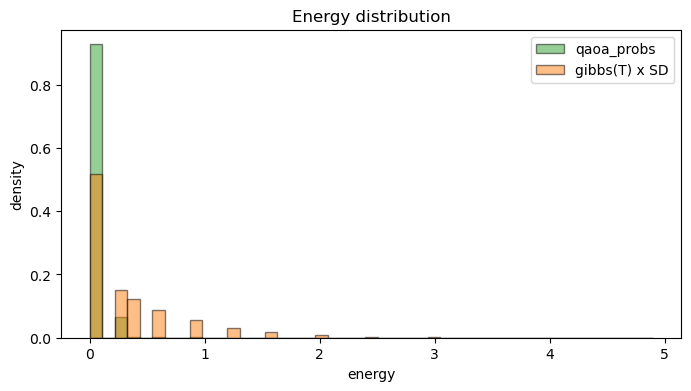

In [ ]:
# plot qaoa population and compare with custom temperature

# T = 2e5 * temp_formula
T = temp_formula

sd_eners = spectral_density(Q_norm, const_norm)
counts, bin_edges = np.histogram(sd_eners, bins=45, density=False)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]  # uniform bins
gibbs_factor = np.exp(-(bin_centers - np.min(bin_centers)) / T)
reweighted_counts = counts * gibbs_factor
reweighted_density = reweighted_counts / (np.sum(reweighted_counts) ) # divide by bin_width if you want a probability density


fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(111)

# ### plot QAOA samples
# bins_n = int((np.max(eners_qaoa_norm) - np.min(eners_qaoa_norm))/bin_width)
# ax.hist(eners_qaoa_norm, bins=bins_n, edgecolor="black", density=True, label = "qaoa_samples", alpha = .5)

### plot QAOA exact probs
n, _ = np.shape(Q_norm)
state_energies = np.array([evaluate_energy(state_inttobin(i, n), Q_norm, const_norm) for i in range(2**n)])
bins_n = int((np.max(state_energies) - np.min(state_energies))/bin_width)
ax.hist(state_energies, bins=bins_n, weights=probs_qaoa, density=False, edgecolor="black", color="C2", label="qaoa_probs", alpha=0.5)

### plot weighted spectral density
ax.bar(bin_centers, reweighted_density, width=bin_width, color = "C1", edgecolor="black", label = "gibbs(T) x SD", alpha = .5)

ax.set_title("Energy distribution")
ax.set_xlabel("energy")
ax.set_ylabel("density")
ax.legend()
plt.show()

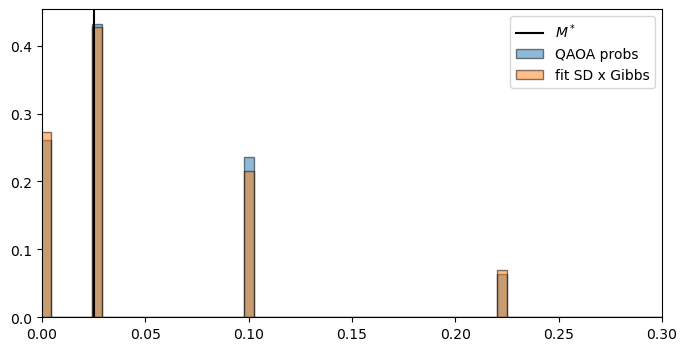

Temperatures:
from formula = 0.964	from fit = 0.114	circuit_effective temperature = 0.032


In [66]:
# compare with temperature fit

use_probs = True
sd_eners = spectral_density(Q_norm, const_norm)
temp_opt, bin_edges, model_hist, qaoa_hist, best_result = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 1000, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bin_width = bin_edges[1] - bin_edges[0]

# Plot comparison
fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(111)
if use_probs:
    ax.bar(bin_centers, qaoa_hist, width=bin_width, edgecolor="black", alpha=0.5, label="QAOA probs")
else:
    ax.bar(bin_centers, qaoa_hist, width=bin_width, edgecolor="black", alpha=0.5, label="QAOA samples")
M_norm_norm = results["M_star"] / (results["norm_guess"] * results["norm_final"])
ax.axvline(M_norm_norm, color = "k", label = r"$M^*$")
ax.bar(bin_centers, model_hist, width=bin_width, edgecolor="black", alpha=0.5, label=f"fit SD x Gibbs")
ax.set_xlim(0, .3)
ax.legend()
plt.show()

temp_circ_eff = temp_formula/ results["norm_final"]
print(f"Temperatures:\nfrom formula = {np.round(temp_formula, 3)}\tfrom fit = {np.round(temp_opt, 3)}\tcircuit_effective temperature = {np.round(temp_circ_eff, 3)}")


## Misc

### $T_{eff} (p)$

In [197]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "NPP"
vseed = 42
M_strategy = "feasibility"
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


N_idx = 0
layers_list = np.arange(1, 21)
temp_effective = np.ndarray((len(layers_list)))

for i, layers in enumerate(layers_list):
    results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)
    eners, temp_formula, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["temperature_norm"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
    eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

    # Renormalize energies
    norm_tot = norm_guess*norm_final
    Q_norm = Q/norm_tot
    const_norm = const/norm_tot
    eners_qaoa_norm = eners_qaoa/norm_tot

    # Get T_eff
    use_probs = True
    sd_eners = spectral_density(Q_norm, const_norm)
    temp_opt, bin_edges, model_hist, qaoa_hist, best_result = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 45, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
    temp_effective[i] = temp_opt

With an instance with 9 bits, 1 layers and (thus) est. temp. (UNnorm) 26473482.021 [norm -> 9.643], the appropriate M is 43577072.620391846
...breaking at iteration 89 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.382 	 eff_ex = 0.373		Scaling error (norm_final) = 15.907928637070126
One instance with size n_bits = 9 of NPP took 3.1253s

With an instance with 9 bits, 2 layers and (thus) est. temp. (UNnorm) 13236741.011 [norm -> 4.821], the appropriate M is 21919431.09035492
...breaking at iteration 169 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.881 	 eff_ex = 0.874		Scaling error (norm_final) = 8.019221622326546
One instance with size n_bits = 9 of NPP took 9.8145s

With an instance with 9 bits, 3 layers and (thus) est. temp. (UNnorm) 8824494.007 [norm -> 3.214], the appropriate M is 14697588.011622429
...breaking at iteration 169 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.93 	 eff_ex = 0.935		Scaling error (norm_final) = 5.388694929216337
One instance with size n_bits = 

/tmp/ipykernel_796533/2526408792.py:65: RuntimeWarning: overflow encountered in divide
  return float(np.sum(qaoa_prob[mask] * np.log(qaoa_prob[mask] / p[mask])))


With an instance with 9 bits, 5 layers and (thus) est. temp. (UNnorm) 5294696.404 [norm -> 1.929], the appropriate M is 8920951.068401337
...breaking at iteration 109 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.997 	 eff_ex = 0.998		Scaling error (norm_final) = 3.284578637864208
One instance with size n_bits = 9 of NPP took 13.6532s

With an instance with 9 bits, 6 layers and (thus) est. temp. (UNnorm) 4412247.004 [norm -> 1.607], the appropriate M is 7477824.449539185
...breaking at iteration 109 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.997 	 eff_ex = 0.997		Scaling error (norm_final) = 2.758925691508436
One instance with size n_bits = 9 of NPP took 15.9516s

With an instance with 9 bits, 7 layers and (thus) est. temp. (UNnorm) 3781926.003 [norm -> 1.378], the appropriate M is 6447957.0388793945
...breaking at iteration 259 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff = 0.994 	 eff_ex = 0.996		Scaling error (norm_final) = 2.3838007151595524
One instance with size n_bits =

Drawn fit:  beta = 13.563 p/n^(3/2)


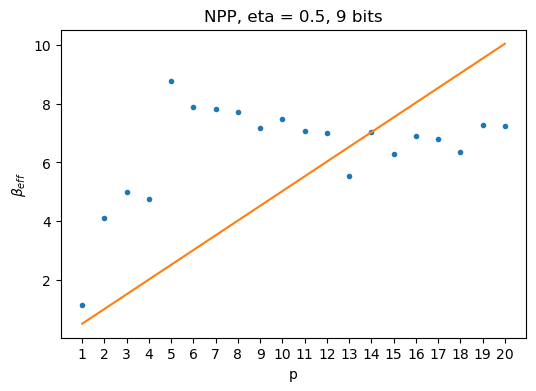

In [218]:
skip = 0

assert problem_type == "NPP"
n_bits = P*Ns[N_idx]

fun = lambda x, k : x*k / n_bits**(3/2)
coef, coef_std = sp.optimize.curve_fit(fun, layers_list[skip:], 1/temp_effective[skip:])
print(f"Drawn fit:  beta = {np.round(coef[0], 3)} p/n^(3/2)")

fig = plt.figure(figsize = (6, 4))
ax = fig.add_subplot(111)
ax.plot(layers_list, 1/temp_effective, ".")
xs = np.linspace(layers_list[skip], layers_list[-1], 100)
ax.plot(xs, fun(xs, *coef), "-", label = "fit")
ax.set_xlabel("p")
ax.set_ylabel(r"$\beta_{eff}$")
ax.set_xticks(layers_list)
ax.set_title(f"{problem_type}, eta = {eta_req}, {P*Ns[N_idx]} bits")
plt.show()

### Correlations?

In [15]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
vseed = 42
M_strategy = "feasibility"

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


N_idx_list = np.array([0, 1, 2])
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
nN, nl, ne = len(N_idx_list), len(layers_list), len(eta_req_list)
shape = (nN, nl, ne)

# pre-allocate scalar fields
log = {
    "temperature_formula":   np.zeros(shape),
    "temperature_effective": np.zeros(shape),
    "norm_guess":            np.zeros(shape),
    "norm_final":            np.zeros(shape),
    "M_star":                np.zeros(shape),
    "v_seed":                np.zeros(shape),
    "eta_eff_ex":                np.zeros(shape),
    "n_bits":                np.zeros(shape, dtype=int),
    # array fields: last axis is the variable-length dimension
    "energies_samples":      np.zeros(shape + (qaoa_samples,)),
    "probability_states":    [[[None]*ne for _ in range(nl)] for _ in range(nN)],  # ragged: kept as nested list
}

for i_N, N_idx in enumerate(N_idx_list):
    for i_l, layers in enumerate(layers_list):
        for i_e, eta_req in enumerate(eta_req_list):
            results = qaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)
            eners, (Q, const), norm_guess, norm_final, M_star, probs_qaoa = results["energies_samples"], results["QUBO"], results["norm_guess"], results["norm_final"], results["M_star"], results["probability_states"]
            eners_qaoa = combine_obj_pen(eners, qaoa_samples, M_star)

            # Renormalize energies
            norm_tot = norm_guess*norm_final
            Q_norm = Q/norm_tot
            const_norm = const/norm_tot
            eners_qaoa_norm = eners_qaoa/norm_tot

            # Get T_eff
            use_probs = True
            sd_eners = spectral_density(Q_norm, const_norm)
            temp_opt, _, _, _, _ = fit_temp_from_histograms(sd_eners, eners_qaoa_norm, bins = 45, use_probs=use_probs, probs_qaoa=probs_qaoa, Q=Q_norm, const=const_norm)
            results["temperature_effective"] = temp_opt

            # store
            idx = (i_N, i_l, i_e)
            log["temperature_formula"][idx]   = results["temperature_norm"]
            log["n_bits"][idx]                = results["n_bits"]
            log["eta_eff_ex"][idx]            = results["eta_eff_ex"]
            log["temperature_effective"][idx] = temp_opt
            log["norm_guess"][idx]            = norm_guess
            log["norm_final"][idx]            = norm_final
            log["M_star"][idx]                = M_star
            log["v_seed"][idx]                = vseed
            log["energies_samples"][idx]      = eners_qaoa_norm
            log["probability_states"][i_N][i_l][i_e] = probs_qaoa

file = open("./data_qaoa/corrs_PO.txt", "wb")
pickle.dump(log, file)
file.close()

With an instance with 6 bits, 5 layers, M* is 68.359375
...breaking at iteration 239 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.337
One instance with size n_bits = 6 of PO took 20.9485s

With an instance with 6 bits, 5 layers, M* is 281.93359375
...breaking at iteration 239 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.337
One instance with size n_bits = 6 of PO took 20.8023s

With an instance with 6 bits, 5 layers, M* is 600.9765625
...breaking at iteration 239 out of 500
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 0.336
One instance with size n_bits = 6 of PO took 20.5975s

With an instance with 6 bits, 10 layers, M* is 34.609375
...breaking at iteration 229 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.383
One instance with size n_bits = 6 of PO took 37.2941s

With an instance with 6 bits, 10 layers, M* is 140.4296875
...breaking at iteration 219 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.383
One instance with size n_bits = 6 of PO took 35.4662s

With 

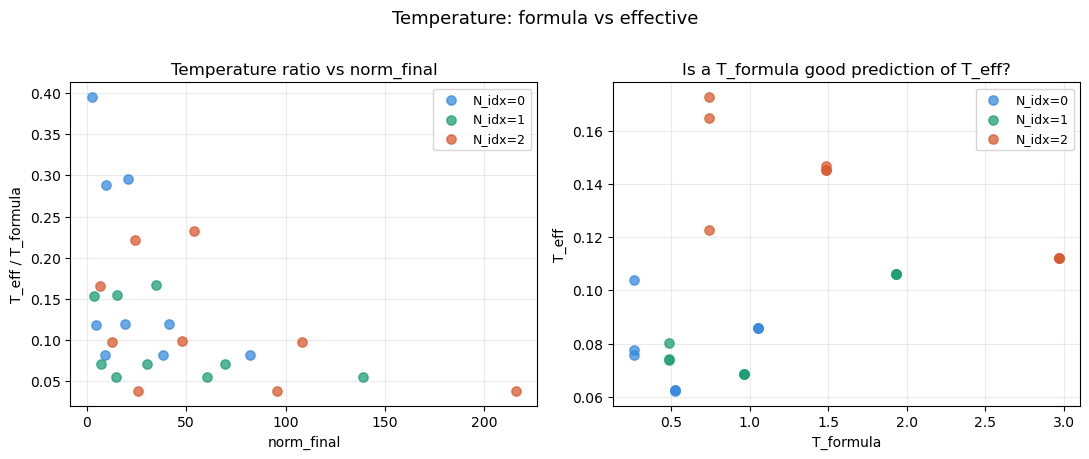

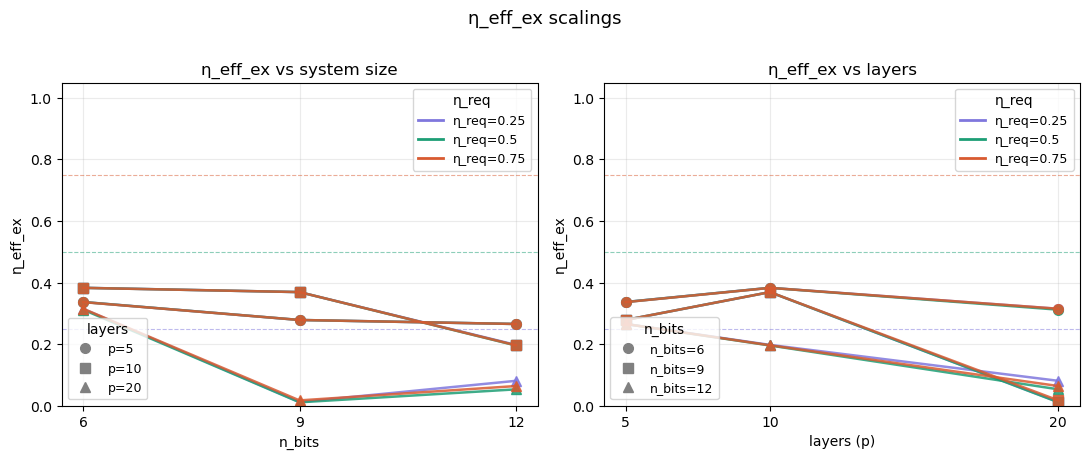

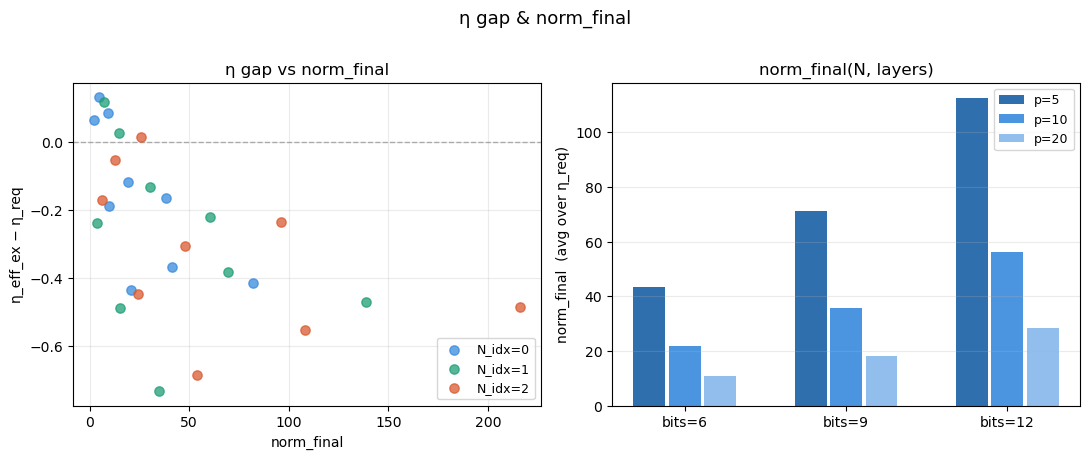

In [ ]:


# ── color palette (matches dashboard) ────────────────────────────────────────
COL_N    = ['#378ADD', '#1D9E75', '#D85A30']   # per N_idx
COL_ETA  = ['#7F77DD', '#1D9E75', '#D85A30']   # per eta_req
COL_L    = ['#185FA5', '#378ADD', '#85B7EB']    # per layers

# ── index lists (must match how log was built) ────────────────────────────────
N_idx_list   = np.array([0, 1, 2])
layers_list  = np.array([5, 10, 20])
eta_req_list = np.array([0.25, 0.50, 0.75])
nN, nl, ne   = len(N_idx_list), len(layers_list), len(eta_req_list)

# ── load your log here ────────────────────────────────────────────────────────
with open("./data_qaoa/corrs_PO.txt", "rb") as f:
    log = pickle.load(f)

temp_formula = log["temperature_formula"]   # shape (nN, nl, ne)
temp_eff     = log["temperature_effective"]
norm_final   = log["norm_final"]
eta_eff_ex   = log["eta_eff_ex"]


ratio      = temp_eff / temp_formula                          # (nN, nl, ne)
mismatch   = np.abs(temp_eff - temp_formula) / temp_formula  # (nN, nl, ne)
eta_gap    = eta_eff_ex - eta_req_list[np.newaxis, np.newaxis, :]  # (nN, nl, ne)


# Figure 1 — Temperature analysis
fig1, axes1 = plt.subplots(1, 2, figsize=(11, 4.5))
fig1.suptitle("Temperature: formula vs effective", fontsize=13, fontweight='normal', y=1.01)

# --- panel 1a: T_eff/T_formula vs norm_final ---------------------------------
ax = axes1[0]
for i, ni in enumerate(N_idx_list):
    x = norm_final[i].ravel()
    y = ratio[i].ravel()
    ax.scatter(x, y, color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
x_range = [norm_final.min()*0.97, norm_final.max()*1.03]
# ax.axhline(1, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel("norm_final")
ax.set_ylabel("T_eff / T_formula")
ax.set_title("Temperature ratio vs norm_final")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# --- panel 1b: parity plot ---------------------------------------------------
ax = axes1[1]
all_t = np.concatenate([temp_eff.ravel(), temp_formula.ravel()])
tmin, tmax = all_t.min()*0.93, all_t.max()*1.05
for i, ni in enumerate(N_idx_list):
    ax.scatter(temp_formula[i].ravel(), temp_eff[i].ravel(),
               color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
# ax.plot([tmin, tmax], [tmin, tmax], color='gray', lw=1, ls='--', alpha=0.6, label='parity')
# ax.set_xlim(tmin, tmax)
# ax.set_ylim(tmin, tmax)
ax.set_xlabel("T_formula")
ax.set_ylabel("T_eff")
ax.set_title("Is a T_formula good prediction of T_eff?")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

fig1.tight_layout()


# Figure 2 — η_eff_ex scalings
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.5))
fig2.suptitle("η_eff_ex scalings", fontsize=13, fontweight='normal', y=1.01)

# --- panel 2a: η vs n_bits, per (eta_req, layers) ---------------------------
ax = axes2[0]
n_bits_list = np.array([6, 9, 12])
markers = {5: 'o', 10: 's', 20: '^'}

for k, er in enumerate(eta_req_list):
    for j, l in enumerate(layers_list):
        ax.plot(n_bits_list, eta_eff_ex[:, j, k],
                color=COL_ETA[k], marker=markers[l],
                lw=1.8, ms=7, alpha=0.85)
    ax.axhline(er, color=COL_ETA[k], lw=0.8, ls='--', alpha=0.5)

# two-part legend: color = η_req, marker = layers
from matplotlib.lines import Line2D
color_handles  = [Line2D([0], [0], color=COL_ETA[k], lw=2, label=f"η_req={er}")
                  for k, er in enumerate(eta_req_list)]
marker_handles = [Line2D([0], [0], color='gray', marker=markers[l], ls='',
                         ms=7, label=f"p={l}") for l in layers_list]
leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=9, title="η_req")
ax.add_artist(leg1)
ax.legend(handles=marker_handles, loc='lower left', fontsize=9, title="layers")

ax.set_xticks(n_bits_list)
ax.set_ylim(0, 1.05)
ax.set_xlabel("n_bits")
ax.set_ylabel("η_eff_ex")
ax.set_title("η_eff_ex vs system size")
ax.grid(True, alpha=0.25)

# --- panel 2b: η vs layers, per (eta_req, n_bits) ---------------------------
ax = axes2[1]
n_bits_list = np.array([6, 9, 12])
markers_N = {6: 'o', 9: 's', 12: '^'}

for k, er in enumerate(eta_req_list):
    for i, nb in enumerate(n_bits_list):
        ax.plot(layers_list, eta_eff_ex[i, :, k],
                color=COL_ETA[k], marker=markers_N[nb],
                lw=1.8, ms=7, alpha=0.85)
    ax.axhline(er, color=COL_ETA[k], lw=0.8, ls='--', alpha=0.5)

# two-part legend: color = η_req, marker = n_bits
from matplotlib.lines import Line2D
color_handles  = [Line2D([0], [0], color=COL_ETA[k], lw=2, label=f"η_req={er}")
                  for k, er in enumerate(eta_req_list)]
marker_handles = [Line2D([0], [0], color='gray', marker=markers_N[nb], ls='',
                         ms=7, label=f"n_bits={nb}") for nb in n_bits_list]
leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=9, title="η_req")
ax.add_artist(leg1)
ax.legend(handles=marker_handles, loc='lower left', fontsize=9, title="n_bits")

ax.set_xticks(layers_list)
ax.set_ylim(0, 1.05)
ax.set_xlabel("layers (p)")
ax.set_ylabel("η_eff_ex")
ax.set_title("η_eff_ex vs layers")
ax.grid(True, alpha=0.25)

fig2.tight_layout()


# Figure 3 — η gap & norm_final
fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4.5))
fig3.suptitle("η gap & norm_final", fontsize=13, fontweight='normal', y=1.01)

# --- panel 3a: η gap vs norm_final scatter -----------------------------------
ax = axes3[0]
for i, ni in enumerate(N_idx_list):
    ax.scatter(norm_final[i].ravel(), eta_gap[i].ravel(),
               color=COL_N[i], alpha=0.75, s=45, label=f"N_idx={ni}", zorder=3)
ax.axhline(0, color='gray', lw=1, ls='--', alpha=0.6)
ax.set_xlabel("norm_final")
ax.set_ylabel("η_eff_ex − η_req")
ax.set_title("η gap vs norm_final")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

# --- panel 3b: norm_final grouped bar (N × layers) --------------------------
ax = axes3[1]
norm_vs_NL = norm_final.mean(axis=2)   # (nN, nl) — averaged over eta_req
x = np.arange(nN)
width = 0.22
for j, l in enumerate(layers_list):
    offset = (j - 1) * width
    ax.bar(x + offset, norm_vs_NL[:, j], width=width*0.9,
           color=COL_L[j], label=f"p={l}", alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels([f"bits={n}" for n in [6,9,12]])
ax.set_ylabel("norm_final  (avg over η_req)")
ax.set_title("norm_final(N, layers)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25, axis='y')

fig3.tight_layout()


plt.show()

## $\eta_{eff}$ for problems, layers $p$ and $\eta_r$

### run QAOA

In [ ]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([0,1]) # 1,2 for TSP   0,1,2 for NPP    0,1,2,3 for PO
layers_list = np.array([5, 10, 20]) # [5, 10, 20]
eta_req_list = np.array([.25, .5, .75])
vseed_list = np.arange(42, 1042, 100) # 42-52 (TSP_rand), 52-62 (NPP), 42-942::100 (PO)

if problem_type == "PO":
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    n_bits_list = N_city_rand[N_idx_list]**2


# one file per (N_idx, vseed, layers, eta_req) combination
for vseed in vseed_list:
    for i, N_idx in enumerate(N_idx_list):
        n_bits = int(n_bits_list[i])
        for j, layers in enumerate(layers_list):
            for k, eta_req in enumerate(eta_req_list):
                # check if file already exists
                filename = f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt"
                if os.path.exists(filename):
                    print(filename, "  already exists, skipping")
                    continue

                info_instance = vseed
                if problem_type == "PO":
                    info_instance = (directory,  vseed)

                results = qaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)

                Q, const = results["QUBO"]
                Q = np.asarray(Q, float)
                assert Q.shape == (n_bits, n_bits), \
                    f"layers={layers}, eta_req={eta_req}: QUBO is {Q.shape}, expected {(n_bits, n_bits)}"

                # normalized QUBO actually trained by the circuit (pairs with best_pars);
                # reproduces the module's two-step scaling exactly (== Q/max(|Q|))
                Q_norm     = (Q     / results["s_conv"]) / results["norm_final"]
                const_norm = (const / results["s_conv"]) / results["norm_final"]

                res = {
                    "eta_eff":   float(results["eta_eff_ex"]),   # scalar
                    "best_pars": results["circuit_params"],      # single params array
                    "M_star":    float(results["M_star"]),       # scalar
                    "Q":            Q,                           # raw (n_bits, n_bits)
                    "Q_const":      float(const),                # raw scalar
                    "Q_norm":       Q_norm,                      # normalized (== Q/max(|Q|)), trained by circuit
                    "Q_const_norm": float(const_norm),           # normalized scalar
                    "vseed":     int(vseed),
                    "eta_req":   float(eta_req),
                    "layers":    int(layers),
                    "bits":      n_bits,
                }

                file = open(filename, "wb")
                pickle.dump(res, file)
                file.close()
                print(filename, "  written")

### run maQAOA

In [ ]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([0, 1, 2]) # 1,2 for TSP   0,1,2 for NPP    0,1,2,3 for PO
layers_list = np.array([1, 2, 3]) # [5, 10, 20]
eta_req_list = np.array([.25, .5, .75])
vseed_list = np.arange(642, 1042, 100) # 42-52 (TSP_rand), 52-62 (NPP), 42-942::100 (PO)

if problem_type == "PO":
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    n_bits_list = N_city_rand[N_idx_list]**2


# one file per (N_idx, vseed, layers, eta_req) combination
for vseed in vseed_list:
    for i, N_idx in enumerate(N_idx_list):
        n_bits = int(n_bits_list[i])
        for j, layers in enumerate(layers_list):
            for k, eta_req in enumerate(eta_req_list):
                # check if file already exists
                filename = f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt"
                if os.path.exists(filename):
                    print(filename, "  already exists, skipping")
                    continue

                info_instance = vseed
                if problem_type == "PO":
                    info_instance = (directory,  vseed)

                results = maqaoa_sampling_oneshot(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500)

                Q, const = results["QUBO"]
                Q = np.asarray(Q, float)
                assert Q.shape == (n_bits, n_bits), \
                    f"layers={layers}, eta_req={eta_req}: QUBO is {Q.shape}, expected {(n_bits, n_bits)}"

                # normalized QUBO actually trained by the circuit (pairs with best_pars);
                # reproduces the module's two-step scaling exactly (== Q/max(|Q|))
                Q_norm     = (Q     / results["s_conv"]) / results["norm_final"]
                const_norm = (const / results["s_conv"]) / results["norm_final"]

                res = {
                    "eta_eff":   float(results["eta_eff_ex"]),   # scalar
                    "best_pars": results["circuit_params"],      # single params array
                    "M_star":    float(results["M_star"]),       # scalar
                    "Q":            Q,                           # raw (n_bits, n_bits)
                    "Q_const":      float(const),                # raw scalar
                    "Q_norm":       Q_norm,                      # normalized (== Q/max(|Q|)), trained by circuit
                    "Q_const_norm": float(const_norm),           # normalized scalar
                    "vseed":     int(vseed),
                    "eta_req":   float(eta_req),
                    "layers":    int(layers),
                    "bits":      n_bits,
                }

                file = open(filename, "wb")
                pickle.dump(res, file)
                file.close()
                print(filename, "  written")

...breaking at iteration 139 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 19.8651s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.25.txt   written
...breaking at iteration 139 out of 500
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 18.8879s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.5.txt   written
...breaking at iteration 139 out of 500
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 1.0
One instance with size n_bits = 9, 5 layers, of NPP took 18.2762s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_5_etareq_0.75.txt   written
...breaking at iteration 109 out of 500
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.999
One instance with size n_bits = 9, 10 layers, of NPP took 28.1585s

./data_qaoa/NPP_feasibility/test_NPP_bits_9_vseed_52_layers_10_etareq_0.25.txt   written
...breaking at iteration 79 out of 500


KeyboardInterrupt: 

### joins datas

In [65]:
## create dics

Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
problem_type = "PO"



file = open("./data_qaoa/test1_PO_maqaoa.txt", "rb")
eta = pickle.load(file)
file.close()

n_idx_max, _, _ = np.shape(eta)
if problem_type == "PO":
    N_idx_list = np.arange(n_idx_max)
    n_bits_list = w*N_stocks[N_idx_list]
elif problem_type == "NPP":
    N_idx_list = np.arange(n_idx_max)
    n_bits_list = P*Ns[N_idx_list]
elif problem_type == "TSP_rand":
    N_idx_list = np.arange(1, n_idx_max+1)
    n_bits_list = N_city_rand[N_idx_list]**2

layers_list = np.array([1,2,3])

res = {}
res["eta"] = eta
res["layers"] = layers_list
res["bits"] = n_bits_list

file = open("./data_qaoa/test1_PO_maqaoa_dic.txt", "wb")
pickle.dump(res, file)
file.close()

In [55]:
### join instances through layers

file = open("./data_qaoa/test1_TSP_rand.txt", "rb")
eta_base = pickle.load(file)
file.close()

file = open("./data_qaoa/test1_TSP_layer3.txt", "rb")
eta_ext = pickle.load(file)
file.close()

a,b,c = np.shape(eta_base)
eta = np.ndarray((a,b+1,c))

eta[:, 1:] = eta_base
eta[:, 0] = eta_ext[:,0]

file = open("./data_qaoa/test1_TSP_full.txt", "wb")
pickle.dump(eta, file)
file.close()

(2, 3, 3)
(2, 1, 3)
(2, 4, 3)


In [12]:
### join instances through N

file = open("./data_qaoa/test1_PO_layer3.txt", "rb")
eta_base = pickle.load(file)
file.close()
print(np.shape(eta_base))

file = open("./data_qaoa/test1_PO.txt", "rb")
eta_ext = pickle.load(file)
file.close()

a,b,c = np.shape(eta_base)
eta = np.ndarray((a+1,b,c))
eta[0] = eta_base
eta[1:] = eta_ext

file = open("./data_qaoa/test1_PO_full.txt", "wb")
pickle.dump(eta, file)
file.close()

(3, 1, 3)


ValueError: could not broadcast input array from shape (3,1,3) into shape (1,3)

### PO

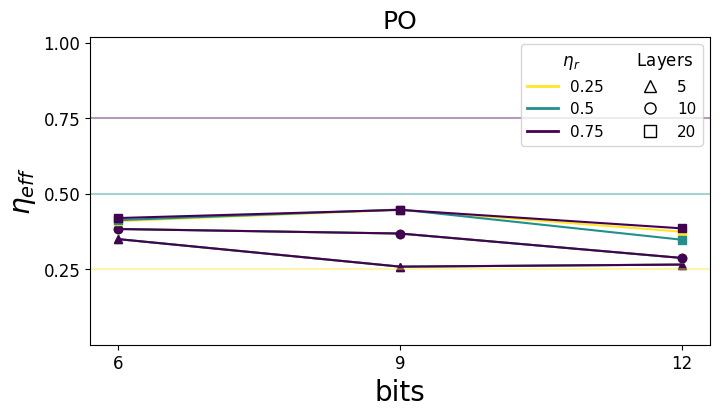

In [10]:
###### PORTFOLIO OPTIMIZATION

file = open("./data_qaoa/old_strategy/test1_PO.txt", "rb")
res = pickle.load(file)
file.close()

eta_eff_array = res["eta"]
layers_list = res["layers"]
n_bits_list = res["bits"]
problem_type = "PO"

markers = ["x", "^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    if j==0:
        continue
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        ax.plot(n_bits_list, y, "-", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")


# for j, layers in enumerate(layers_list):
#     for k, eta_req in enumerate(eta_req_list):
#         y = eta_eff_array_0[:, j, k]
#         ax.plot(n_bits_list, y, "--", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers[1:], layers_list[1:])]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}.pdf", bbox_inches='tight', format="pdf")

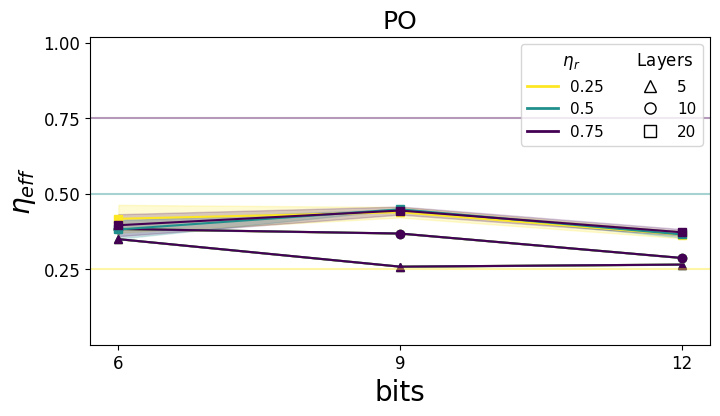

In [ ]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics

problem_type = "PO"
M_strategy = "feasibility"
vseed_list = np.arange(42, 1042, 100) # 42, 1042, 100 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([6, 9, 12])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

### NPP

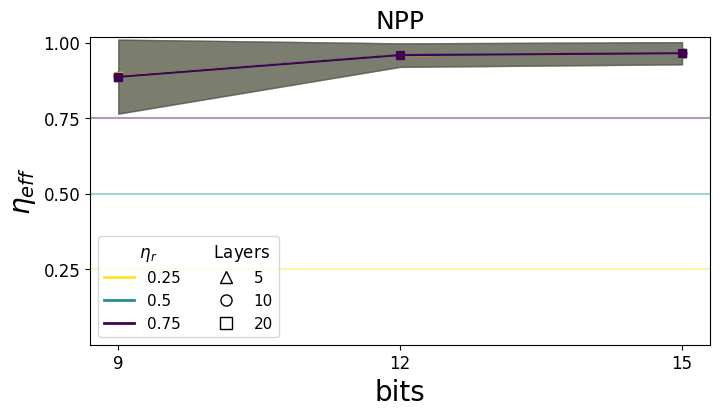

In [29]:
###### NUMBER PARTITION PROBLEM check MULTIPLE instances with statistics

problem_type = "NPP"
M_strategy = "optimality"
vseed_list = np.arange(52, 62)  # 52, 62 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([9, 12, 15])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=6, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="lower left", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
# ax.axhline(1, color = "k", alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

### TSP

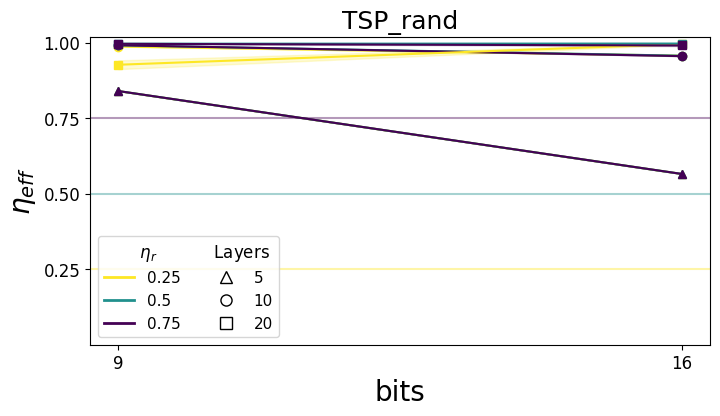

In [ ]:
###### TRAVELLING SALESMAN PROBLEM (random) check MULTIPLE instances with statistics

problem_type = "TSP_rand"
M_strategy = "feasibility"
vseed_list = np.arange(42, 52) # 42, 52 total
layers_list = np.array([5, 10, 20])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([9, 16])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=6, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)
        
# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="lower left", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")

## Compile optimized circuits (old)

### code and one circuit

In [ ]:
def build_qaoa_from_pars_pl(Q, num_qubits, p, params, n_samples=None, verbose=False):
    """
    Build (no optimisation) a PennyLane QAOA circuit from already-trained parameters,
    vanilla ansatz: |+>^n initial state + transverse-field (sum of X) mixer.

    Q          : (n,n) QUBO matrix — must be the SAME one the params were trained on.
    num_qubits : n.
    p          : QAOA depth.
    params     : flat length-2p array, order [gamma_0..gamma_{p-1}, beta_0..beta_{p-1}].
    Returns the same dict shape as the Dicke/XY version.
    """
    Q = np.asarray(Q, float)
    n = int(num_qubits)
    params = np.asarray(params, float).ravel()
    gammas, betas = params[:p], params[p:]

    # QUBO -> Ising (x_i = (1 - z_i)/2), identical convention to the Dicke version
    h = np.zeros(n); J = {}
    for i in range(n):
        h[i] += -Q[i, i] / 2
    for i in range(n):
        for j in range(i + 1, n):
            q = Q[i, j] + Q[j, i]
            J[(i, j)] = q / 4; h[i] += -q / 4; h[j] += -q / 4

    def state_prep():
        # |+>^n = uniform superposition over all 2^n computational basis states
        for i in range(n):
            qml.Hadamard(wires=i)

    def qaoa_layers(gammas=gammas, betas=betas):
        for L in range(p):
            for i in range(n):
                qml.RZ(2 * gammas[L] * h[i], wires=i)              # exp(-i gamma h_i Z_i)
            for (i, j), Jij in J.items():
                qml.IsingZZ(2 * gammas[L] * Jij, wires=[i, j])     # exp(-i gamma J_ij Z_iZ_j)
            for i in range(n):
                qml.RX(2 * betas[L], wires=i)                      # exp(-i beta X_i)

    def full_circuit():
        state_prep()
        qaoa_layers(gammas, betas)

    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev)
    def prob_node():
        full_circuit()
        return qml.probs(wires=range(n))

    probs = np.array(prob_node())
    best_idx = int(np.argmax(probs))
    best_x = [int(b) for b in format(best_idx, f"0{n}b")]
    if verbose:
        print(f"  Best x vector : {best_x}   P(best) = {probs[best_idx]:.4%}")

    ret = {"params": params, "probs": probs, "best_x": best_x,
           "circuit_fn": full_circuit, "state_prep_fn": state_prep, "qaoa_layers_fn": qaoa_layers}

    if n_samples is not None:
        dev_s = qml.device("default.qubit", wires=n, shots=n_samples)
        @qml.qnode(dev_s)
        def sample_node():
            full_circuit()
            return qml.counts(wires=range(n))
        ret["counts"] = sample_node()
    return ret

In [38]:
problem_type = "TSP_rand"
M_strategy = "feasibility"
n_bits = 9
vseed = 42
layers = 10
eta_req = 0.5

# get QUBO and QAOA pars
file = open(f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
res = pickle.load(file)
file.close()
best_pars = res["best_pars"]
Q_norm, const_norm = res["Q_norm"], res["Q_const_norm"]

# build circuit
res_circuit = build_qaoa_from_pars_pl(Q_norm, n_bits, layers, best_pars, n_samples=None)
pl_circuit = res_circuit["circuit_fn"]
probs_qaoa = res_circuit["probs"]

### check that simulating this circuit indeed returns the expected eta_eff_exact like in the training!
eta_eff_training = res["eta_eff"]
assert problem_type == "TSP_rand"
Nc = int(np.rint(np.sqrt(n_bits)))
Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
eta_eff_building = 0
if M_strategy == "feasibility":
    for i in range(2**n_bits):
        if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
            eta_eff_building += probs_qaoa[i]
print(f"Eta during training =\t{eta_eff_training}\nEta during building =\t{eta_eff_building}")

# compile circuit
tket_circ = Trans_qml_to_tket(pl_circuit , n_bits)
circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2, timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

# count credits
n_gates = (circ.n_1qb_gates(), circ.n_2qb_gates())
print(n_gates)
shots = 100
credits, n_shots = compute_credits(None, n_bits, n_gates[0], n_gates[1], shots = shots)
print(f"Cost = credits {credits:.2f} with (custom) {n_shots} number of shots")

Eta during training =	0.9914874783779335
Eta during building =	0.9914874783779666
(129, 360)
Cost = credits 81.38 with (custom) 100 number of shots


### Cost of ALL QAOA instances on Quantinuum hardware

In [ ]:
### Cost (in USD) of running ALL the optimized QAOA circuits on Quantinuum H2-2
# Sweeps every (problem_type, n_bits, layers, vseed) combination available in ./data_qaoa,
# at fixed M_strategy = "feasibility", eta_req = 0.5 and shots = 100.

import glob, re
import pandas as pd

M_strategy  = "feasibility"
eta_req     = 0.5
shots       = 100
usd_per_hqc = 1000 / 67          # 1000 USD buy 67 HQCs

layers_list = [5, 10, 20]
bits_dict   = {"PO": [6, 9, 12], "NPP": [9, 12, 15], "TSP_rand": [9, 16]}
# the 10 instances (vseed) of each family are read off the file names, so no need to hardcode them

records = []
for problem_type, bits_list in bits_dict.items():
    for n_bits in bits_list:
        for layers in layers_list:
            pattern = (f"./data_qaoa/{problem_type}_{M_strategy}/test_{problem_type}"
                       f"_bits_{n_bits}_vseed_*_layers_{layers}_etareq_{eta_req}.txt")
            files = sorted(glob.glob(pattern),
                           key=lambda f: int(re.search(r"_vseed_(\d+)_", f).group(1)))
            if len(files) == 0:
                print(f"!! no data for {problem_type} bits={n_bits} layers={layers}")
            for fname in tqdm.tqdm(files, desc=f"{problem_type} bits={n_bits} p={layers}", leave=False):
                vseed = int(re.search(r"_vseed_(\d+)_", fname).group(1))

                # get QUBO and QAOA pars
                file = open(fname, "rb")
                res = pickle.load(file)
                file.close()

                # build circuit
                res_circuit = build_qaoa_from_pars_pl(res["Q_norm"], n_bits, layers,
                                                      res["best_pars"], n_samples=None)

                # compile circuit
                tket_circ = Trans_qml_to_tket(res_circuit["circuit_fn"], n_bits)
                circ = Compile_tket_locally_wbackend(tket_circ, device_name="H2-2", optimisation_level=2,
                                                     timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

                # count credits
                n_1qb, n_2qb = circ.n_1qb_gates(), circ.n_2qb_gates()
                credits, n_shots = compute_credits(None, n_bits, n_1qb, n_2qb, shots=shots)

                records.append(dict(problem_type=problem_type, n_bits=n_bits, layers=layers, vseed=vseed,
                                    eta_eff=res["eta_eff"], n_1qb=n_1qb, n_2qb=n_2qb, shots=n_shots,
                                    HQC=credits, cost_usd=credits * usd_per_hqc))
            print(f"{problem_type:9s} bits={n_bits:2d} layers={layers:2d} -> {len(files):2d} instances done")

df_costs = pd.DataFrame.from_records(records)
df_costs.to_csv(f"./data_qaoa/qaoa_H2-2_costs_etareq_{eta_req}_shots_{shots}.csv", index=False)
print(f"\n{len(df_costs)} circuits priced.")

In [26]:
### Aggregated costs
import pandas as pd
df_costs = pd.read_csv("/tmp/claude-1000/-home-edo-Desktop-proj-hot-bigM-code/ca843476-b1f3-46e2-a3cf-262f824adde1/scratchpad/qaoa_costs.csv")

# cost of one circuit, broken down by (problem, size, depth): sum over the 10 instances + per-instance stats
print("=== USD per (problem_type, n_bits, layers), over the 10 instances ===")
print(df_costs.groupby(["problem_type", "n_bits", "layers"])["cost_usd"]
              .agg(sum_10_instances="sum", mean="mean", min="min", max="max", n="count")
              .round(2).to_string())

# cumulative (total) cost of each problem family, over ALL its combinations
print("\n=== TOTAL USD per problem type (all n_bits x layers x vseed) ===")
tot_usd = df_costs.groupby("problem_type")["cost_usd"].sum()
n_circ  = df_costs.groupby("problem_type")["cost_usd"].size()
for pt in ["PO", "NPP", "TSP_rand"]:
    print(f"  {pt:9s}: USD {tot_usd[pt]:12,.2f}   ({n_circ[pt]} circuits)")
print(f"  {'ALL':9s}: USD {df_costs['cost_usd'].sum():12,.2f}   ({len(df_costs)} circuits)")

=== USD per (problem_type, n_bits, layers), over the 10 instances ===
                            sum_10_instances     mean      min      max   n
problem_type n_bits layers                                                 
NPP          9      5                3898.51   389.85   373.73   391.64  10
                    10               6704.48   670.45   646.27   673.13  10
                    20              12334.33  1233.43  1217.31  1235.22  10
             12     5                5531.34   553.13   470.75   587.16  10
                    10              10133.73  1013.37   890.15  1051.94  10
                    20              19311.64  1931.16  1794.63  1983.28  10
             15     5                6777.91   677.79   549.55   746.87  10
                    10              13399.10  1339.91  1098.21  1511.34  10
                    20              26298.81  2629.88  2342.99  2755.52  10
PO           6      5                3319.40   331.94   331.94   331.94  10
                  

## PO analysis (optimiz. or reachability? INTERP and maQAOA)...

## Scan M

### funcs for M scan and QAOA

In [ ]:
def Ml1_from_layers(problem_type, N_idx, info_instance, layers):
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")

    min_pfeas = .5
    temp = temperature_from_layers(layers, n_bits)
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temp, min_pfeas)
    return M_L1


def Mstar_l1_from_layers(problem_type, N_idx, info_instance, layers):
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")

    eta_req = .5

    ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
    temperature_normalized = temperature_from_layers(layers, n_bits)
    norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
    temperature_unnormalized = norm_guess * temperature_normalized

    beta = 1 / temperature_unnormalized
    min_pfeas = eta_req
    peak_max = 4 # 4 for NPP and TSP, 9 for PO
    if problem_type == "PO":
        E_LB = lower_bound_obj_PO(N, w, info_instance)
        peak_max = 25
    else:
        E_LB = 0
    ### assumed Mstrategy == "feasibility":
    M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)

    temp = temperature_unnormalized
    M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temp, min_pfeas)
    return M_star, M_L1




def qaoa_etaex_withM_alpha(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False, seed = 42):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")
    

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm


    mixer_weights = None
    if problem_type == "PO":
        # mixer_weights = N * [2**k for k in range(w-1, -1, -1)]
        mixer_weights = N * [2**k for k in range(w)]
        # print(mixer_weights)
    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, mixer_weights = mixer_weights, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)


    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]

    return eta_eff_exact #, eners


# ## NOTE: if this cvell breaks, uncommment this function and add _gamma 15 rows above
# def run_qaoa_with_solution_gamma(
#     qubo_dict: dict,
#     num_qubits: int,
#     p: int = 2,
#     steps: int = 150,
#     mixer_weights=None,             # NEW: array of length num_qubits; None → standard X-mixer
#     stepsize: float = 0.05,
#     n_samples: int = 1000,
#     seed: int | None = 42,
#     verbose: bool = True,
#     draw_samples: bool = True,
#     tolerance_opt:float = 1e-4,
# ) -> dict:
#     """
#     Run QAOA on a QUBO problem and return samples from the optimised circuit.

#     The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
#     Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

#     Args:
#         qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
#                      Diagonal entries (i==i) are linear coefficients.
#                      Off-diagonal entries can be upper-triangular or full;
#                      symmetric duplicates are handled correctly.
#         num_qubits : number of binary variables (= problem size n)
#         p          : QAOA depth — number of (cost + mixer) layer pairs
#         steps      : Adam optimisation steps
#         stepsize   : Adam learning rate
#         n_samples  : shots for final sampling from the optimised circuit
#         seed       : RNG seed for reproducibility (None = random)
#         verbose    : print cost every 10 steps

#     Returns a dict with keys:
#         "best_bitstring" : str   — bitstring of highest-probability basis state
#         "best_x"         : list  — binary vector corresponding to best_bitstring
#         "params"         : array — optimised [gammas, betas] of shape (2, p)
#         "counts"         : dict  — {bitstring: count} from n_samples shots
#         "cost_history"   : list  — cost value recorded every 10 steps
#     """

#     # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
#     # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
#     #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
#     #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

#     coeffs, obs = [], []
#     for (i, j), val in qubo_dict.items():
#         if i == j:
#             # Linear term
#             coeffs.append(-val / 2)
#             obs.append(qml.PauliZ(i))
#         else:
#             # Normalise so we always process the smaller index first
#             pair = (min(i, j), max(i, j))
#             coeffs.append(val / 4)
#             obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
#             coeffs.append(-val / 4)
#             obs.append(qml.PauliZ(pair[0]))
#             coeffs.append(-val / 4)
#             obs.append(qml.PauliZ(pair[1]))

#     cost_h  = qml.simplify( qml.dot(coeffs, obs) )
#     # ── 1b. Build mixer Hamiltonian ────────────────────────────────
#     if mixer_weights is None:
#         mixer_h = qaoa.x_mixer(range(num_qubits))
#     else:
#         w = np.asarray(mixer_weights, dtype=float)
#         if w.shape != (num_qubits,):
#             raise ValueError(
#                 f"mixer_weights must have length num_qubits={num_qubits}, "
#                 f"got shape {w.shape}"
#             )
#         if np.any(w <= 0):
#             raise ValueError("mixer_weights must be strictly positive")
#         # Normalise so mean(w) = 1 → overall mixing scale comparable to standard X-mixer
#         w_norm = w / np.mean(w)
#         mixer_h = qml.simplify(
#             qml.dot(w_norm.tolist(), [qml.PauliX(i) for i in range(num_qubits)])
#         )
#         if verbose:
#             print(f"  Weighted mixer: raw w = {w.tolist()}")
#             print(f"                  normalised w = {np.round(w_norm, 4).tolist()}")

#     # ── 2. Devices ────────────────────────────────────────────────────────────
#     dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

#     # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
#     def qaoa_ansatz(gammas, betas):
#         # Equal superposition starting state  |+⟩^n
#         for wire in range(num_qubits):
#             qml.Hadamard(wires=wire)
#         # Alternating cost / mixer layers
#         for layer in range(p):
#             qaoa.cost_layer(gammas[layer], cost_h)
#             qaoa.mixer_layer(betas[layer], mixer_h)

#     # ── 4. QNodes ─────────────────────────────────────────────────────────────
#     @qml.qnode(dev_sv)
#     def cost_node(params):
#         """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.expval(cost_h)

#     @qml.qnode(dev_sv)
#     def prob_node(params):
#         """Returns the full 2^n probability vector (exact, no shots)."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.probs(wires=range(num_qubits))
    
#     @qml.set_shots(shots=n_samples)
#     @qml.qnode(dev_sv)
#     def sample_node(params):
#         """Draws shots from the optimised circuit and returns counts."""
#         qaoa_ansatz(params[0], params[1])
#         return qml.counts(wires=range(num_qubits))

#     # ── 5. Parameter initialisation — linear ramp heuristic ──────────────────
#     # Empirically good starting point: γ small→large, β large→small
#     rng    = np.random.default_rng(seed)
#     noise  = rng.uniform(-0.05, 0.05, size=(2, p))   # tiny noise to break symmetry

#     init_gammas = np.linspace(0.01, 1, p) + noise[0]
#     init_betas  = np.linspace(1, 0.01, p) + noise[1]
#     params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

#     # ── 6. Optimisation ───────────────────────────────────────────────────────
#     optimizer = qml.AdamOptimizer(stepsize=stepsize)
#     cost_history = []
#     best_params = None
#     best_cost = np.inf 

#     epsilon = tolerance_opt
#     step_check = 10
#     for step in range(steps):
#         params, cost_val = optimizer.step_and_cost(cost_node, params)
#         if cost_val < best_cost:
#             best_cost = cost_val
#             best_params = params.copy()

#         # cost_history.append(float(cost_val))
#         if (step + 1) % step_check == 0:
#             cost_history.append(float(cost_val))
#             if verbose:
#                 print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
#             if len(cost_history)>1:
#                 diff_10 = np.abs(cost_history[-2] - cost_history[-1])
#                 if diff_10 < epsilon:
#                     print(f"...breaking at iteration {step} out of {steps}")
#                     break


#     # ── 7. Draw samples (& extract best state)─────────────────────────────────
#     probs = np.array(prob_node(best_params))

#     # best_idx       = int(np.argmax(probs))
#     # best_bitstring = format(best_idx, f"0{num_qubits}b")
#     # best_x         = [int(b) for b in best_bitstring]
#     # if verbose:
#     #     print(f"\n  Best bitstring : {best_bitstring}")
#     #     print(f"  Best x vector  : {best_x}")
#     #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

#     params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
#     if draw_samples:
#         counts = sample_node(params)
#         return params, counts, probs
#     else:
#         return params, probs


### run

In [71]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
N_idx = 0
vseed = 142
M_strategy = "feasibility"
# layers = 10
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)


layers_list = np.array([5, 10, 20])

# M_list = np.array([0, 1, 10, 100]) #, 110, 130, 150, 300])
# etaex_list = np.ndarray((len(M_list), len(layers_list)))

# M_num = 5
# etaex_list = np.ndarray((len(layers_list), M_num))
# Ms_lists = np.ndarray((len(layers_list), M_num))

Ml1 = Ml1_from_layers(problem_type, N_idx, info_instance, np.max(layers_list))

# M_list = np.geomspace(1, 100*Ml1, 9)
# M_list = np.concatenate((M_list[:2], M_list[4:]))
M_list = np.array([0, 1, 10])
etaex_list = np.ndarray((len(layers_list), len(M_list)))
for j, M in tqdm.tqdm(enumerate(M_list)):
    for i, layers in enumerate(layers_list):    
        etaex_list[i, j] = qaoa_etaex_withM_alpha(problem_type, N_idx, info_instance, M, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa = False)
        # eners_qaoa[i] = combine_obj_pen(eners, qaoa_samples, M_star)

0it [00:00, ?it/s]

...breaking at iteration 209 out of 500
...breaking at iteration 299 out of 500


1it [03:10, 190.84s/it]

...breaking at iteration 419 out of 500
...breaking at iteration 339 out of 500
...breaking at iteration 299 out of 500


2it [06:13, 185.98s/it]

...breaking at iteration 369 out of 500
...breaking at iteration 329 out of 500
...breaking at iteration 279 out of 500


3it [08:58, 179.50s/it]

...breaking at iteration 329 out of 500


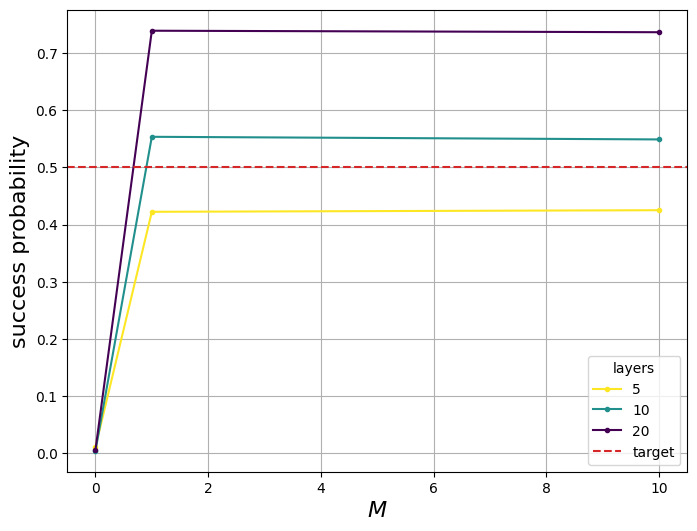

In [72]:
Mstar_list, Ml1_list = [], []
for layer in layers_list:
    a,b = Mstar_l1_from_layers(problem_type, N_idx, info_instance, layer)
    Mstar_list.append(a)
    Ml1_list.append(b)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111)

colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(layers_list)))) 
for i in range(len(layers_list)):
    # ax.plot(Ms_lists[i], etaex_list[i], ".-", label = layers_list[i], color = discr_colors.colors[i])
    ax.plot(M_list, etaex_list[i], ".-", label = layers_list[i], color = discr_colors.colors[i])
    # ax.axvline(Ml1_list[i], ls="-", color = discr_colors.colors[i])
    # ax.axvline(Mstar_list[i], ls="--", color = discr_colors.colors[i])
ax.set_xlabel(r"$M$", fontsize = 16)
# ax.set_ylabel(r"$\eta_{eff}$ exact", fontsize = 16)
ax.set_ylabel("success probability", fontsize = 16)
ax.axhline(0.5, ls ="--", color = "C3", label = "target")
# ax.set_xscale("log")
ax.grid()
ax.legend(title = "layers")
plt.show()

fig.savefig(f"qaoa_plots/{problem_type}_vseed{vseed}.pdf", format = "pdf")

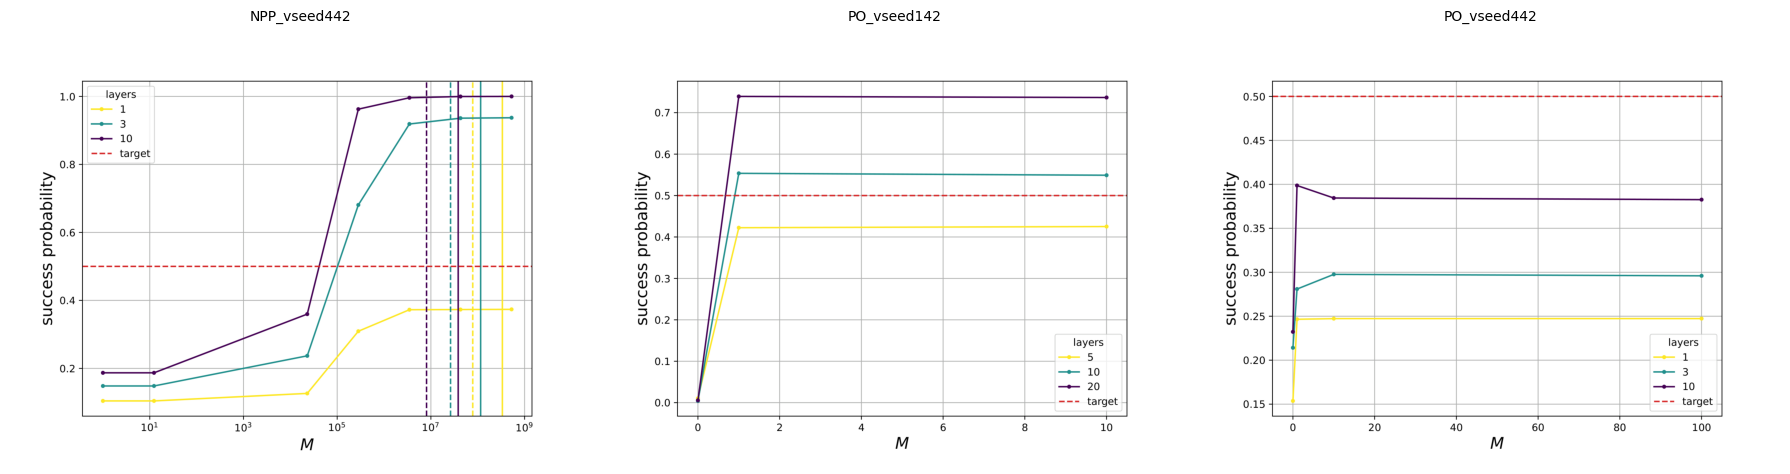

In [4]:
import matplotlib.pyplot as plt, fitz, io, glob
from PIL import Image as PILImage

def pdf_to_img(path, dpi=200):
    pix = fitz.open(path)[0].get_pixmap(dpi=dpi)
    return PILImage.open(io.BytesIO(pix.tobytes("png")))

paths = ["qaoa_plots/NPP_vseed442.pdf",
         "qaoa_plots/PO_vseed142.pdf",
         "qaoa_plots/PO_vseed442.pdf"]

fig, axes = plt.subplots(1, len(paths), figsize=(6*len(paths), 5))
for ax, p in zip(axes, paths):
    ax.imshow(pdf_to_img(p))
    ax.axis("off")
    ax.set_title(p.split("/")[-1].replace(".pdf", ""), fontsize=10)
plt.tight_layout()
plt.show()

## Run with random initialization (is the saturation only due to optimization [rand $\ge$ linear] or is it due to reachability/expressibility [rand $\approx$ linear]?)

#### code

In [ ]:
def run_qaoa_randinit(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt:float = 1e-4,
) -> dict:
    """
    Run QAOA on a QUBO problem and return samples from the optimised circuit.

    The QUBO is:  minimise  x^T Q x,   x ∈ {0,1}^n
    Encoded via the standard QUBO→Ising substitution  x_i = (1 - Z_i)/2.

    Args:
        qubo_dict  : {(i, j): Q_ij} — keys are (row, col) index pairs.
                     Diagonal entries (i==i) are linear coefficients.
                     Off-diagonal entries can be upper-triangular or full;
                     symmetric duplicates are handled correctly.
        num_qubits : number of binary variables (= problem size n)
        p          : QAOA depth — number of (cost + mixer) layer pairs
        steps      : Adam optimisation steps
        stepsize   : Adam learning rate
        n_samples  : shots for final sampling from the optimised circuit
        seed       : RNG seed for reproducibility (None = random)
        verbose    : print cost every 10 steps

    Returns a dict with keys:
        "best_bitstring" : str   — bitstring of highest-probability basis state
        "best_x"         : list  — binary vector corresponding to best_bitstring
        "params"         : array — optimised [gammas, betas] of shape (2, p)
        "counts"         : dict  — {bitstring: count} from n_samples shots
        "cost_history"   : list  — cost value recorded every 10 steps
    """

    # ── 1. Build Ising cost Hamiltonian from QUBO ─────────────────────────────
    # x_i = (1 - Z_i)/2  → (this convenction is to preserve bitstrings measurement: x=0 -> z=+1 -> \ket{0})
    #   Q_ii x_i           = -Q_ii/2 · Z_i  + Q_ii/4 · I
    #   Q_ij x_i x_j (i≠j) =  Q_ij/4 · ZiZj - Q_ij/4 · Zi - Q_ij/4 · Zj + Q_ij/4 · I

    coeffs, obs = [], []
    for (i, j), val in qubo_dict.items():
        if i == j:
            # Linear term
            coeffs.append(-val / 2)
            obs.append(qml.PauliZ(i))
        else:
            # Normalise so we always process the smaller index first
            pair = (min(i, j), max(i, j))
            coeffs.append(val / 4)
            obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[0]))
            coeffs.append(-val / 4)
            obs.append(qml.PauliZ(pair[1]))

    cost_h  = qml.simplify( qml.dot(coeffs, obs) )
    mixer_h = qaoa.x_mixer(range(num_qubits))

    # ── 2. Devices ────────────────────────────────────────────────────────────
    dev_sv     = qml.device("default.qubit", wires=num_qubits)                  # statevector

    # ── 3. QAOA circuit (shared by all QNodes) ────────────────────────────────
    def qaoa_ansatz(gammas, betas):
        # Equal superposition starting state  |+⟩^n
        for wire in range(num_qubits):
            qml.Hadamard(wires=wire)
        # Alternating cost / mixer layers
        for layer in range(p):
            qaoa.cost_layer(gammas[layer], cost_h)
            qaoa.mixer_layer(betas[layer], mixer_h)

    # ── 4. QNodes ─────────────────────────────────────────────────────────────
    @qml.qnode(dev_sv)
    def cost_node(params):
        """Returns ⟨ψ|H_cost|ψ⟩ — the objective we minimise."""
        qaoa_ansatz(params[0], params[1])
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(params):
        """Returns the full 2^n probability vector (exact, no shots)."""
        qaoa_ansatz(params[0], params[1])
        return qml.probs(wires=range(num_qubits))
    
    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(params):
        """Draws shots from the optimised circuit and returns counts."""
        qaoa_ansatz(params[0], params[1])
        return qml.counts(wires=range(num_qubits))

    # ── 5. Parameter initialisation — totally random initial pars ──────────────────
    # Empirically good starting point: γ small→large, β large→small
    rng    = np.random.default_rng(seed)
    rand  = rng.uniform(0, 1, size=(2, p))

    init_gammas = rand[0]
    init_betas  = rand[1]
    params = pl_np.array([init_gammas, init_betas], requires_grad=True) # PennyLane's numpy wrapper: requires_grad=True enables analytic gradients

    # ── 6. Optimisation ───────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_params = None
    best_cost = np.inf 

    epsilon = tolerance_opt
    step_check = 10
    for step in range(steps):
        params, cost_val = optimizer.step_and_cost(cost_node, params)
        if cost_val < best_cost:
            best_cost = cost_val
            best_params = params.copy()

        # cost_history.append(float(cost_val))
        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
                
            if len(cost_history)>1:
                diff_10 = np.abs(cost_history[-2] - cost_history[-1])
                if diff_10 < epsilon:
                    print(f"...breaking at iteration {step} out of {steps}")
                    break


    # ── 7. Draw samples (& extract best state)─────────────────────────────────
    probs = np.array(prob_node(best_params))

    # best_idx       = int(np.argmax(probs))
    # best_bitstring = format(best_idx, f"0{num_qubits}b")
    # best_x         = [int(b) for b in best_bitstring]
    # if verbose:
    #     print(f"\n  Best bitstring : {best_bitstring}")
    #     print(f"  Best x vector  : {best_x}")
    #     print(f"  P(best state)  : {probs[best_idx]:.4%}")

    params = np.array(best_params) # detach PennyLane's autograd wrapper before passing to the shot device
    if draw_samples:
        counts = sample_node(params)
        return params, counts, probs
    else:
        return params, probs
    



def qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, seed = 42, print_time = True, verbose_qaoa = False):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")
    
    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa = run_qaoa_randinit(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)

    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]
    return eta_eff_exact #, eners

#### run

In [ ]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 442
layers = 10

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e7 # 1e2 for PO and 1e7 for NPP 

n_rand_tries = 20
etaex_list = np.ndarray((n_rand_tries))
for i in tqdm.tqdm(range(n_rand_tries)):
    etaex_list[i] = qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa = False, seed = i)

print(etaex_list)

 10%|█         | 2/20 [02:48<23:41, 78.97s/it] 

...breaking at iteration 229 out of 500


 15%|█▌        | 3/20 [03:58<21:13, 74.89s/it]

...breaking at iteration 309 out of 500


 20%|██        | 4/20 [05:08<19:22, 72.69s/it]

...

...breaking at iteration 439 out of 500


 95%|█████████▌| 19/20 [23:59<01:27, 87.24s/it]

...breaking at iteration 449 out of 500


100%|██████████| 20/20 [25:31<00:00, 76.59s/it]

...breaking at iteration 419 out of 500
[0.99781013 0.9977765  0.99965954 0.99676626 0.99626866 0.99926448
 0.99948068 0.99872481 0.99838897 0.99640377 0.99860897 0.9986251
 0.99540991 0.99772674 0.99836089 0.99896104 0.99823493 0.99816701
 0.99939135 0.99924093]


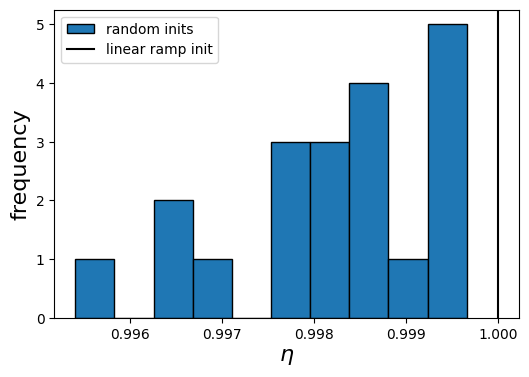

In [46]:
fig = plt.figure(figsize = (6,4))
ax = fig.add_subplot(111)
ax.hist(etaex_list, label = "random inits", density=False, edgecolor="black", color="C0")
ax.axvline(1, label = "linear ramp init", color = "k")
ax.set_xlabel(r"$\eta$", fontsize = 16)
ax.set_ylabel("frequency", fontsize = 16)
# ax.set_xscale("log")
ax.legend()
plt.show()

fig.savefig(f"qaoa_plots/randominits_{problem_type}.pdf", format = "pdf")

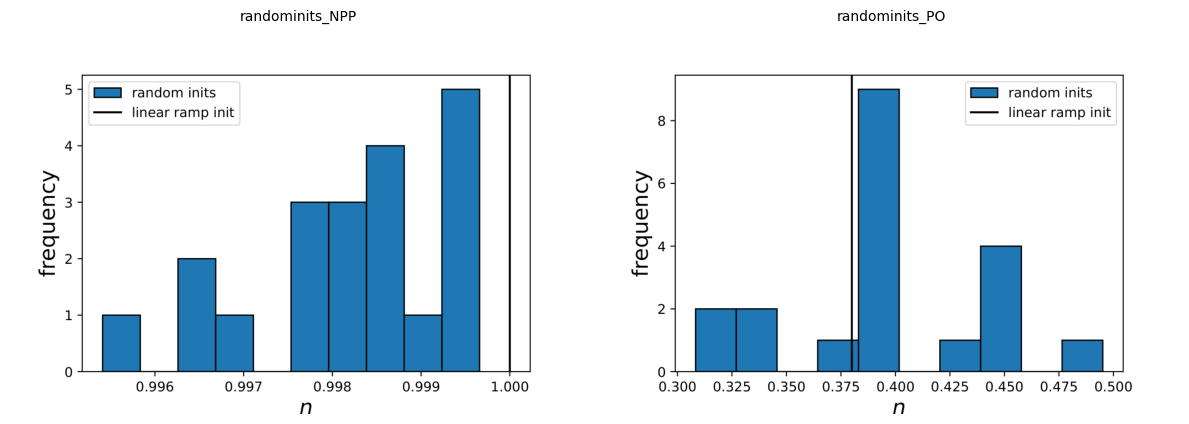

In [5]:
import matplotlib.pyplot as plt, fitz, io, glob
from PIL import Image as PILImage

def pdf_to_img(path, dpi=200):
    pix = fitz.open(path)[0].get_pixmap(dpi=dpi)
    return PILImage.open(io.BytesIO(pix.tobytes("png")))

paths = ["qaoa_plots/randominits_NPP.pdf",
         "qaoa_plots/randominits_PO.pdf"]

fig, axes = plt.subplots(1, len(paths), figsize=(6*len(paths), 5))
for ax, p in zip(axes, paths):
    ax.imshow(pdf_to_img(p))
    ax.axis("off")
    ax.set_title(p.split("/")[-1].replace(".pdf", ""), fontsize=10)
plt.tight_layout()
plt.show()

## Reachability scaling 1: success vs layers at saturation M

In [53]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 442
# layers = 10
layers_list = np.array([1,2,3,5,7,10,15,20,30])

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e2 # 1e2 for PO and 1e7 for NPP 

n_tries = 5
etaex_list = np.ndarray((len(layers_list), n_tries))
for i, layers in tqdm.tqdm(enumerate(layers_list)):
    for j in range(n_tries):
        etaex_list[i, j] = qaoa_etaex_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa = False, seed = j)

0it [00:00, ?it/s]

...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500
...breaking at iteration 69 out of 500


1it [00:08,  8.71s/it]

...breaking at iteration 69 out of 500
...breaking at iteration 239 out of 500
...breaking at iteration 189 out of 500
...breaking at iteration 239 out of 500
...breaking at iteration 259 out of 500


2it [00:52, 29.08s/it]

...

...breaking at iteration 289 out of 500
...breaking at iteration 279 out of 500
...breaking at iteration 449 out of 500
...breaking at iteration 219 out of 500
...breaking at iteration 209 out of 500


8it [24:38, 299.84s/it]

...breaking at iteration 439 out of 500
...breaking at iteration 409 out of 500
...breaking at iteration 99 out of 500
...breaking at iteration 389 out of 500
...breaking at iteration 139 out of 500


9it [33:33, 223.68s/it]

...breaking at iteration 109 out of 500


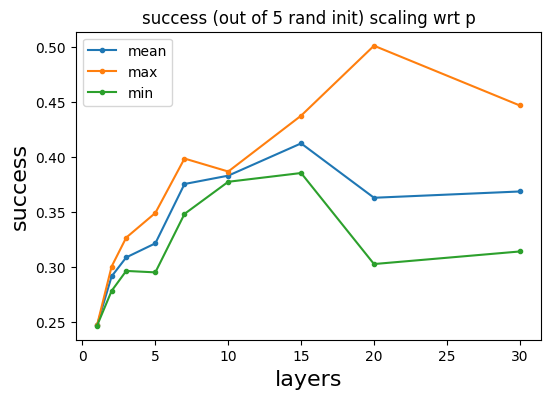

In [ ]:
fig = plt.figure(figsize = (6,4))
ax = fig.add_subplot(111)
ax.plot(layers_list, np.mean(etaex_list, axis=-1), ".-", label = "mean")
ax.plot(layers_list, np.max(etaex_list, axis=-1), ".-", label = "max")
ax.plot(layers_list, np.min(etaex_list, axis=-1), ".-", label = "min")
ax.set_xlabel("layers", fontsize = 16)
ax.set_ylabel("success", fontsize = 16)
ax.set_title("success (out of 5 rand init) scaling wrt p")
# ax.set_xscale("log")
ax.legend()
plt.show()

# fig.savefig(f"qaoa_plots/p-scaling_{problem_type}.pdf", format = "pdf")

## Transfering schedules INTERP to alleviate optimization

#### code

In [ ]:
from pennylane import qaoa


def interp_step(params_p):
    """
    Single INTERP step (Zhou et al. 2018): from depth p to depth p+1.

    Formula (1-indexed math):
        x_i^[p+1] = (i-1)/p · x_{i-1}^[p] + (p-i+1)/p · x_i^[p],   i = 1, ..., p+1
        x_0^[p] = x_{p+1}^[p] = 0

    In 0-indexed Python:
        new[:, i] = (i/p) · params_p[:, i-1] + ((p-i)/p) · params_p[:, i]

    Args:
        params_p : array of shape (2, p) — [gammas, betas]
    Returns:
        array of shape (2, p+1) — warm-start guess
    """
    params_p = np.asarray(params_p, dtype=float)
    p = params_p.shape[1]
    new = np.zeros((2, p + 1))
    for i in range(p + 1):
        if i > 0:
            new[:, i] += (i / p) * params_p[:, i - 1]
        if i < p:
            new[:, i] += ((p - i) / p) * params_p[:, i]
    return new





# def run_qaoa_with_solution(
#     qubo_dict: dict,
#     num_qubits: int,
#     p: int = 2,
#     init_params=None,            # NEW: warm-start, shape (2, p); None → linear ramp + noise
#     steps: int = 150,
#     stepsize: float = 0.05,
#     n_samples: int = 1000,
#     seed: int | None = 42,
#     verbose: bool = True,
#     draw_samples: bool = True,
#     tolerance_opt: float = 1e-4,
# ):
#     # ── 1. Ising cost Hamiltonian (unchanged) ───────────────────────────────
#     coeffs, obs = [], []
#     for (i, j), val in qubo_dict.items():
#         if i == j:
#             coeffs.append(-val / 2);  obs.append(qml.PauliZ(i))
#         else:
#             pair = (min(i, j), max(i, j))
#             coeffs.append( val / 4);  obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
#             coeffs.append(-val / 4);  obs.append(qml.PauliZ(pair[0]))
#             coeffs.append(-val / 4);  obs.append(qml.PauliZ(pair[1]))
#     cost_h  = qml.simplify(qml.dot(coeffs, obs))
#     mixer_h = qaoa.x_mixer(range(num_qubits))

#     # ── 2. Device / QNodes (unchanged) ──────────────────────────────────────
#     dev_sv = qml.device("default.qubit", wires=num_qubits)

#     def qaoa_ansatz(gammas, betas):
#         for wire in range(num_qubits):
#             qml.Hadamard(wires=wire)
#         for layer in range(p):
#             qaoa.cost_layer(gammas[layer], cost_h)
#             qaoa.mixer_layer(betas[layer], mixer_h)

#     @qml.qnode(dev_sv)
#     def cost_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.expval(cost_h)

#     @qml.qnode(dev_sv)
#     def prob_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.probs(wires=range(num_qubits))

#     @qml.set_shots(shots=n_samples)
#     @qml.qnode(dev_sv)
#     def sample_node(params):
#         qaoa_ansatz(params[0], params[1]);  return qml.counts(wires=range(num_qubits))

#     # ── 3. Parameter init (CHANGED) ─────────────────────────────────────────
#     if init_params is not None:
#         init_params = np.asarray(init_params, dtype=float)
#         if init_params.shape != (2, p):
#             raise ValueError(
#                 f"init_params shape {init_params.shape} doesn't match (2, p) = (2, {p})"
#             )
#         params = pl_np.array(init_params.copy(), requires_grad=True)
#     else:
#         rng   = np.random.default_rng(seed)
#         noise = rng.uniform(-0.05, 0.05, size=(2, p))
#         init_gammas = np.linspace(0.01, 1, p) + noise[0]
#         init_betas  = np.linspace(1, 0.01, p) + noise[1]
#         params = pl_np.array([init_gammas, init_betas], requires_grad=True)

#     # ── 4. Optimisation (unchanged) ─────────────────────────────────────────
#     optimizer = qml.AdamOptimizer(stepsize=stepsize)
#     cost_history = []
#     best_params, best_cost = None, np.inf
#     epsilon, step_check = tolerance_opt, 10

#     for step in range(steps):
#         params, cost_val = optimizer.step_and_cost(cost_node, params)
#         if cost_val < best_cost:
#             best_cost   = cost_val
#             best_params = params.copy()
#         if (step + 1) % step_check == 0:
#             cost_history.append(float(cost_val))
#             if verbose:
#                 print(f"  step {step + 1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
#             if len(cost_history) > 1 and abs(cost_history[-2] - cost_history[-1]) < epsilon:
#                 if verbose:
#                     print(f"...breaking at iteration {step} out of {steps}")
#                 break

#     # ── 5. Outputs (CHANGED: now also returns best_cost) ────────────────────
#     probs = np.array(prob_node(best_params))
#     params_final = np.array(best_params)
#     if draw_samples:
#         counts = sample_node(params_final)
#         return params_final, counts, probs, float(best_cost)
#     else:
#         return params_final, probs, float(best_cost)
    




def run_qaoa_interp(
    Q_dict,
    n_bits,
    p_max,
    p_record=None,
    n_perturbations=5,
    perturbation_scale=0.05,
    qaoa_steps=500,
    stepsize=0.05,
    seed=42,
    verbose=False,
):
    """
    INTERP scheduling (Zhou et al. 2018) from p=1 to p=p_max.

    At p=1: n_perturbations linear-ramp+noise inits.
    At p>1: INTERP-step from the best params at p-1, perturb n_perturbations times,
            optimise each, keep best for propagation.

    Returns: dict {p: {"best_params", "best_cost", "best_probs",
                       "all_params", "all_costs", "all_probs"}} for p in p_record.
    """
    if p_record is None:
        p_record = list(range(1, p_max + 1))
    p_record_set = set(p_record)

    rng = np.random.default_rng(seed)
    results = {}
    best_params_running = None

    for p in range(1, p_max + 1):
        # Build warm-start base
        warm_start = None if p == 1 else interp_step(best_params_running)  # shape (2, p)

        all_params, all_probs, all_costs = [], [], []
        for k in range(n_perturbations):
            if warm_start is None:
                # p=1: use the inner function's default linear-ramp+noise via seed
                init = None
                inner_seed = int(seed) * 10_000 + p * 100 + k
            else:
                noise = rng.uniform(-perturbation_scale, perturbation_scale, size=(2, p))
                init = warm_start + noise
                inner_seed = None  # unused when init_params is given

            params_k, probs_k, cost_k = run_qaoa_with_solution(
                Q_dict, n_bits,
                p=p,
                init_params=init,
                steps=qaoa_steps,
                stepsize=stepsize,
                seed=inner_seed if inner_seed is not None else 0,
                verbose=False,
                draw_samples=False,
            )
            all_params.append(params_k)
            all_probs.append(probs_k)
            all_costs.append(cost_k)

        # Propagate the best (by cost) to the next level
        best_idx = int(np.argmin(all_costs))
        best_params_running = all_params[best_idx]

        if verbose:
            print(f"[INTERP] p={p:>2d}  best cost={all_costs[best_idx]:+.4f}  "
                  f"spread={max(all_costs)-min(all_costs):.4f}")

        if p in p_record_set:
            results[p] = {
                "best_params": all_params[best_idx],
                "best_cost":   all_costs[best_idx],
                "best_probs":  all_probs[best_idx],
                "all_params":  all_params,
                "all_probs":   all_probs,
                "all_costs":   all_costs,
            }

    return results



def qaoa_etaex_withM_interp(
    problem_type, N_idx, info_instance, M,
    p_max=30, p_record=None, n_perturbations=5,
    qaoa_steps=500, verbose=False, seed=42,
):
    # ── 1. Build penalty Q (for feasibility check) and total Q ──────────────
    if problem_type == "NPP":
        N = Ns[N_idx];  n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q, const         = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx];  n_bits = Nc**2
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q, const         = get_QUBO_TSP(Nc, M, None, "circle")
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx];  n_bits = Nc**2
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q, const         = get_QUBO_TSP(Nc, M, info_instance, "seed")
    elif problem_type == "PO":
        N = N_stocks[N_idx];  n_bits = N * w
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, "seed", info_instance, penalization=True, objective=False)
        Q, const         = get_QUBO_PO(N, w, M, "seed", info_instance)
    else:
        raise ValueError("Unknown problem_type")

    # Normalise Q
    norm   = np.max(np.abs(Q))
    Q_norm = Q / norm
    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)}

    # ── 2. INTERP ──────────────────────────────────────────────────────────
    results = run_qaoa_interp(
        Q_dict, n_bits,
        p_max=p_max,
        p_record=p_record,
        n_perturbations=n_perturbations,
        qaoa_steps=qaoa_steps,
        seed=seed,
        verbose=verbose,
    )

    # ── 3. Feasibility (success) per p, per init ───────────────────────────
    def success_from_probs(probs):
        s = 0.0
        for i in range(2 ** n_bits):
            pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
            if np.isclose(pen_en, 0):
                s += probs[i]
        return s

    success_best, success_all = {}, {}
    for p, res in results.items():
        success_best[p] = success_from_probs(res["best_probs"])
        success_all[p]  = [success_from_probs(pr) for pr in res["all_probs"]]

    return success_best, success_all

#### run [reachability scaling 2: with interp]

In [ ]:
problem_type   = "PO"
N_idx          = 0
vseed          = 442
directory      = "PO_small"
info_instance  = (directory, vseed) if problem_type == "PO" else vseed
M              = 1e2                       # 1e2 for PO, 1e7 for NPP

p_max          = 30
p_record       = [1, 2, 3, 5, 7, 10, 15, 20, 30]
n_perturbations = 2

success_best, success_all = qaoa_etaex_withM_interp(
    problem_type, N_idx, info_instance, M,
    p_max=p_max, p_record=p_record, n_perturbations=n_perturbations,
    qaoa_steps=300, verbose=True, seed=vseed,
)

[INTERP] p= 1  best cost=-0.1854  spread=0.0000
[INTERP] p= 2  best cost=-0.2130  spread=0.0000
[INTERP] p= 3  best cost=-0.2227  spread=0.0001
[INTERP] p= 4  best cost=-0.2293  spread=0.0000
[INTERP] p= 5  best cost=-0.2360  spread=0.0000
[INTERP] p= 6  best cost=-0.2467  spread=0.0000
[INTERP] p= 7  best cost=-0.2488  spread=0.0001
[INTERP] p= 8  best cost=-0.2495  spread=0.0002
[INTERP] p= 9  best cost=-0.2499  spread=0.0003
[INTERP] p=10  best cost=-0.2536  spread=0.0008
[INTERP] p=11  best cost=-0.2557  spread=0.0000
[INTERP] p=12  best cost=-0.2549  spread=0.0011
[INTERP] p=13  best cost=-0.2585  spread=0.0021
[INTERP] p=14  best cost=-0.2596  spread=0.0054
[INTERP] p=15  best cost=-0.2609  spread=0.0006
[INTERP] p=16  best cost=-0.2608  spread=0.0034
[INTERP] p=17  best cost=-0.2606  spread=0.0004
[INTERP] p=18  best cost=-0.2619  spread=0.0008
[INTERP] p=19  best cost=-0.2615  spread=0.0001
[INTERP] p=20  best cost=-0.2624  spread=0.0001
[INTERP] p=21  best cost=-0.2623  spread

<Figure size 600x400 with 0 Axes>

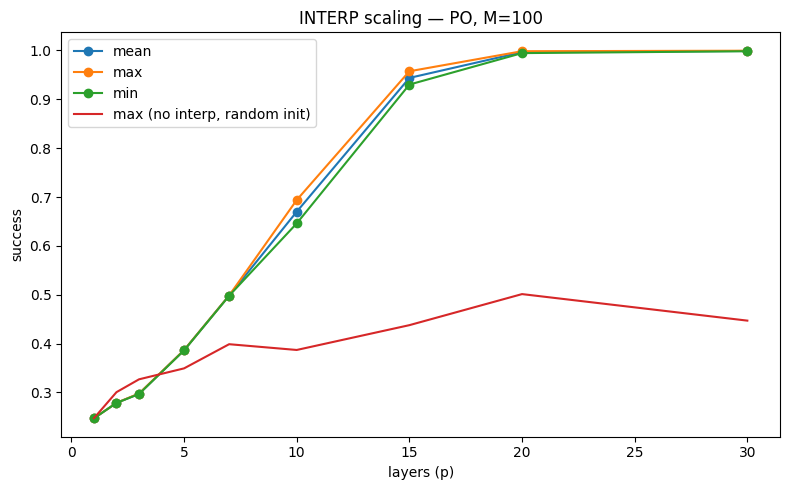

In [69]:
# ── Plot mean / min / max across the n_perturbations at each recorded p ────
import matplotlib.pyplot as plt

ps   = sorted(success_best.keys())
mean = [np.mean(success_all[p]) for p in ps]
mn   = [np.min(success_all[p])  for p in ps]
mx   = [np.max(success_all[p])  for p in ps]


fig = plt.figure(figsize = (6,4))

ax.set_xlabel("layers", fontsize = 16)
ax.set_ylabel("success", fontsize = 16)
ax.set_title("success (out of 5 rand init) scaling wrt p")
# ax.set_xscale("log")
ax.legend()


fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
ax.plot(ps, mean, "-o", label="mean")
ax.plot(ps, mx,   "-o", label="max")
ax.plot(ps, mn,   "-o", label="min")
ax.plot(ps, np.max(etaex_list, axis=-1), label = "max (no interp, random init)")
ax.set_xlabel("layers (p)")
ax.set_ylabel("success")
ax.set_title(f"INTERP scaling — {problem_type}, M={M:g}")
ax.legend()
plt.tight_layout()
plt.show()


fig.savefig(f"qaoa_plots/p-scaling_INTERP_{problem_type}.pdf", format = "pdf")

## testing thermal property of large M limit

#### code

In [ ]:
def qaoa_etaex_withM_beta(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False, seed = 42):
    """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
     Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
    t1 = timer()
    
    ### 1. Get LCBO
    if problem_type == "NPP":
        N = Ns[N_idx]
        size = (N, P)
        n_bits = N * P
        Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
        info_type = "seed"
        problem_type_Mfunc = "NPP"
    elif problem_type == "TSP_circle":
        Nc = N_city_circle[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_instance = None
        info_type = "circle"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "TSP_rand":
        Nc = N_city_rand[N_idx]
        size = (Nc)
        n_bits = Nc**2
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        problem_type_Mfunc = "TSP"
    elif problem_type == "PO":
        N = N_stocks[N_idx]
        size = (N, w)
        n_bits = N*w
        info_type = "seed"
        Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
        problem_type_Mfunc = "PO"
    else:
        raise ValueError("What problem are we solving?")


    ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
    if problem_type == "NPP":
        Q, const = get_QUBO_NPP(N, P, M, info_instance)
    elif problem_type[:3] == "TSP":
        Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
    elif problem_type == "PO":
        Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
    else:
        raise ValueError("What problem are we solving?")
    

    ## Normalizing Q
    norm = np.max(np.abs(Q))
    # norm = 1
    Q_norm, const_norm = Q/norm, const/norm

    Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
    circuit_params, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa, seed = seed)
    # circuit_params, states, probs_qaoa, _ = run_qaoa_with_solution(Q_dict, n_bits, p=layers, steps=qaoa_steps, n_samples=qaoa_samples, verbose = verbose_qaoa)


    eta_eff_exact = 0
    for i in range(2**n_bits):
        pen_en = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        if pen_en < 0:
            print("It's negative!", pen_en)
        if np.isclose( pen_en, 0 ):
            eta_eff_exact += probs_qaoa[i]

    dic_tmp = {}
    dic_tmp["probs"] = probs_qaoa
    dic_tmp["penalization"] = (Q_pen, const_pen)
    dic_tmp["objective"] = (Q_obj, const_obj)
    dic_tmp["norm"] = norm

    return eta_eff_exact, dic_tmp



def thermal_prediction(n_bits, Q, const, norm, layers, idxs_sort):
    ener = np.ndarray((2**n_bits))
    for i in range(2**n_bits):
        ener[i] = evaluate_energy(state_inttobin(i, n_bits), Q, const)
    ener /= norm

    temp = .1 * temperature_from_layers(layers, n_bits)
    prob = np.exp(-ener/temp)
    prob /= np.sum(prob)

    return prob[idxs_sort]

#### run

In [138]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
N_idx = 0
vseed = 142
M_strategy = "feasibility"
eta_req = .5

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

layers_list = np.array([1, 10, 20])
n_bits = w * N_stocks[N_idx]
M = 1e20

probs_qaoa_sort = np.ndarray((len(layers_list), 2**n_bits))
predict_pen = np.ndarray((len(layers_list), 2**n_bits))
predict_tot = np.ndarray((len(layers_list), 2**n_bits))
for k, layers in enumerate(layers_list):
    etaex, dic = qaoa_etaex_withM_beta(problem_type, N_idx, info_instance, M, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa = False)

    probs_qaoa = dic["probs"]
    (Q_pen, const_pen) = dic["penalization"]
    (Q_obj, const_obj) = dic["objective"]
    norm_used = dic["norm"]

    pens = np.ndarray((2**n_bits))
    # objs = np.ndarray((2**n_bits))
    for i in range(2**n_bits):
        pens[i] = evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen)
        # objs[i] = evaluate_energy(state_inttobin(i, n_bits), Q_obj, const_obj)
    idxs_pen = np.argsort(pens)
    pens_sorted = pens[idxs_pen]
    probs_qaoa_sort[k] = probs_qaoa[idxs_pen]
    predict_pen[k] = thermal_prediction(n_bits, Q_pen, const_pen, norm = np.max(np.abs(Q_pen)), layers = layers, idxs_sort = idxs_pen)
    predict_tot[k] = thermal_prediction(n_bits, Q_obj+M*Q_pen, const_obj+M*const_pen, norm = norm_used, layers = layers, idxs_sort = idxs_pen)

# idxs_prob = np.argsort(probs_qaoa)[::-1]
# print("State \t\t\t pen \t prob \t\t obj")
# for i in idxs_prob:
#     print(state_inttobin(i, n_bits), "\t", pens[i], "\t", np.round(probs_qaoa[i], 5), "\t", np.round(objs[i], 5))

...breaking at iteration 69 out of 500
...breaking at iteration 269 out of 500
...breaking at iteration 399 out of 500


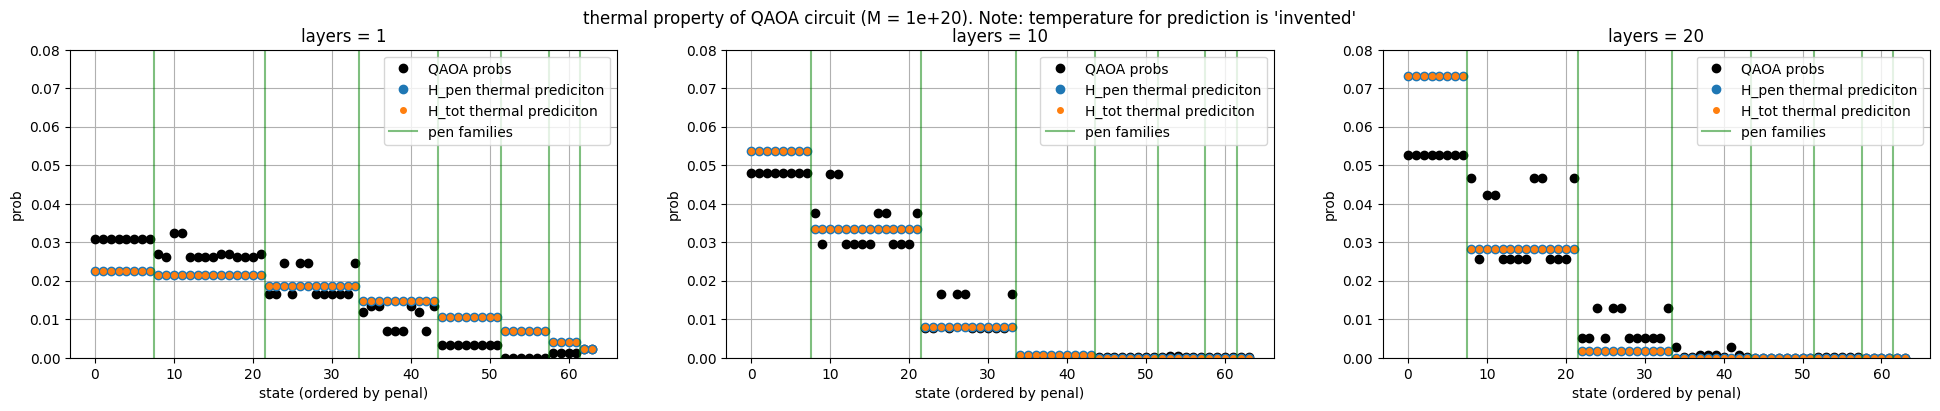

In [139]:

fig = plt.figure(figsize = (8*len(layers_list),4))
fig.suptitle(f"thermal property of QAOA circuit (M = {M}). Note: temperature for prediction is 'invented'")

for k in range(len(layers_list)):
    ax = fig.add_subplot(1, len(layers_list), k+1)
    ax.plot(np.arange(len(probs_qaoa_sort[k])), probs_qaoa_sort[k], "o", label = "QAOA probs", color = "black")
    ax.plot(np.arange(len(predict_pen[k])), predict_pen[k], "o", label = "H_pen thermal prediciton", color = "C0")
    ax.plot(np.arange(len(predict_tot[k])), predict_tot[k], "o", label = "H_tot thermal prediciton", color = "C1", markersize = 4)
    dividers = np.where( (pens_sorted[1:] - pens_sorted[:-1]) > .1 )[0]
    for d in dividers[:-1]:
        ax.axvline(d+.5, alpha = .5, color = "g")
    ax.axvline(dividers[-1]+.5, alpha = .5, color = "g", label = "pen families")
    ax.set_xlabel("state (ordered by penal)")
    ax.set_ylabel("prob")
    ax.set_title(f"layers = {layers_list[k]}")
    ax.set_ylim(0, .08)
    ax.legend(loc = "upper right")
    ax.grid()

## ma-QAOA to boost circuit expressivity (for PO)

#### code

In [ ]:
def run_ma_qaoa_with_solution(
    qubo_dict: dict,
    num_qubits: int,
    p: int = 2,
    init_params=None,
    steps: int = 150,
    stepsize: float = 0.05,
    n_samples: int = 1000,
    seed: int | None = 42,
    verbose: bool = True,
    draw_samples: bool = True,
    tolerance_opt: float = 1e-4,
    patience: int = 3,                # NEW: require N consecutive small diffs to stop
):
    """
    Multi-angle QAOA (ma-QAOA), Herrman et al. 2022.

    Each unique Pauli term in H_C gets its own γ per layer.
    Each qubit gets its own β per layer.
    """

    # ── 1. Aggregate QUBO into unique Pauli terms ───────────────────────────
    single_z, double_zz = {}, {}
    for (i, j), val in qubo_dict.items():
        if i == j:
            single_z[i] = single_z.get(i, 0.0) + (-val / 2)
        else:
            pair = (min(i, j), max(i, j))
            double_zz[pair]   = double_zz.get(pair, 0.0) + (val / 4)
            single_z[pair[0]] = single_z.get(pair[0], 0.0) + (-val / 4)
            single_z[pair[1]] = single_z.get(pair[1], 0.0) + (-val / 4)

    single_z  = {i: c for i, c in single_z.items()  if not np.isclose(c, 0.0)}
    double_zz = {pr: c for pr, c in double_zz.items() if not np.isclose(c, 0.0)}
    single_terms = sorted(single_z.items())
    double_terms = sorted(double_zz.items())
    n_single = len(single_terms)
    n_double = len(double_terms)
    n_gammas = n_single + n_double
    n_betas  = num_qubits

    if verbose:
        print(f"  ma-QAOA: n_gammas = {n_gammas} ({n_single} Z + {n_double} ZZ), "
              f"n_betas = {n_betas}, total params = {p * (n_gammas + n_betas)}")

    coeffs_all, obs_all = [], []
    for i, c in single_terms:
        coeffs_all.append(c);  obs_all.append(qml.PauliZ(i))
    for (i, j), c in double_terms:
        coeffs_all.append(c);  obs_all.append(qml.PauliZ(i) @ qml.PauliZ(j))
    cost_h = qml.simplify(qml.dot(coeffs_all, obs_all))

    # ── 2. Device & ansatz ──────────────────────────────────────────────────
    dev_sv = qml.device("default.qubit", wires=num_qubits)

    def ma_qaoa_ansatz(gammas, betas):
        for w_ in range(num_qubits):
            qml.Hadamard(wires=w_)
        for layer in range(p):
            for k, (i, coeff) in enumerate(single_terms):
                qml.RZ(2 * gammas[layer, k] * coeff, wires=i)
            for k, ((i, j), coeff) in enumerate(double_terms):
                qml.IsingZZ(2 * gammas[layer, n_single + k] * coeff, wires=[i, j])
            for i in range(num_qubits):
                qml.RX(2 * betas[layer, i], wires=i)

    # ── 3. QNodes — γ and β as SEPARATE positional args (key fix) ───────────
    @qml.qnode(dev_sv)
    def cost_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.expval(cost_h)

    @qml.qnode(dev_sv)
    def prob_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.probs(wires=range(num_qubits))

    @qml.set_shots(shots=n_samples)
    @qml.qnode(dev_sv)
    def sample_node(gammas, betas):
        ma_qaoa_ansatz(gammas, betas)
        return qml.counts(wires=range(num_qubits))

    # ── 4. Init ─────────────────────────────────────────────────────────────
    if init_params is not None:
        gammas_init, betas_init = init_params
        gammas_init = np.asarray(gammas_init, dtype=float)
        betas_init  = np.asarray(betas_init,  dtype=float)
        if gammas_init.shape != (p, n_gammas):
            raise ValueError(f"init gammas shape {gammas_init.shape} != ({p},{n_gammas})")
        if betas_init.shape != (p, n_betas):
            raise ValueError(f"init betas shape {betas_init.shape} != ({p},{n_betas})")
    else:
        rng = np.random.default_rng(seed)
        ramp_gamma = np.linspace(0.01, 1.0, p)
        ramp_beta  = np.linspace(1.0, 0.01, p)
        gammas_init = np.broadcast_to(ramp_gamma[:, None], (p, n_gammas)).copy()
        betas_init  = np.broadcast_to(ramp_beta[:, None],  (p, n_betas )).copy()
        gammas_init += rng.uniform(-0.05, 0.05, size=gammas_init.shape)
        betas_init  += rng.uniform(-0.05, 0.05, size=betas_init.shape)

    # Two SEPARATE trainable tensors (NOT a list)
    gammas = pl_np.array(gammas_init, requires_grad=True)
    betas  = pl_np.array(betas_init,  requires_grad=True)

    # ── 4b. Sanity check: confirm gradients are non-zero at init ────────────
    if verbose:
        grad_fn = qml.grad(cost_node, argnum=[0, 1])
        g_gamma, g_beta = grad_fn(gammas, betas)
        print(f"  init grad norms: ||∂C/∂γ|| = {np.linalg.norm(g_gamma):.4e}, "
              f"||∂C/∂β|| = {np.linalg.norm(g_beta):.4e}")

    # ── 5. Optimisation ─────────────────────────────────────────────────────
    optimizer = qml.AdamOptimizer(stepsize=stepsize)
    cost_history = []
    best_gammas, best_betas, best_cost = None, None, np.inf
    epsilon, step_check = tolerance_opt, 10
    small_diff_count = 0   # for patience-based early stop

    for step in range(steps):
        (gammas, betas), cost_val = optimizer.step_and_cost(cost_node, gammas, betas)
        if cost_val < best_cost:
            best_cost   = cost_val
            best_gammas = gammas.copy()
            best_betas  = betas.copy()

        if (step + 1) % step_check == 0:
            cost_history.append(float(cost_val))
            if verbose:
                print(f"  step {step+1:>4d}/{steps}  |  cost = {cost_val:+.6f}")
            if len(cost_history) > 1:
                if abs(cost_history[-2] - cost_history[-1]) < epsilon:
                    small_diff_count += 1
                else:
                    small_diff_count = 0
                if small_diff_count >= patience:
                    if verbose:
                        print(f"...converged at step {step+1} "
                              f"({patience} consecutive diffs < {epsilon})")
                    break

    # ── 6. Outputs ──────────────────────────────────────────────────────────
    probs = np.array(prob_node(best_gammas, best_betas))
    final_gammas = np.array(best_gammas)
    final_betas  = np.array(best_betas)
    if draw_samples:
        counts = sample_node(final_gammas, final_betas)
        return (final_gammas, final_betas), counts, probs, float(best_cost)
    else:
        return (final_gammas, final_betas), probs, float(best_cost)










# ### OLD maQAOA
# def maqaoa_sampling(problem_type, N_idx, info_instance, Mstrategy, eta_required, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
#     """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
#      Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
#     t1 = timer()
    
#     ### 1. Get LCBO
#     if problem_type == "NPP":
#         N = Ns[N_idx]
#         size = (N, P)
#         n_bits = N * P
#         Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
#         info_type = "seed"
#         problem_type_Mfunc = "NPP"
#     elif problem_type == "TSP_circle":
#         Nc = N_city_circle[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_instance = None
#         info_type = "circle"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "TSP_rand":
#         Nc = N_city_rand[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "PO":
#         N = N_stocks[N_idx]
#         size = (N, w)
#         n_bits = N*w
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
#         problem_type_Mfunc = "PO"
#     else:
#         raise ValueError("What problem are we solving?")
    
#     ### 2. From [LCBO, \beta] compute M^*, \eta_{guarantee} using our algorithm. Also, compute M_{\ell_1}
#     temperature_normalized = temperature_from_layers(layers, n_bits)
#     norm_guess = select_normalization(Q_pen, const_pen, Q_obj, const_obj)
#     temperature_unnormalized = norm_guess * temperature_normalized

#     beta = 1 / temperature_unnormalized
#     min_pfeas = eta_required  # eta
#     peak_max = 4 # 4 for NPP and TSP, 9 for PO
#     if problem_type == "PO":
#         E_LB = lower_bound_obj_PO(N, w, info_instance)
#         peak_max = 25
#     else:
#         E_LB = 0
#     if Mstrategy == "optimality":
#         E_f = select_Ef(problem_type, N_idx)
#         M_star, eta_guaranteed = M_method_opt(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_f, E_LB, log_stable = True)
#     elif Mstrategy == "feasibility":
#         M_star, eta_guaranteed = M_method_feas(size, problem_type_Mfunc, info_instance, info_type, beta, peak_max, min_pfeas, E_LB, log_stable = True)
#     M_L1 = L1_norm_hot(Q_obj, const_obj, n_bits, temperature_unnormalized, min_pfeas)
#     # print(f"With an instance with {n_bits} bits, {layers} layers and (thus) est. temp. (UNnorm) {np.round(temperature_unnormalized, 3)} [norm -> {np.round(temperature_normalized, 3)}], the appropriate M is {M_star}")
#     # print(f"With an instance with {n_bits} bits, {layers} layers, M* is {M_star}, M_L1 is {M_L1}")

#     ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
#     if problem_type == "NPP":
#         Q, const = get_QUBO_NPP(N, P, M_star, info_instance)
#     elif problem_type[:3] == "TSP":
#         Q, const = get_QUBO_TSP(Nc, M_star, info_instance, info_type)
#     elif problem_type == "PO":
#         Q, const = get_QUBO_PO(N, w, M_star, info_type, info_instance)
#     else:
#         raise ValueError("What problem are we solving?")

#     # Normalizing Q according to the temperature scaling we did in step 2
#     Q_norm, const_norm = Q/norm_guess, const/norm_guess

#     ## Re-normalizing Q
#     norm_final = np.max(np.abs(Q_norm))
#     Q_norm, const_norm = Q_norm/norm_final, const_norm/norm_final

#     Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
#     params_ma, probs_ma = run_ma_qaoa_with_solution(
#         Q_dict, n_bits,
#         p=layers,                 # try small p first; expressivity per layer is much higher
#         steps=qaoa_steps,
#         n_samples=qaoa_samples,
#         verbose=verbose_qaoa,
#         draw_samples=True,

#         seed=442,
#     )

#     eta_eff_exact = 0
#     for i in range(2**n_bits):
#         if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
#             eta_eff_exact += probs_ma[i]
#     print(f"Etas: req = {np.round(eta_required, 3)} \t gua = {np.round(eta_guaranteed, 3)} \t eff_ex = {np.round(eta_eff_exact, 3)}")

#     t2 = timer()
#     if print_time:
#         print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")
#     return eta_eff_exact 



### normalized temperature and pipeline



# def maqaoa_sampling_withM(problem_type, N_idx, info_instance, M, layers, qaoa_samples = 1000, qaoa_steps = 100, print_time = True, verbose_qaoa = False):
#     """ Run an instance, first using our M algo to compute M^* and then sampling with QAOA the resulting QUBO.
#      Fixed are the instance (seed and size), the Mstrategy and relative probablity required (eta) and the temperature schedule for SA, which copies DA's, scaled by a factor """
#     t1 = timer()
    
#     ### 1. Get LCBO
#     if problem_type == "NPP":
#         N = Ns[N_idx]
#         size = (N, P)
#         n_bits = N * P
#         Q_pen, const_pen = get_QUBO_NPP(N, P, 1, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_NPP(N, P, 1, info_instance, penalization=False, objective=True)
#         info_type = "seed"
#         problem_type_Mfunc = "NPP"
#     elif problem_type == "TSP_circle":
#         Nc = N_city_circle[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_instance = None
#         info_type = "circle"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "TSP_rand":
#         Nc = N_city_rand[N_idx]
#         size = (Nc)
#         n_bits = Nc**2
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
#         problem_type_Mfunc = "TSP"
#     elif problem_type == "PO":
#         N = N_stocks[N_idx]
#         size = (N, w)
#         n_bits = N*w
#         info_type = "seed"
#         Q_pen, const_pen = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=True, objective=False)
#         Q_obj, const_obj = get_QUBO_PO(N, w, 1, info_type, info_instance, penalization=False, objective=True)
#         problem_type_Mfunc = "PO"
#     else:
#         raise ValueError("What problem are we solving?")


#     ### 3. Run QAOA sampler on QUBO(M^*) and collect samples
#     if problem_type == "NPP":
#         Q, const = get_QUBO_NPP(N, P, M, info_instance)
#     elif problem_type[:3] == "TSP":
#         Q, const = get_QUBO_TSP(Nc, M, info_instance, info_type)
#     elif problem_type == "PO":
#         Q, const = get_QUBO_PO(N, w, M, info_type, info_instance)
#     else:
#         raise ValueError("What problem are we solving?")

#     ## Normalizing Q
#     norm = np.max(np.abs(Q))
#     Q_norm, const_norm = Q/norm, const/norm

#     Q_dict = {idx: val for idx, val in np.ndenumerate(Q_norm) if not np.isclose(val, 0)} # Create a dictionary with the non-zero entries of the Q matrix
#     params_ma, probs_ma = run_ma_qaoa_with_solution(
#         Q_dict, n_bits,
#         p=layers,                 # try small p first; expressivity per layer is much higher
#         steps=qaoa_steps,
#         verbose=verbose_qaoa,
#         draw_samples=False,
#         seed=442,
#     )

#     eta_eff_exact = 0
#     for i in range(2**n_bits):
#         if np.isclose( evaluate_energy(state_inttobin(i, n_bits), Q_pen, const_pen), 0 ):
#             eta_eff_exact += probs_ma[i]

#     t2 = timer()
#     if print_time:
#         print(f"One instance with size n_bits = {n_bits}, {layers} layers, of {problem_type} took {t2 - t1:.4f}s\n")

#     return eta_eff_exact

#### run one instance

In [18]:
# select parameters

Ns = np.arange(3, 9) # for NPP
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"

problem_type = "PO"
N_idx = 0
vseed = 342
layers = 2

info_instance = vseed
if problem_type == "PO":
    info_instance = (directory,  vseed)

M = 1e2
etaex = maqaoa_sampling_withM(problem_type, N_idx, info_instance, M, layers, qaoa_steps = 500, verbose_qaoa=True)
print(etaex)

  ma-QAOA: n_gammas = 21 (6 Z + 15 ZZ), n_betas = 6, total params = 54
  init grad norms: ||∂C/∂γ|| = 8.0776e-02, ||∂C/∂β|| = 3.7265e-01


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  step   10/500  |  cost = -0.160384
  step   20/500  |  cost = -0.179767
  step   30/500  |  cost = -0.194673
  step   40/500  |  cost = -0.214313
  step   50/500  |  cost = -0.229461
  step   60/500  |  cost = -0.237963
  step   70/500  |  cost = -0.241679
  step   80/500  |  cost = -0.243892
  step   90/500  |  cost = -0.245357
  step  100/500  |  cost = -0.246399
  step  110/500  |  cost = -0.247349
  step  120/500  |  cost = -0.248370
  step  130/500  |  cost = -0.249524
  step  140/500  |  cost = -0.250692
  step  150/500  |  cost = -0.251823
  step  160/500  |  cost = -0.252947
  step  170/500  |  cost = -0.254013
  step  180/500  |  cost = -0.254956
  step  190/500  |  cost = -0.255751
  step  200/500  |  cost = -0.256398
  step  210/500  |  cost = -0.256913
  step  220/500  |  cost = -0.257326
  step  230/500  |  cost = -0.257669
  step  240/500  |  cost = -0.257971
  step  250/500  |  cost = -0.258250
  step  260/500  |  cost = -0.258514
  step  270/500  |  cost = -0.258763
 

## ma-QAOA big test for PO

#### code and run

In [26]:
Ns = np.arange(3, 9) # for NPP    
P = 3 # for NPP
N_city_circle = np.arange(2, 6) # for TSP_circle
N_city_rand = np.arange(2, 6) # for TSP_rand
N_stocks = np.arange(2, 9) # for PO
w = 3 # for PO
directory = "PO_small"
qaoa_samples = 1000

problem_type = "PO"
M_strategy = "feasibility"
N_idx_list = np.array([3])
layers_list = np.array([1,2,3])
eta_req_list = np.array([.25, .5, .75])
vseed = 142

eta_eff_array = np.ndarray((len(N_idx_list), len(layers_list), len(eta_req_list)))
for i, N_idx in enumerate(N_idx_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            info_instance = vseed
            if problem_type == "PO":
                info_instance = (directory,  vseed)
            eta_eff_array[i,j,k] = maqaoa_sampling(problem_type, N_idx, info_instance, M_strategy, eta_req, layers, qaoa_samples = qaoa_samples, qaoa_steps = 500, verbose_qaoa=True)

file = open("./data_qaoa/test1_PO_maqaoa_3.txt", "wb")
pickle.dump(eta_eff_array, file)
file.close()

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 135


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 4.7188e+00, ||∂C/∂β|| = 1.2162e-01
  step   10/500  |  cost = -3.087791
  step   20/500  |  cost = -3.257474
  step   30/500  |  cost = -3.261182
  step   40/500  |  cost = -3.298820
  step   50/500  |  cost = -3.320873
  step   60/500  |  cost = -3.336480
  step   70/500  |  cost = -3.348692
  step   80/500  |  cost = -3.356286
  step   90/500  |  cost = -3.360271
  step  100/500  |  cost = -3.362780
  step  110/500  |  cost = -3.364688
  step  120/500  |  cost = -3.366167
  step  130/500  |  cost = -3.367445
  step  140/500  |  cost = -3.368603
  step  150/500  |  cost = -3.369668
  step  160/500  |  cost = -3.370646
  step  170/500  |  cost = -3.371535
  step  180/500  |  cost = -3.372335
  step  190/500  |  cost = -3.373043
  step  200/500  |  cost = -3.373664
  step  210/500  |  cost = -3.374203
  step  220/500  |  cost = -3.374670
  step  230/500  |  cost = -3.375076
  step  240/500  |  cost = -3.375434
  step  250/500  |  cost = -3.375759
  step  2

/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 4.7188e+00, ||∂C/∂β|| = 1.2162e-01
  step   10/500  |  cost = -3.087802
  step   20/500  |  cost = -3.257484
  step   30/500  |  cost = -3.261191
  step   40/500  |  cost = -3.298832
  step   50/500  |  cost = -3.320889
  step   60/500  |  cost = -3.336494
  step   70/500  |  cost = -3.348707
  step   80/500  |  cost = -3.356299
  step   90/500  |  cost = -3.360283
  step  100/500  |  cost = -3.362790
  step  110/500  |  cost = -3.364698
  step  120/500  |  cost = -3.366176
  step  130/500  |  cost = -3.367454
  step  140/500  |  cost = -3.368612
  step  150/500  |  cost = -3.369677
  step  160/500  |  cost = -3.370655
  step  170/500  |  cost = -3.371545
  step  180/500  |  cost = -3.372344
  step  190/500  |  cost = -3.373053
  step  200/500  |  cost = -3.373675
  step  210/500  |  cost = -3.374215
  step  220/500  |  cost = -3.374682
  step  230/500  |  cost = -3.375089
  step  240/500  |  cost = -3.375448
  step  250/500  |  cost = -3.375774
  step  2

...

  init grad norms: ||∂C/∂γ|| = 7.8104e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929175
  step   20/500  |  cost = -3.238987
  step   30/500  |  cost = -3.308704
  step   40/500  |  cost = -3.354141
  step   50/500  |  cost = -3.376059
  step   60/500  |  cost = -3.395484
  step   70/500  |  cost = -3.405332
  step   80/500  |  cost = -3.409004
  step   90/500  |  cost = -3.410735
  step  100/500  |  cost = -3.411584
  step  110/500  |  cost = -3.411922
  step  120/500  |  cost = -3.412152
  step  130/500  |  cost = -3.412266
  step  140/500  |  cost = -3.412331
  step  150/500  |  cost = -3.412370
  step  160/500  |  cost = -3.412396
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.25 	 gua = 0.25 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.0922s

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 405


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 7.8105e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929207
  step   20/500  |  cost = -3.239016
  step   30/500  |  cost = -3.308730
  step   40/500  |  cost = -3.354174
  step   50/500  |  cost = -3.376083
  step   60/500  |  cost = -3.395504
  step   70/500  |  cost = -3.405355
  step   80/500  |  cost = -3.409030
  step   90/500  |  cost = -3.410761
  step  100/500  |  cost = -3.411611
  step  110/500  |  cost = -3.411948
  step  120/500  |  cost = -3.412179
  step  130/500  |  cost = -3.412293
  step  140/500  |  cost = -3.412357
  step  150/500  |  cost = -3.412397
  step  160/500  |  cost = -3.412423
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.5 	 gua = 0.5 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.2425s

  ma-QAOA: n_gammas = 120 (15 Z + 105 ZZ), n_betas = 15, total params = 405


/home/edo/anaconda3/envs/qubo_env/lib/python3.11/site-packages/pennylane/_grad/grad.py:259: PennyLaneDeprecationWarning: argnum in qml.grad has been renamed to argnums to match jax and catalyst.
  warnings.warn(


  init grad norms: ||∂C/∂γ|| = 7.8105e+00, ||∂C/∂β|| = 5.0711e+00
  step   10/500  |  cost = -2.929215
  step   20/500  |  cost = -3.239023
  step   30/500  |  cost = -3.308736
  step   40/500  |  cost = -3.354181
  step   50/500  |  cost = -3.376088
  step   60/500  |  cost = -3.395508
  step   70/500  |  cost = -3.405360
  step   80/500  |  cost = -3.409036
  step   90/500  |  cost = -3.410766
  step  100/500  |  cost = -3.411617
  step  110/500  |  cost = -3.411954
  step  120/500  |  cost = -3.412185
  step  130/500  |  cost = -3.412299
  step  140/500  |  cost = -3.412363
  step  150/500  |  cost = -3.412403
  step  160/500  |  cost = -3.412429
...converged at step 160 (3 consecutive diffs < 0.0001)
Etas: req = 0.75 	 gua = 0.75 	 eff_ex = 0.999
One instance with size n_bits = 15, 3 layers, of PO took 198.0906s



#### $\eta_{eff}$ with ma-QAOA for PO

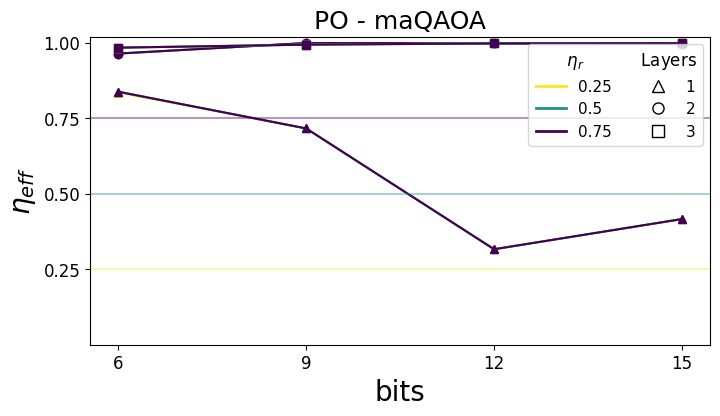

In [17]:
###### PORTFOLIO OPTIMIZATION

# file = open("./data_qaoa/test0_PO.txt", "rb")
# eta_eff_array_0 = pickle.load(file)
# file.close()

file = open("./data_qaoa/test1_PO_maqaoa.txt", "rb")
res = pickle.load(file)
file.close()

eta_eff_array = res["eta"]
layers_list = res["layers"]
n_bits_list = res["bits"]
problem_type = "PO"

markers = ["^", "o", "s"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        ax.plot(n_bits_list, y, "-", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")


# for j, layers in enumerate(layers_list):
#     for k, eta_req in enumerate(eta_req_list):
#         y = eta_eff_array_0[:, j, k]
#         ax.plot(n_bits_list, y, "--", color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, [.25, .5, .75])]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="upper right", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type + " - maQAOA", fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

fig.savefig(f"./eta_eff_plots/maQAOA_{problem_type}.pdf", bbox_inches='tight', format="pdf")

#### $\eta_{eff}$ with ma-QAOA for PO, oneshot strategy

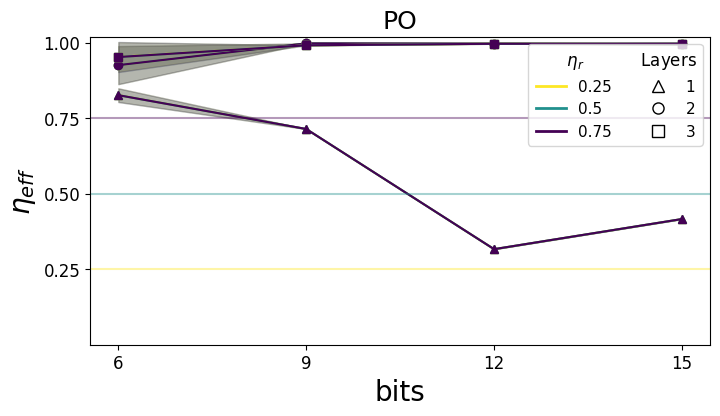

In [148]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics
### NOTE: manual E_f salection strategy

problem_type = "PO"
M_strategy = "optimality" # "optimality"
vseed_list = np.arange(42, 542, 100) # 42, 1042, 100 total
layers_list = np.array([1,2,3])
eta_req_list = np.array([.25, .5, .75])
n_bits_list = np.array([6, 9, 12, 15])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(eta_req_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[k], alpha = .2)

# ---- Concise legend ----
eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, eta_req_list)]
layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
all_handles = eta_handles + layers_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title=r"      $\eta_{r}$           Layers", title_fontsize=12, fontsize=11, loc="best", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
for i in range(len(eta_req_list)):
    ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}_maqaoa.pdf", bbox_inches='tight', format="pdf")

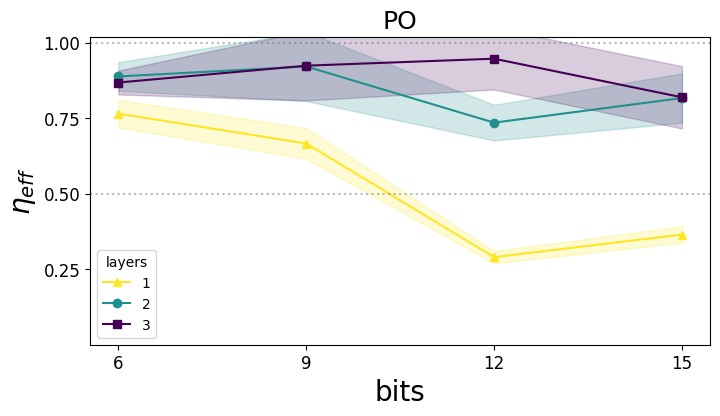

In [ ]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics
### NOTE: E_f selection from the 75% percentile


problem_type = "PO"
M_strategy = "optimality" # "optimality"
vseed_list = np.arange(42, 1042, 100) # 42, 1042, 100 total
layers_list = np.array([1,2,3])
eta_req_list = np.array([.5])
n_bits_list = np.array([6, 9, 12, 15])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):
            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa_percentile_interp/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(layers_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[j], marker = markers[j], label=f"{layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[j], alpha = .2)

# # ---- Concise legend ----
# eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, eta_req_list)]
# layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
# all_handles = layers_handles
# all_labels  = [h.get_label() for h in all_handles]
# ax.legend(handles=all_handles, labels=all_labels, title=r"Layers", title_fontsize=12, fontsize=11, loc="best", ncol=2)
# # --------
ax.legend(title = "layers")

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
# for i in range(len(eta_req_list)):
#     ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
ax.axhline(0.5, color='0.45', alpha=0.5, linestyle=':')
ax.axhline(1, color='0.45', alpha=0.5, linestyle=':')

plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}_maqaoa.pdf", bbox_inches='tight', format="pdf")

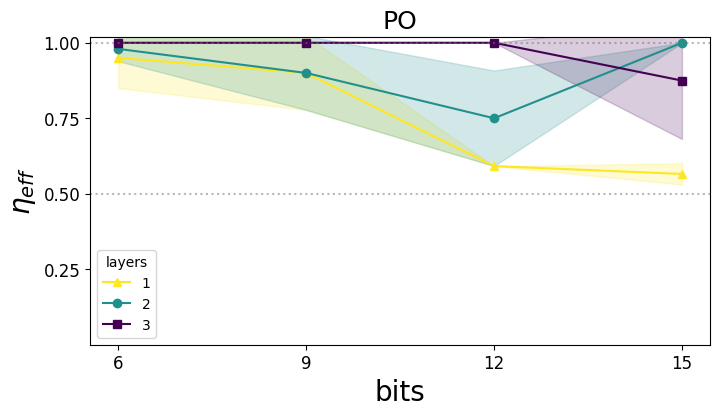

In [376]:
###### PORTFOLIO OPTIMIZATION check MULTIPLE instances with statistics
### NOTE: M_0 = 0 AND E_f selection from the 75% percentile


problem_type = "PO"
M_strategy = "optimality" # "optimality"
vseed_list = np.arange(42, 542, 100) # 42, 1042, 100 total
layers_list = np.array([1,2,3])
eta_req_list = np.array([.5])
n_bits_list = np.array([6, 9, 12,15])

eta_eff_array = np.ndarray((len(n_bits_list), len(layers_list), len(eta_req_list), len(vseed_list)))
for i_n, n_bits in enumerate(n_bits_list):
    for j, layers in enumerate(layers_list):
        for k, eta_req in enumerate(eta_req_list):

            for i_v, vseed in enumerate(vseed_list):
                file = open(f"./data_qaoa/{problem_type}_{M_strategy}_maqaoa_percentile_interp_M00/test_{problem_type}_bits_{n_bits}_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt", "rb")
                res = pickle.load(file)
                file.close()
                assert res["vseed"] == vseed
                eta_eff_array[i_n, j, k, i_v] = res["eta_eff"]

markers = ["^", "o", "s", "x"]
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(layers_list)))) 

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
# ax.set_ylim(.22, 1.03)

for j, layers in enumerate(layers_list):
    for k, eta_req in enumerate(eta_req_list):
        y = eta_eff_array[:, j, k]
        # ax.errorbar(n_bits_list, np.mean(y, axis = -1), fmt = "-", yerr=np.std(y, axis = -1), ms=2, color=discr_colors.colors[k], marker = markers[j], label=str(eta_req) + f" ; {layers}")
        ax.plot(n_bits_list, np.mean(y, axis = -1), color = discr_colors.colors[j], marker = markers[j], label=f"{layers}")
        ax.fill_between(n_bits_list, np.mean(y, axis = -1)-np.std(y, axis = -1), np.mean(y, axis = -1)+np.std(y, axis = -1), color = discr_colors.colors[j], alpha = .2)

# # ---- Concise legend ----
# eta_handles = [Line2D([0], [0], color=c, lw=2, label=f'{eta}') for c, eta in zip(discr_colors.colors, eta_req_list)]
# layers_handles = [Line2D([0], [0], color="w", markersize = 8,  markeredgecolor = "k", marker=m, lw=0, label=T) for m, T in zip(markers, layers_list)]
# all_handles = layers_handles
# all_labels  = [h.get_label() for h in all_handles]
# ax.legend(handles=all_handles, labels=all_labels, title=r"Layers", title_fontsize=12, fontsize=11, loc="best", ncol=2)
# # --------
ax.legend(title = "layers")

ax.set_ylim(0, 1.02)
ax.set_title(problem_type, fontsize = "18")
# for i in range(len(eta_req_list)):
#     ax.axhline(eta_req_list[i], color = discr_colors.colors[i], alpha = 0.4)
ax.axhline(0.5, color='0.45', alpha=0.5, linestyle=':')
ax.axhline(1, color='0.45', alpha=0.5, linestyle=':')

plt.show()

# fig.savefig(f"./eta_eff_plots/QAOA_{problem_type}_{M_strategy}_maqaoa.pdf", bbox_inches='tight', format="pdf")

## Thermal state study

The output distribution of a trained circuit, $p(x) = |\langle x|\psi(\gamma,\beta)\rangle|^2$, is compared with the Boltzmann distribution of the **full** QUBO it was trained on,
$$ E(x) \;=\; E_{obj}(x) + M^\star E_{pen}(x) \;, \qquad p_\beta(x) \;=\; e^{-\beta E(x)}/Z(\beta) \;,$$
with the energies put on the $s_{conv}$ scale ($E \to E/s_{conv}$), which is the scale the coldness refers to: the pipeline feeds the M-algorithm $\beta = 1/(s_{conv} T_{norm})$, so the value to compare against is $\beta_{pred} = 1/T_{norm} = 2.8\,p\,n^{-3/2}$ (a pessimistic bound, so a colder fit is expected and harmless).

The best-fit coldness minimises $KL(p\,\|\,p_\beta)$ which, this being an exponential family, is plain moment matching $\langle E\rangle_{p_\beta} = \langle E\rangle_p$ — no binning enters the fitted temperature. The global score is
$$ R_{therm} \;=\; 1 - \frac{KL(p\,\|\,p_{\beta_{fit}})}{KL(p\,\|\,\mathrm{uniform})} \;\in\; [0,1] \;,$$
the fraction of the structure of the output that the Boltzmann law explains ($1$ = exactly Boltzmann, $0$ = no better than flat; uniform is the $\beta=0$ member of the family, so the ratio cannot exceed $1$).

**$R_{therm}$ on its own is misleading, so it is not the headline.** The spectrum splits into a feasible band and violation bands separated by the penalty gap $M^\star/s_{conv}$, and the chain rule splits any divergence exactly along that partition:
$$ KL(p\,\|\,\mathrm{model}) \;=\; \underbrace{KL_{\rm split}}_{\text{feasible vs infeasible mass}} \;+\; P_{feas}\,KL\big(p(\cdot|{\rm feas})\,\|\,{\rm model}(\cdot|{\rm feas})\big) \;+\; P_{infeas}\,KL\big(p(\cdot|{\rm infeas})\,\|\,{\rm model}(\cdot|{\rm infeas})\big).$$
For NPP and TSP essentially **100 %** of $KL(p\|\mathrm{uniform})$ sits in the first term: the output is uniform over the feasible set to $\sim10^{-10}$ nats, so the only thing the fit has to reproduce is the single number $P_{feas}$. One parameter fitted to one number cannot fail, and $R_{therm}=1.000$ is then arithmetic rather than evidence — at $M = M^\star$ the objective is numerically invisible to the circuit (its contribution to the cost-layer phases is $\sim10^{-4}$ rad), so QAOA acts as a projector onto the feasible subspace.

The headline is therefore the **feasible-set** analysis. Conditioning on feasibility removes the penalty gap and leaves the objective landscape, the part that decides whether the circuit optimises or merely satisfies the constraints:
$$ S_{in} \;=\; KL\big(p(\cdot|{\rm feas})\,\|\,\mathrm{uniform}\big) \quad\text{(is there anything to explain?)}, \qquad R_{in\,feas} \;=\; 1 - \frac{KL\big(p(\cdot|{\rm feas})\,\|\,p_{\beta_{band}}(\cdot|{\rm feas})\big)}{S_{in}} \quad\text{(is it Boltzmann?)} $$
with $\beta_{band}$ the temperature the band itself reports. $R_{in\,feas}^{glob}$ uses the global $\beta_{fit}$ instead and is the strict single-temperature test — a true Gibbs state has one $\beta$ at every scale. When $S_{in}$ is not resolvable the run is reported as *flat on the feasible set*, and $R_{in\,feas}$ is left undefined rather than reported as a ratio of two vanishing numbers.

#### code

In [190]:
### Thermal study — pipeline: trained circuit -> p(x) -> p(E) -> best-fit Boltzmann
#
# For one stored run (problem_type, M_strategy, n_bits, vseed, layers, eta_req) we rebuild the
# trained circuit from its angles, take the EXACT final-state probabilities p(x) over the 2^n
# computational-basis states, and score them against the energies of the FULL QUBO
#        E(x) = E_obj(x) + M^* E_pen(x)           (i.e. the stored Q, which already carries M^*)
# expressed on the s_conv scale:  E -> E / s_conv.  That is the scale beta refers to: the pipeline
# feeds the M-algorithm beta = 1/(s_conv * T_norm) with T_norm = temperature_from_layers(p, n),
# so a "thermal" output should sit at  beta_pred = 1/T_norm  in these units (see
# qaoa_sampling_oneshot.py / spec_approachA_oneshot.md).  s_conv is not stored in the .txt files,
# so it is recomputed from the instance exactly as the run did (same M0, same SDP bounds).
#
# Everything is taken from qaoa_sampling_oneshot (the module that produced the data) via `qso.`,
# so these cells do not depend on which of the definition cells above have been executed -- except
# for the two circuit re-builders and data_subdir_for, which live in this notebook.

from scipy.optimize import brentq
from scipy.special import logsumexp
from scipy.stats import chi2
import textwrap
import qaoa_sampling_oneshot as qso

LOG2 = np.log(2)
_SCONV_CACHE, _BITS_CACHE = {}, {}


def _require_notebook_funcs():
    missing = [f for f in ("build_qaoa_from_pars_pl", "build_maqaoa_from_pars_pl", "data_subdir_for")
               if f not in globals()]
    if missing:
        raise NameError(f"run the cells defining {missing} first "
                        "(Funcs > Pytket circuits build and save / Compile optimized circuits)")


def thermal_instance_qubos(problem_type, n_bits, vseed):
    """Rebuild the (M=1) objective and penalty QUBOs of one instance, plus what the M-algorithm
    needs. Deterministic given (problem_type, n_bits, vseed) -- same construction as the run."""
    if problem_type == "NPP":
        N = n_bits // qso.P
        N_idx = int(np.flatnonzero(qso.Ns == N)[0])
        size, info_instance, info_type, pt_M = (N, qso.P), vseed, "seed", "NPP"
        Q_pen, c_pen = qso.get_QUBO_NPP(N, qso.P, 1, info_instance, penalization=True, objective=False)
        Q_obj, c_obj = qso.get_QUBO_NPP(N, qso.P, 1, info_instance, penalization=False, objective=True)
        E_LB, peak_max = 0.0, 4
    elif problem_type.startswith("TSP"):
        Nc = int(round(np.sqrt(n_bits)))
        N_idx = int(np.flatnonzero(qso.N_city_rand == Nc)[0])
        size, info_instance, info_type, pt_M = Nc, vseed, "seed", "TSP"
        Q_pen, c_pen = qso.get_QUBO_TSP(Nc, 1, None, None, penalization=True, objective=False)
        Q_obj, c_obj = qso.get_QUBO_TSP(Nc, 1, info_instance, info_type, penalization=False, objective=True)
        E_LB, peak_max = 0.0, 4
    elif problem_type == "PO":
        N = n_bits // qso.w
        N_idx = int(np.flatnonzero(qso.N_stocks == N)[0])
        size, info_instance, info_type, pt_M = (N, qso.w), ("PO_small", vseed), "seed", "PO"
        Q_pen, c_pen = qso.get_QUBO_PO(N, qso.w, 1, info_type, info_instance, penalization=True, objective=False)
        Q_obj, c_obj = qso.get_QUBO_PO(N, qso.w, 1, info_type, info_instance, penalization=False, objective=True)
        E_LB, peak_max = qso.lower_bound_obj_PO(N, qso.w, info_instance), 25
    else:
        raise ValueError(f"problem_type {problem_type!r} not understood")
    return dict(N_idx=N_idx, size=size, info_instance=info_instance, info_type=info_type, pt_M=pt_M,
                Q_obj=Q_obj, c_obj=c_obj, Q_pen=Q_pen, c_pen=c_pen, E_LB=E_LB, peak_max=peak_max)


def thermal_s_conv(problem_type, n_bits, vseed, layers, eta_req, inst=None, use_sdp_pen=True):
    """The span proxy the run used, recomputed (2-3 MOSEK SDPs, ~0.1 s; memoised).
    It depends on layers/eta_req through the reference weight M0 = M_L1(T_norm, eta_req)."""
    key = (problem_type, n_bits, vseed, layers, eta_req, use_sdp_pen)
    if key not in _SCONV_CACHE:
        inst = inst if inst is not None else thermal_instance_qubos(problem_type, n_bits, vseed)
        T_norm = qso.temperature_from_layers(layers, n_bits)
        M0 = qso.L1_norm_hot(inst["Q_obj"], inst["c_obj"], n_bits, T_norm, eta_req)
        _SCONV_CACHE[key] = qso.span_proxy(inst["Q_obj"], inst["c_obj"], inst["Q_pen"], inst["c_pen"],
                                           M0, inst["pt_M"], inst["E_LB"], use_sdp_pen)[0]
    return _SCONV_CACHE[key]


def _bit_matrix(n):
    """(2^n, n) array of all basis states, row i = state_inttobin(i, n) (big-endian, as everywhere)."""
    if n not in _BITS_CACHE:
        if n > 22:
            raise ValueError(f"n_bits = {n}: full enumeration of 2^n states is out of reach")
        _BITS_CACHE[n] = ((np.arange(2 ** n)[:, None] >> np.arange(n - 1, -1, -1)) & 1).astype(float)
    return _BITS_CACHE[n]


def all_energies(Q, const):
    """Energy of EVERY basis state: vectorised evaluate_energy(state_inttobin(i, n), Q, const)."""
    Q = np.asarray(Q, float)
    X = _bit_matrix(Q.shape[0])
    return np.einsum("ij,ij->i", X @ Q, X) + float(const)


def load_thermal_run(problem_type, M_strategy, n_bits, vseed, layers, eta_req=0.5,
                     dir_data="./data_qaoa", subdir=None, check=True, verbose=False):
    """Rebuild one trained circuit and return its exact output distribution together with the
    energies of every basis state on the s_conv scale.

    Returns a dict with
        p       : (2^n,)  exact QAOA/ma-QAOA probabilities, p[i] <-> state_inttobin(i, n)
        E       : (2^n,)  full-QUBO energies / s_conv          <- the axis beta lives on
        E_obj, E_pen : (2^n,) objective and (M=1) penalty energies, for the feasibility checks
        s_conv, norm_final, res (the stored file), diag (self-consistency checks)

    check=True re-derives eta_eff from the rebuilt probabilities and compares it with the stored
    value: that single number validates the circuit rebuild, the bit ordering and the energies.
    """
    _require_notebook_funcs()
    subdir = subdir or data_subdir_for(problem_type, M_strategy)
    fn = (f"{dir_data}/{subdir}/test_{problem_type}_bits_{n_bits}"
          f"_vseed_{vseed}_layers_{layers}_etareq_{eta_req}.txt")
    with open(fn, "rb") as f:
        res = pickle.load(f)
    assert (res["bits"], res["layers"], res["vseed"]) == (n_bits, layers, vseed), \
        f"{fn}: contents do not match the request"

    inst = thermal_instance_qubos(problem_type, n_bits, vseed)
    s_conv = thermal_s_conv(problem_type, n_bits, vseed, layers, eta_req, inst)
    Q, const, M_star = np.asarray(res["Q"], float), float(res["Q_const"]), float(res["M_star"])

    # PO was trained with ma-QAOA, NPP/TSP with the vanilla ansatz (cf. data_subdir_for)
    build = build_maqaoa_from_pars_pl if problem_type == "PO" else build_qaoa_from_pars_pl
    probs = np.asarray(build(res["Q_norm"], n_bits, layers, res["best_pars"])["probs"], float)

    E_obj, E_pen = all_energies(inst["Q_obj"], inst["c_obj"]), all_energies(inst["Q_pen"], inst["c_pen"])
    E_full = all_energies(Q, const)

    diag = {}
    if check:
        scale = max(np.max(np.abs(Q)), 1e-300)
        diag["d_Q_MQ"] = float(np.max(np.abs(Q - (inst["Q_obj"] + M_star * inst["Q_pen"]))) / scale)
        diag["d_Qnorm"] = float(np.max(np.abs(np.asarray(res["Q_norm"], float) - Q / scale)))
        feasible = np.isclose(E_pen, 0.0)
        if M_strategy == "feasibility":
            eta_rebuilt = float(probs[feasible].sum())
        else:  # optimality: feasible AND below the E_f the run used
            E_f = float(res["E_f"]) if "E_f" in res else float(qso.select_Ef(problem_type, inst["N_idx"]))
            diag["E_f"] = E_f
            eta_rebuilt = float(probs[feasible & (E_obj <= E_f)].sum())
        diag["eta_rebuilt"], diag["eta_stored"] = eta_rebuilt, float(res["eta_eff"])
        diag["d_eta"] = abs(eta_rebuilt - float(res["eta_eff"]))
        if verbose:
            print(f"  rebuild checks: |Q-(Qo+M*Qp)|={diag['d_Q_MQ']:.1e}  |Qnorm-Q/max|Q||="
                  f"{diag['d_Qnorm']:.1e}  eta {eta_rebuilt:.4f} vs stored {diag['eta_stored']:.4f}"
                  f"  (d={diag['d_eta']:.1e})")
        if diag["d_eta"] > 1e-6:
            warnings.warn(f"{fn}: rebuilt eta_eff {eta_rebuilt:.6f} != stored {diag['eta_stored']:.6f}")

    return dict(p=probs, E=E_full / s_conv, E_obj=E_obj, E_pen=E_pen, E_full=E_full,
                s_conv=s_conv, norm_final=float(np.max(np.abs(Q)) / s_conv), res=res, inst=inst,
                diag=diag, problem_type=problem_type, M_strategy=M_strategy, subdir=subdir,
                n_bits=n_bits, vseed=vseed, layers=layers, eta_req=eta_req, file=fn)


######### Boltzmann fit


def gibbs_logp(E, beta):
    """log of the Gibbs distribution over the 2^n states at coldness beta (stable)."""
    lw = -beta * np.asarray(E, float)
    return lw - logsumexp(lw)


def kl_div(p, logq):
    """KL(p || q) in nats, q given by its log; contributions with p = 0 are dropped."""
    m = np.asarray(p) > 0
    return float(np.sum(p[m] * (np.log(p[m]) - np.asarray(logq)[m])))


def fit_beta_gibbs(E, p, beta_max=1e12):
    """Best-fit coldness: the beta minimising KL(p || Gibbs(beta)).

    For an exponential family that is exactly the MLE, i.e. moment matching -- the unique beta
    with <E>_Gibbs(beta) = <E>_p (d<E>/dbeta = -Var(E) < 0, so the root is unique). No binning,
    no histogram, no arbitrary choice of bins enters the fitted temperature.
    """
    E = np.asarray(E, float)
    E_bar = float(np.dot(p, E))
    f = lambda b: float(np.exp(gibbs_logp(E, b)) @ E) - E_bar
    if f(0.0) <= 0:          # already hotter than infinite temperature: nothing to fit
        return 0.0
    hi = 1.0
    while f(hi) > 0:
        hi *= 4.0
        if hi > beta_max:    # p sits on the ground state: beta -> infinity
            return beta_max
    return float(brentq(f, 0.0, hi, xtol=1e-14, rtol=1e-15))


def energy_levels(E, p, rtol=1e-9):
    """Collapse the 2^n states onto distinct energy LEVELS (exact degeneracies, no binning).
    Returns (E_lvl, p_lvl, g_lvl) sorted by energy, with g the degeneracy of each level."""
    order = np.argsort(E, kind="stable")
    Es, ps = np.asarray(E)[order], np.asarray(p)[order]
    starts = np.concatenate([[0], np.flatnonzero(np.diff(Es) > rtol * np.maximum(1.0, np.abs(Es[:-1]))) + 1])
    return Es[starts], np.add.reduceat(ps, starts), np.diff(np.append(starts, len(Es))).astype(float)

In [191]:
### Thermal study — is the output Boltzmann? metrics, hypothesis tests and diagnostic plot
#
# Everything is built on the Kullback-Leibler divergence of the exact QAOA output from a model
# distribution, in nats:
#
#   D_therm = KL(p || Gibbs(beta_fit))   how far the output is from the BEST Boltzmann
#   D_pred  = KL(p || Gibbs(beta_pred))  ... from the Boltzmann the pipeline ASSUMES (beta = 1/T_norm)
#   D_unif  = KL(p || uniform)           ... from the null model "no energy dependence at all"
#
# Uniform is the beta = 0 member of the same one-parameter family, so D_therm <= D_unif always, and
# R_therm = 1 - D_therm/D_unif in [0,1] is the fraction of the structure of the output that the
# Boltzmann law explains.
#
# R_therm ALONE IS MISLEADING, which is why it is not the headline. The energy landscape splits into
# a feasible band and violation bands separated by the penalty gap M^*/s_conv, and the chain rule
# splits any divergence exactly along that partition:
#
#   KL(p || model) = [split: feasible vs infeasible mass]
#                  + P_feas   * KL( p(.|feasible)   || model(.|feasible)   )
#                  + P_infeas * KL( p(.|infeasible) || model(.|infeasible) )
#
# For NPP and TSP essentially 100% of D_unif sits in the first term: the output is UNIFORM over the
# feasible set (to ~1e-10 nats), so the only thing a Boltzmann fit has to reproduce is the single
# number P_feas. One parameter fitted to one number cannot fail, and R_therm = 1.000 is then
# arithmetic rather than evidence -- the objective is simply invisible to the circuit at M = M^*.
#
# The headline is therefore the FEASIBLE-SET analysis: how much structure the output has inside the
# feasible set (S_in_feas), and how much of THAT a Boltzmann law explains,
#
#   R_in_feas = 1 - KL( p(.|feas) || Gibbs_feas(beta_band) ) / S_in_feas ,
#
# with beta_band the temperature the feasible band itself reports. R_in_feas_glob uses the global
# beta_fit instead, which is the strict single-temperature test (a true Gibbs state has one beta at
# every scale). When S_in_feas is negligible there is nothing to test and the run is reported as
# flat on the feasible set, not as thermal.
#
# The divergences are exact (statevector, no sampling). To turn them into calibrated p-values we
# ask what n_shots measurements would conclude: G^2 = 2 n_shots KL is the expected log-likelihood
# ratio, chi^2-distributed under the null, on energy cells merged to >= 5 expected counts.

_VERDICT_R_HI, _VERDICT_R_LO, _VERDICT_P_GOF, _VERDICT_REL_SE = 0.9, 0.5, 0.01, 0.3

# font sizes of every thermal-study figure -- raise/lower globally here
_FS = dict(suptitle=15, title=13, label=13, tick=11, legend=10)


def _merge_energy_cells(p_l, models, n_shots, require=(0,), min_count=5):
    """Merge consecutive energy levels until p and every model in `require` has >= min_count
    expected counts, so that G^2 can be read against a chi^2. Returns (cells_p, [cells_model...])."""
    cp, cm = [], [[] for _ in models]
    ap, am = 0.0, [0.0] * len(models)
    for i in range(len(p_l)):
        ap += p_l[i]
        for k in range(len(models)):
            am[k] += models[k][i]
        if n_shots * ap >= min_count and all(n_shots * am[k] >= min_count for k in require):
            cp.append(ap)
            for k in range(len(models)):
                cm[k].append(am[k])
            ap, am = 0.0, [0.0] * len(models)
    if cp:
        cp[-1] += ap
        for k in range(len(models)):
            cm[k][-1] += am[k]
    else:                                   # everything in one cell: nothing to test
        cp, cm = [1.0], [[1.0] for _ in models]
    return np.asarray(cp), [np.asarray(c) for c in cm]


def _chain_rule_split(p, mask, logmod):
    """KL(p || model) = split + P_in * KL_in + P_out * KL_out, along the mask partition."""
    out = []
    masses, conds = [], []
    for sub in (mask, ~mask):
        ps = p[sub]
        mass = float(ps.sum())
        if mass > 0:
            lq = logmod[sub]
            lq = lq - np.logaddexp.reduce(lq)
            conds.append(kl_div(ps / mass, lq))
        else:
            conds.append(0.0)
        masses.append(mass)
        out.append(float(np.exp(np.logaddexp.reduce(logmod[sub]))))
    q_in = out[0]
    split = 0.0
    for mass, qm in zip(masses, (q_in, 1 - q_in)):
        if mass > 0 and qm > 0:
            split += mass * np.log(mass / qm)
    return split, masses[0] * conds[0], masses[1] * conds[1], conds[0], conds[1]


def thermal_metrics(run, n_shots=1000, rtol=1e-9):
    """Full thermal-hypothesis report for one run of load_thermal_run. Returns (metrics, aux)."""
    E, p, n_bits = run["E"], run["p"], run["n_bits"]
    beta_pred = 1.0 / qso.temperature_from_layers(run["layers"], n_bits)
    beta = fit_beta_gibbs(E, p)
    logq = gibbs_logp(E, beta)
    logu = np.full(E.shape, -n_bits * LOG2)
    q = np.exp(logq)

    D_therm = kl_div(p, logq)
    D_pred = kl_div(p, gibbs_logp(E, beta_pred))
    D_unif = kl_div(p, logu)

    # energy-level resolution: exact degeneracies g, no binning
    E_l, p_l, g_l = energy_levels(E, p, rtol)
    lq_l = -beta * E_l + np.log(g_l); lq_l -= np.logaddexp.reduce(lq_l)
    lu_l = np.log(g_l) - n_bits * LOG2
    D_shape, D_unif_E = kl_div(p_l, lq_l), kl_div(p_l, lu_l)

    var_q = float(q @ E ** 2 - (q @ E) ** 2)          # Fisher information of beta, per shot
    var_p = float(p @ E ** 2 - (p @ E) ** 2)
    se_beta = 1.0 / np.sqrt(n_shots * var_q) if var_q > 0 else np.inf
    H = -np.sum(p[p > 0] * np.log(p[p > 0]))

    m = dict(problem_type=run["problem_type"], M_strategy=run["M_strategy"], n_bits=n_bits,
             layers=run["layers"], vseed=run["vseed"], eta_req=run["eta_req"],
             eta_eff=float(run["res"]["eta_eff"]), d_eta=run["diag"].get("d_eta", np.nan),
             M_star=float(run["res"]["M_star"]), s_conv=run["s_conv"], norm_final=run["norm_final"],
             gap_pen=float(run["res"]["M_star"]) / run["s_conv"],
             beta_pred=beta_pred, beta_fit=beta, beta_ratio=beta / beta_pred if beta_pred else np.nan,
             se_beta=se_beta, rel_se=se_beta / beta if beta > 0 else np.inf,
             z_beta=(beta - beta_pred) / se_beta if np.isfinite(se_beta) and se_beta > 0 else np.nan,
             D_therm=D_therm, D_pred=D_pred, D_unif=D_unif,
             R_therm=1 - D_therm / D_unif if D_unif > 0 else np.nan,
             R_pred=1 - D_pred / D_unif if D_unif > 0 else np.nan,
             D_shape=D_shape, D_shell=D_therm - D_shape,
             R_shape=1 - D_shape / D_unif_E if D_unif_E > 0 else np.nan,
             n_levels=len(E_l), entropy_bits=H / LOG2, n_eff_states=float(np.exp(H)),
             p_max=float(p.max()), E_min=float(E.min()), E_mean=float(p @ E), E_sd=float(np.sqrt(var_p)),
             contrast=float(beta * np.sqrt(var_p)), n_shots=n_shots)

    # ---- chi^2-calibrated tests over the whole spectrum
    q_l, u_l = np.exp(lq_l), np.exp(lu_l)
    cp, (cq, cu) = _merge_energy_cells(p_l, [q_l, u_l], n_shots)
    kl_cells_t, kl_cells_u = kl_div(cp, np.log(cq)), kl_div(cp, np.log(cu))
    G_t, G_u = 2 * n_shots * kl_cells_t, 2 * n_shots * kl_cells_u
    m["n_cells"] = len(cp)
    m["G2_therm"] = G_t                                        # goodness of fit of the Boltzmann law
    m["p_therm"] = float(chi2.sf(G_t, max(len(cp) - 2, 1)))    # small p -> output is NOT Boltzmann
    m["dG2_unif"] = G_u - G_t                                  # nested LR test: Boltzmann vs uniform
    m["p_vs_unif"] = float(chi2.sf(max(G_u - G_t, 0.0), 1))    # small p -> thermal beats uniform
    # shots needed before the deviation from Boltzmann becomes detectable at 95%
    m["n_shots_detect"] = (chi2.isf(0.05, max(len(cp) - 2, 1)) / (2 * kl_cells_t)
                           if kl_cells_t > 0 else np.inf)

    # ---- where does that evidence live: the mere feasible/infeasible split, or real structure?
    feasible = np.isclose(run["E_pen"], 0.0)
    for tag, logmod in (("unif", logu), ("therm", logq)):
        s, wf, wi, kf, ki = _chain_rule_split(p, feasible, logmod)
        m[f"D_split_{tag}"], m[f"D_feas_{tag}"], m[f"D_infeas_{tag}"] = s, wf, wi
    m["frac_split"] = m["D_split_unif"] / D_unif if D_unif > 0 else np.nan

    m.update(_feasible_set_analysis(run, feasible, beta, n_shots, rtol))
    m["beta_identified"] = bool(m["rel_se"] <= _VERDICT_REL_SE)
    m["verdict"] = thermal_verdict(m)
    m["verdict_base"] = m["verdict"].split(" [")[0]
    aux = dict(beta=beta, q=q, E_l=E_l, p_l=p_l, g_l=g_l, q_l=q_l, u_l=u_l, n_shots=n_shots,
               feasible=feasible)
    return m, aux


def _feasible_set_analysis(run, feasible, beta_global, n_shots, rtol):
    """The headline: inside the feasible set, is there any structure at all, and is it Boltzmann?

    Everything here is conditional on feasibility, so the penalty gap -- which dominates every
    global divergence -- drops out and what is left is the objective landscape, the part that
    decides whether the circuit is optimising or merely satisfying the constraints."""
    E, p = run["E"], run["p"]
    n_feas, P_feas = int(feasible.sum()), float(p[feasible].sum())
    out = dict(n_feasible=n_feas, p_feasible=P_feas)
    nan_keys = ["S_in_feas", "beta_band", "se_beta_band", "band_ratio", "D_in_feas",
                "D_in_feas_glob", "R_in_feas", "R_in_feas_glob", "p_flat_feas", "p_therm_feas",
                "n_cells_feas", "n_shots_detect_flat"]
    if n_feas < 2 or P_feas <= 0:
        out.update({k: np.nan for k in nan_keys})
        out["feas_structured"] = False
        return out

    Ef, pf = E[feasible], p[feasible] / P_feas
    S_in = kl_div(pf, np.full(n_feas, -np.log(n_feas)))     # distance from uniform-over-feasible
    beta_band = fit_beta_gibbs(Ef, pf)                      # temperature the band itself reports
    D_band = kl_div(pf, gibbs_logp(Ef, beta_band))
    D_glob = kl_div(pf, gibbs_logp(Ef, beta_global))
    qb = np.exp(gibbs_logp(Ef, beta_band))
    var_b = float(qb @ Ef ** 2 - (qb @ Ef) ** 2)
    # only the shots that land in the band constrain beta_band
    se_band = 1.0 / np.sqrt(n_shots * P_feas * var_b) if var_b > 0 else np.inf

    out.update(S_in_feas=S_in, beta_band=beta_band, se_beta_band=se_band,
               band_ratio=beta_band / beta_global if beta_global > 0 else np.nan,
               D_in_feas=D_band, D_in_feas_glob=D_glob,
               R_in_feas=1 - D_band / S_in if S_in > 0 else np.nan,
               R_in_feas_glob=1 - D_glob / S_in if S_in > 0 else np.nan)
    # R_in_feas is a ratio of two vanishing numbers when the band is flat: report it only when
    # there is structure to explain, otherwise the headline would read '1.000' off pure round-off

    # two-stage test inside the band: (1) is it distinguishable from flat? (2) if so, is it Gibbs?
    E_lf, p_lf, g_lf = energy_levels(Ef, pf, rtol)
    lq_f = -beta_band * E_lf + np.log(g_lf); lq_f -= np.logaddexp.reduce(lq_f)
    lu_f = np.log(g_lf) - np.log(n_feas)
    shots_in = n_shots * P_feas                              # effective sample size in the band
    cp, (cq, cu) = _merge_energy_cells(p_lf, [np.exp(lq_f), np.exp(lu_f)], shots_in, require=(0, 1))
    kl_flat, kl_gibbs = kl_div(cp, np.log(cu)), kl_div(cp, np.log(cq))
    df = max(len(cp) - 1, 1)
    out["n_cells_feas"] = len(cp)
    out["p_flat_feas"] = float(chi2.sf(2 * shots_in * kl_flat, df))        # small -> structured
    out["p_therm_feas"] = float(chi2.sf(2 * shots_in * kl_gibbs, max(df - 1, 1)))  # large -> Gibbs ok
    out["n_shots_detect_flat"] = (chi2.isf(0.05, df) / (2 * kl_flat * max(P_feas, 1e-300))
                                  if kl_flat > 0 else np.inf)
    out["feas_structured"] = bool(out["p_flat_feas"] < 0.05)
    if not out["feas_structured"]:
        out["R_in_feas"] = out["R_in_feas_glob"] = np.nan
    return out


def thermal_verdict(m):
    """Headline verdict, read off the FEASIBLE set: the global fit is dominated by the penalty gap
    and says little, so what is reported is whether the objective landscape itself is Boltzmann."""
    if not np.isfinite(m.get("S_in_feas", np.nan)):
        return "no feasible states to analyse"
    if not m["feas_structured"]:
        base = "flat on the feasible set (objective invisible to the circuit)"
    elif m["R_in_feas"] >= _VERDICT_R_HI:
        base = ("thermal on the feasible set" if m["p_therm_feas"] > _VERDICT_P_GOF
                else "near-thermal on the feasible set")
    elif m["R_in_feas"] >= _VERDICT_R_LO:
        base = "partly thermal on the feasible set"
    else:
        base = "not thermal on the feasible set"
    if m["p_max"] > 0.5:
        base += " [collapsed on one state]"
    if m["feas_structured"]:
        if m["frac_split"] > 0.99:
            base += " [global fit is split-only]"
        if m["se_beta_band"] > _VERDICT_REL_SE * max(m["beta_band"], 1e-300):
            base += " [band beta poorly determined]"
    return base


def print_thermal_report(m):
    print(f"{m['problem_type']}/{m['M_strategy']}  n={m['n_bits']}  p={m['layers']}  "
          f"vseed={m['vseed']}  eta_req={m['eta_req']}   ->   {m['verdict']}")
    print(f"  FEASIBLE SET  {m['n_feasible']} states, carrying p = {m['p_feasible']:.4f}")
    print(f"     structure   S_in = {m['S_in_feas']:.3e} nats away from uniform-over-feasible   "
          f"(flat-test p = {m['p_flat_feas']:.2g}, needs ~{m['n_shots_detect_flat']:.2g} shots to see)")
    print(f"     thermality  R_in_feas = {m['R_in_feas']:.3f} (own beta)   "
          f"R_in_feas_glob = {m['R_in_feas_glob']:.3f} (global beta)   GOF p = {m['p_therm_feas']:.2g}")
    print(f"     coldness    beta_band = {m['beta_band']:.4g} +- {m['se_beta_band']:.2g}   "
          f"vs beta_fit = {m['beta_fit']:.4g}   (ratio {m['band_ratio']:.3g}; one Gibbs state -> 1)")
    print(f"  WHOLE SPECTRUM")
    print(f"     where it is  D_unif = {m['D_unif']:.4g} = split {m['D_split_unif']:.4g} "
          f"+ feasible {m['D_feas_unif']:.3e} + infeasible {m['D_infeas_unif']:.3e}   "
          f"-> {100*m['frac_split']:.2f}% is the split alone")
    print(f"     coldness     beta_fit = {m['beta_fit']:.4g} +- {m['se_beta']:.2g}   "
          f"beta_pred = {m['beta_pred']:.4g}   ratio = {m['beta_ratio']:.2f}")
    print(f"     divergences  D_therm = {m['D_therm']:.4g}   D_pred = {m['D_pred']:.4g}   "
          f"R_therm = {m['R_therm']:.3f}   R_pred = {m['R_pred']:.3f}  [nats]")
    print(f"     spread       eta_eff = {m['eta_eff']:.3f}   n_eff = {m['n_eff_states']:.1f} states   "
          f"p_max = {m['p_max']:.3f}   S = {m['entropy_bits']:.2f}/{m['n_bits']} bits")
    print(f"     tests @{m['n_shots']} shots   GOF p = {m['p_therm']:.2g} ({m['n_cells']} cells)   "
          f"vs uniform p = {m['p_vs_unif']:.2g}   detectable with ~{m['n_shots_detect']:.3g} shots")


######### diagnostic figure


def _style(ax, title, xlabel, ylabel, legend_loc="best"):
    ax.set_title(title, fontsize=_FS["title"])
    ax.set_xlabel(xlabel, fontsize=_FS["label"])
    ax.set_ylabel(ylabel, fontsize=_FS["label"])
    ax.tick_params(labelsize=_FS["tick"])
    ax.grid(alpha=.25)
    if legend_loc:
        ax.legend(fontsize=_FS["legend"], loc=legend_loc, framealpha=.9)


def _wquantile(x, weights, q):
    o = np.argsort(x)
    c = np.cumsum(np.asarray(weights)[o]); c /= c[-1]
    return float(np.asarray(x)[o][min(np.searchsorted(c, q), len(x) - 1)])


def _logZ_levels(E_l, g_l, beta):
    return float(np.logaddexp.reduce(-beta * E_l + np.log(g_l)))


def _panel_pE(ax, run, aux, m, lo, hi, bins, title, flat_on=None):
    """p(E) of the QAOA output against the fitted Gibbs and a flat reference.

    flat_on=None    -> flat over all 2^n states (the reference for the full spectrum).
    flat_on=mask    -> flat over the masked states only, carrying the same total probability the
                       output puts on them; on the feasible-band zoom this is the null hypothesis
                       'the circuit just samples the feasible set uniformly', which is the one worth
                       comparing against once the infeasible states are off the axis."""
    E, n_shots = run["E"], aux["n_shots"]
    edges = np.linspace(lo, hi, bins + 1)
    ctr, wid = 0.5 * (edges[:-1] + edges[1:]), edges[1] - edges[0]
    if flat_on is None:
        w_flat = np.full(E.shape, 2.0 ** -run["n_bits"])
        flat_label = r"uniform over the $2^n$ states"
    else:
        w_flat = np.where(flat_on, float(run["p"][flat_on].sum()) / max(int(flat_on.sum()), 1), 0.0)
        flat_label = f"uniform over the {int(flat_on.sum())} feasible states"
    h_p, _ = np.histogram(E, bins=edges, weights=run["p"])
    h_q, _ = np.histogram(E, bins=edges, weights=aux["q"])
    h_u, _ = np.histogram(E, bins=edges, weights=w_flat)
    ax.bar(ctr, h_p, width=wid, color="C0", alpha=.55, edgecolor="none", label="QAOA output $p(E)$")
    ax.step(ctr, h_q, where="mid", color="C3", lw=2.2,
            label=rf"Gibbs, $\beta_{{fit}}$ = {aux['beta']:.3g}")
    # drawn last: when the output IS the flat reference the two curves coincide exactly, and the
    # dotted line has to stay visible on top of them for that to be readable
    ax.step(ctr, h_u, where="mid", color="0.25", lw=1.8, ls=":", zorder=4, label=flat_label)
    ax.axhline(1 / n_shots, color="C2", lw=1.2, ls="-.")
    ax.annotate(f"1 count in {n_shots} shots", (hi, 1 / n_shots), xytext=(-4, 4),
                textcoords="offset points", ha="right", va="bottom", color="C2",
                fontsize=_FS["legend"] - 1)
    if lo <= m["gap_pen"] <= hi:
        ax.axvline(m["gap_pen"], color="k", lw=1.4, ls="--", label=r"$M^*/s_{conv}$ (penalty gap)")
    ax.set_yscale("log")
    ax.set_ylim(0.1 / n_shots, 12)
    ax.set_xlim(lo - .02 * (hi - lo), hi)
    _style(ax, title, r"$E\,/\,s_{conv}$", "probability per bin", legend_loc="upper right")


def _boltzmann_bins(run, aux, lo, hi, bins):
    """Binned log[p(E)/g(E)], plus the mask of the bins a shot-based experiment could resolve."""
    edges = np.linspace(lo, hi, bins + 1)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    p_b, _ = np.histogram(run["E"], bins=edges, weights=run["p"])
    g_b, _ = np.histogram(run["E"], bins=edges)
    filled = (p_b > 0) & (g_b > 0)
    obs = filled & (p_b >= 1.0 / aux["n_shots"])     # bins expected to be hit at least once
    if obs.sum() < 3 and filled.any():               # very collapsed output: show the top bins
        obs = filled & (p_b >= np.sort(p_b[filled])[-min(int(filled.sum()), 8)])
    y = np.full(len(ctr), np.nan)
    y[filled] = np.log(p_b[filled] / g_b[filled])
    return ctr, y, p_b, filled, obs


def _panel_boltzmann(ax, run, aux, m, lo, hi, bins):
    """log[p(E)/g(E)] vs E, binned like the p(E) panels above. A Boltzmann distribution is a straight
    line of slope -beta, whatever the density of states g(E) is. Bins a shot-based experiment could
    resolve are drawn full size and set the axes; the rest are context."""
    beta = aux["beta"]
    ctr, y, p_b, filled, obs = _boltzmann_bins(run, aux, lo, hi, bins)

    ctx = filled & ~obs
    if ctx.any():
        ax.scatter(ctr[ctx], y[ctx], s=14, color="0.7", lw=0, alpha=.8,
                   label="bins below shot resolution")
    ax.scatter(ctr[obs], y[obs], s=25 + 90 * np.sqrt(p_b[obs] / p_b.max()), color="C0",
               edgecolor="k", lw=.6, zorder=3,
               label=f"{int(obs.sum())} resolvable bins (area $\\propto \\sqrt{{p}}$)")
    y_obs = y[obs]

    xx = np.linspace(lo, hi, 20)
    E_l, g_l = aux["E_l"], aux["g_l"]
    y_fit = -beta * xx - _logZ_levels(E_l, g_l, beta)
    y_prd = -m["beta_pred"] * xx - _logZ_levels(E_l, g_l, m["beta_pred"])
    ax.plot(xx, y_fit, "C3-", lw=2.5, label=rf"fit: $\beta$ = {beta:.3g} $\pm$ {m['se_beta']:.2g}")
    ax.plot(xx, y_prd, "k--", lw=2, label=rf"predicted: $\beta$ = {m['beta_pred']:.3g}")

    # y-range: anchored on the resolvable bins and on where the two lines start, so that both stay
    # visible, but never stretched by the far end of a steep line
    span = max(y_obs.max() - y_obs.min(), 1.0)
    ref = [y_obs.min(), y_obs.max(), y_fit[0], y_prd[0]]
    y_lo = max(min(min(ref), y_fit.min(), y_prd.min()), min(ref) - 0.5 * span)
    y_hi = min(max(max(ref), y_fit.max(), y_prd.max()), max(ref) + 0.5 * span)
    ax.set_xlim(lo - .02 * (hi - lo), hi); ax.set_ylim(y_lo - .08 * span, y_hi + .3 * span)
    _style(ax, "Boltzmann plot: thermal $\\Leftrightarrow$ points on a straight line"
               f"\n($E \\leq {hi:.3g}$, the range where the output is resolvable)",
           r"$E\,/\,s_{conv}$", r"$\log\,[\,p(E)\,/\,g(E)\,]$", legend_loc="upper right")


def _panel_feasible(ax, run, aux, m, bins):
    """Headline panel: inside the feasible set, sorted by objective energy, is the output flat or
    Boltzmann? Shown as the conditional p(E|feasible) against uniform-over-feasible and the two
    Gibbs curves (the band's own temperature and the global one)."""
    feas = aux["feasible"]
    if m["n_feasible"] < 2:
        ax.text(.5, .5, "no feasible states", ha="center", va="center", transform=ax.transAxes)
        return
    Ef = run["E"][feas]
    pf = run["p"][feas] / m["p_feasible"]
    lo, hi = float(Ef.min()), float(Ef.max())
    if hi <= lo:
        hi = lo + 1e-12
    edges = np.linspace(lo, hi, bins + 1)
    ctr, wid = 0.5 * (edges[:-1] + edges[1:]), edges[1] - edges[0]
    h_p, _ = np.histogram(Ef, bins=edges, weights=pf)
    g_b, _ = np.histogram(Ef, bins=edges)
    flat = g_b / m["n_feasible"]
    q_band = np.exp(gibbs_logp(Ef, m["beta_band"]))
    q_glob = np.exp(gibbs_logp(Ef, m["beta_fit"]))
    h_b, _ = np.histogram(Ef, bins=edges, weights=q_band)
    h_g, _ = np.histogram(Ef, bins=edges, weights=q_glob)

    ax.bar(ctr, h_p, width=wid, color="C0", alpha=.55, edgecolor="none",
           label=r"QAOA, $p(E\,|\,\mathrm{feasible})$")
    ax.step(ctr, h_g, where="mid", color="C3", lw=2.2,
            label=rf"Gibbs at global $\beta_{{fit}}$ = {m['beta_fit']:.3g}")
    ax.step(ctr, h_b, where="mid", color="C1", lw=2.0, ls="--",
            label=rf"Gibbs at band $\beta$ = {m['beta_band']:.3g}")
    ax.step(ctr, flat, where="mid", color="0.25", lw=1.8, ls=":", zorder=4,
            label=f"uniform over the {m['n_feasible']} feasible states")
    # a shot lands in the band only with probability p_feasible, so the resolution floor of the
    # CONDITIONAL distribution is 1/(n_shots * p_feasible)
    res_floor = 1.0 / (aux["n_shots"] * max(m["p_feasible"], 1e-300))
    ax.axhline(res_floor, color="C2", lw=1.2, ls="-.")
    ax.annotate(f"1 count in {aux['n_shots']} shots", (hi, res_floor), xytext=(-4, 4),
                textcoords="offset points", ha="right", va="bottom", color="C2",
                fontsize=_FS["legend"] - 1)
    ax.set_yscale("log")
    pos = h_p[h_p > 0]
    ax.set_ylim(max(0.03 * res_floor, pos.min() / 3) if pos.size else 0.03 * res_floor,
                3 * max(h_p.max(), flat.max()))
    ax.set_xlim(lo - .02 * (hi - lo), hi + .02 * (hi - lo))
    head = (f"$R_{{in\\,feas}}$ = {m['R_in_feas']:.3f}" if np.isfinite(m["R_in_feas"])
            else "flat, nothing to explain")
    _style(ax, f"HEADLINE — inside the feasible set: {head}"
               f"\n(distance from flat: {m['S_in_feas']:.2e} nats)",
           r"$E\,/\,s_{conv}$", r"$P(E\,|\,\mathrm{feasible})$ per bin", legend_loc="upper right")


def plot_thermal_run(run, m, aux, bins=60, E_max=None, figsize=(14, 9.5)):
    """Four views of one run: the feasible set on its own (the headline), p(E) over the whole
    spectrum, the Boltzmann plot, and the cumulative distribution."""
    E, p = run["E"], run["p"]
    E_lo = float(E.min())
    hi = E_max if E_max is not None else max(_wquantile(E, p, .9999),
                                             _wquantile(E, aux["q"], .999), 1.15 * m["gap_pen"])
    feasible = aux["feasible"]
    vis = feasible & (p >= 0.1 / aux["n_shots"])
    if vis.any() and float(E[vis].max()) > E_lo:
        hi_zoom = min(E_lo + 1.15 * (float(E[vis].max()) - E_lo), hi)
    else:
        hi_zoom = min(max(E_lo + .02 * (hi - E_lo), E_lo + 1e-12), hi)

    fig, ax = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    head_band = (f"$R_{{in\\,feas}}$ = {m['R_in_feas']:.3f}" if np.isfinite(m["R_in_feas"])
                 else f"feasible set flat to {m['S_in_feas']:.1e} nats")
    fig.suptitle(f"{run['problem_type']} / {run['M_strategy']}      n = {run['n_bits']}   "
                 f"p = {run['layers']}   vseed = {run['vseed']}   $\\eta_r$ = {run['eta_req']}   "
                 f"($\\eta_{{eff}}$ = {m['eta_eff']:.3f})\n"
                 f"{m['verdict']}\n"
                 f"{head_band}   |   global: $R_{{therm}}$ = {m['R_therm']:.3f} of which "
                 f"{100*m['frac_split']:.1f}% is the feasible/infeasible split   |   "
                 f"$\\beta_{{fit}}$ = {m['beta_fit']:.3g} vs $\\beta_{{pred}}$ = {m['beta_pred']:.3g}",
                 fontsize=_FS["suptitle"])
    _panel_feasible(ax[0, 0], run, aux, m, bins)
    _panel_pE(ax[0, 1], run, aux, m, E_lo, hi, bins, "energy distribution, full spectrum")
    hi_boltz = max((hi, hi_zoom), key=lambda h: (
        int(_boltzmann_bins(run, aux, E_lo, h, bins)[4].sum()) >= 3
        and aux["beta"] * (h - E_lo) >= 0.5, int(_boltzmann_bins(run, aux, E_lo, h, bins)[4].sum())))
    _panel_boltzmann(ax[1, 0], run, aux, m, E_lo, hi_boltz, bins)
    _panel_cumulative(ax[1, 1], run, aux, m, E_lo, hi)
    return fig


def _panel_cumulative(ax, run, aux, m, lo, hi):
    """Cumulative P(E' <= E): the same comparison with no binning and no log axis."""
    E_l, p_l, g_l = aux["E_l"], aux["p_l"], aux["g_l"]
    lqp = -m["beta_pred"] * E_l + np.log(g_l); lqp -= np.logaddexp.reduce(lqp)
    ax.step(E_l, np.cumsum(p_l), where="post", color="C0", lw=2.6, label="QAOA output")
    ax.step(E_l, np.cumsum(aux["q_l"]), where="post", color="C3", lw=2.2,
            label=rf"Gibbs, $\beta_{{fit}}$ = {aux['beta']:.3g}")
    ax.step(E_l, np.cumsum(np.exp(lqp)), where="post", color="k", lw=1.8, ls="--",
            label=rf"Gibbs, $\beta_{{pred}}$ = {m['beta_pred']:.3g}")
    ax.step(E_l, np.cumsum(aux["u_l"]), where="post", color="0.45", lw=1.8, ls=":",
            label=r"uniform over the $2^n$ states")
    ax.set_xlim(lo - .02 * (hi - lo), hi); ax.set_ylim(0, 1.03)
    _style(ax, "cumulative distribution of the energy", r"$E\,/\,s_{conv}$",
           r"$P(E'\leq E)$", legend_loc="lower right")

#### run one instance

Four views of the same distribution; the instance, the verdict and the headline numbers are in the title.

- **top left — HEADLINE, inside the feasible set.** The conditional distribution $p(E\,|\,\text{feasible})$ (bars) against *uniform over the feasible states* (dotted), the Gibbs curve at the global $\beta_{fit}$ (red) and at the band's own $\beta_{band}$ (orange dashed). Bars sitting on the dotted line mean the circuit does not see the objective at all and the global thermal fit is carried entirely by the feasible/infeasible split. Bars following a curve mean the objective landscape really is Boltzmann-weighted. Anything else — and PO is the interesting case — is structure that is neither flat nor thermal. The green dash-dotted line is one expected count in $n_{shots}$, in conditional units.
- **top right — $p(E)$ over the full spectrum.** Bars: the output. Red: the best-fit Boltzmann. Dotted grey: uniform over all $2^n$ states. The black dashed vertical line is the penalty gap $M^\star/s_{conv}$; everything to its right violates at least one constraint, which is why the spectrum comes in bands.
- **bottom left — the Boltzmann plot.** If $p(x)\propto e^{-\beta E(x)}$ then $\log[\,p(E)/g(E)\,] = -\beta E - \log Z$ *exactly*, so the points must lie on a **straight line of slope $-\beta$**, whatever the degeneracies $g$ are. Large blue markers are the energy bins a run of $n_{shots}$ could resolve (area $\propto\sqrt{p}$), small grey ones are below that resolution. Red: the fit; black dashed: the assumed coldness. The panel automatically uses whichever energy range actually resolves the output.
- **bottom right — the cumulative distribution**, the same comparison with no bins and no log axis.

  rebuild checks: |Q-(Qo+M*Qp)|=0.0e+00  |Qnorm-Q/max|Q||=1.1e-16  eta 0.9629 vs stored 0.9629  (d=4.2e-14)
NPP/optimality  n=15  p=10  vseed=52  eta_req=0.5   ->   flat on the feasible set (objective invisible to the circuit)
  FEASIBLE SET  243 states, carrying p = 0.9999
     structure   S_in = 2.231e-10 nats away from uniform-over-feasible   (flat-test p = 1, needs ~1.2e+11 shots to see)
     thermality  R_in_feas = nan (own beta)   R_in_feas_glob = nan (global beta)   GOF p = 1
     coldness    beta_band = 0.01135 +- 17   vs beta_fit = 2.44   (ratio 0.00465; one Gibbs state -> 1)
  WHOLE SPECTRUM
     where it is  D_unif = 4.903 = split 4.903 + feasible 2.231e-10 + infeasible 1.899e-04   -> 100.00% is the split alone
     coldness     beta_fit = 2.44 +- 0.79   beta_pred = 0.482   ratio = 5.06
     divergences  D_therm = 0.0002342   D_pred = 0.6528   R_therm = 1.000   R_pred = 0.867  [nats]
     spread       eta_eff = 0.963   n_eff = 243.2 states   p_max = 0.004   S = 7.93/15 bits


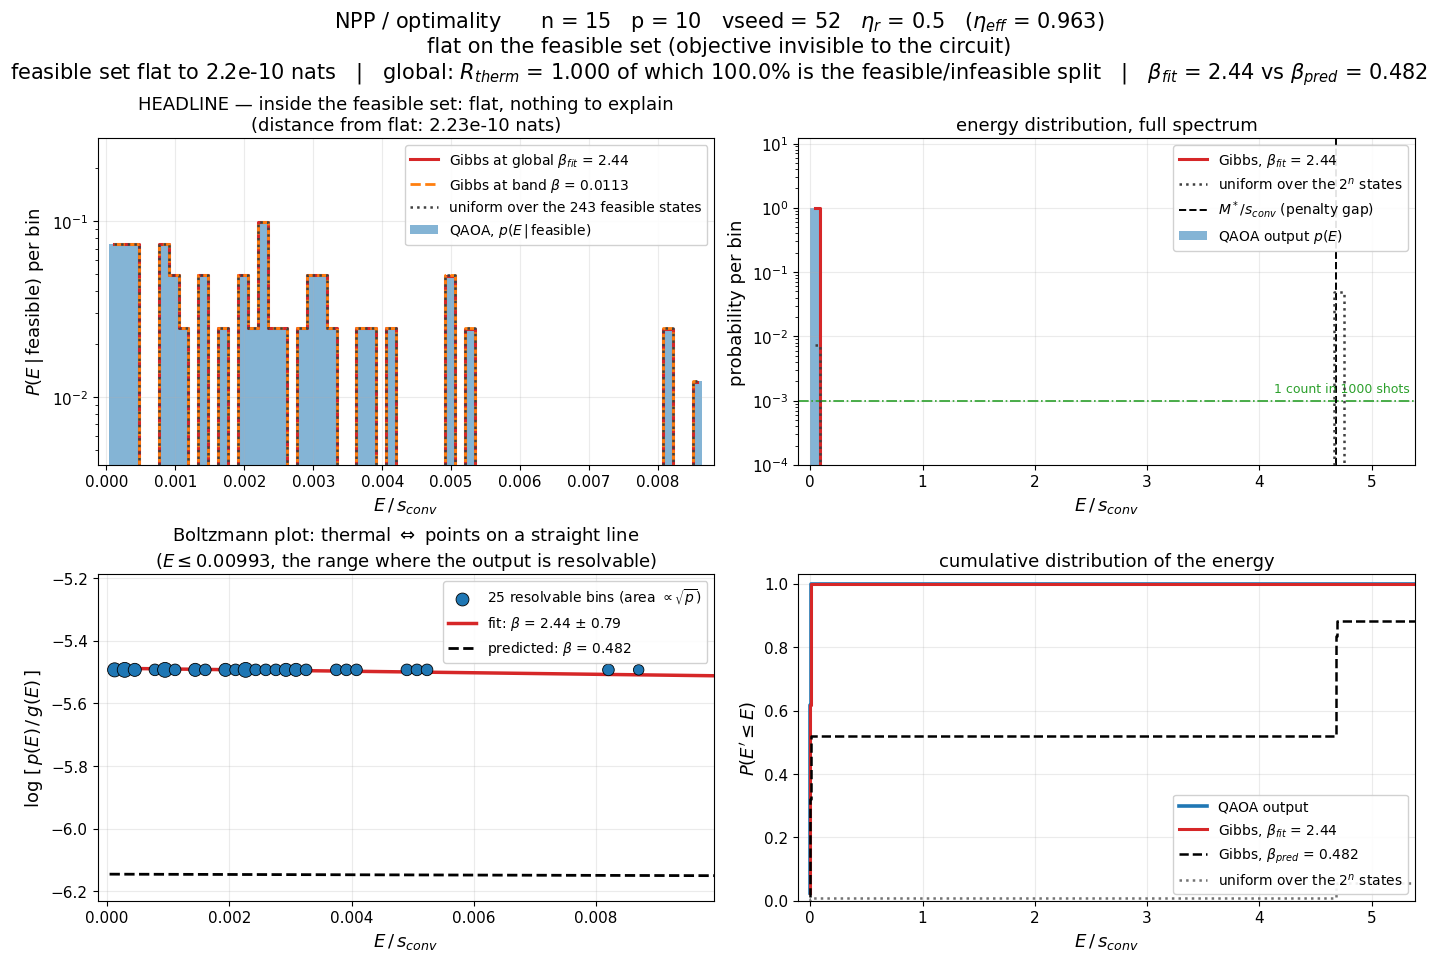

In [192]:
# select parameters
problem_type = "NPP"      # "NPP" | "TSP_rand" | "PO"  (PO was trained with ma-QAOA)
M_strategy   = "optimality"   # "feasibility" | "optimality"
n_bits, vseed, layers, eta_req = 15, 52, 10, 0.5
n_shots = 1000                 # measurement budget the p-values are calibrated on

# print(discover_thermal_runs(problem_type, M_strategy).drop_duplicates(["n_bits", "layers", "eta_req"]))

run = load_thermal_run(problem_type, M_strategy, n_bits, vseed, layers, eta_req, verbose=True)
m, aux = thermal_metrics(run, n_shots=n_shots)
print_thermal_report(m)

fig = plot_thermal_run(run, m, aux)
plt.show()
# fig.savefig(f"./misc_plots/thermal_{problem_type}_{M_strategy}_n{n_bits}_p{layers}_v{vseed}.pdf", bbox_inches="tight", format="pdf")

#### code: statistical analysis over a whole subdir

In [193]:
### Thermal study — statistical analysis over a whole (problem_type, M_strategy) subdir
#
# Runs the pipeline on every stored instance of a subdir and collects the metrics in a DataFrame,
# one row per (n_bits, layers, eta_req, vseed). ~0.5 s per instance (SDPs + statevector), so a
# full 270-file folder takes a couple of minutes; s_conv is memoised, so re-runs are faster.
#
# The summary leads with the FEASIBLE-SET question (is the objective landscape Boltzmann-weighted?)
# and reports the global fit second, because the global fit is dominated by the feasible/infeasible
# split and scores ~1 whenever the circuit merely projects onto the feasible subspace.

_THERMAL_FILE_RE = re.compile(r"test_(?P<pt>.+)_bits_(?P<n>\d+)_vseed_(?P<v>\d+)"
                              r"_layers_(?P<l>\d+)_etareq_(?P<e>[\d.]+)\.txt$")


def discover_thermal_runs(problem_type, M_strategy, dir_data="./data_qaoa", subdir=None,
                          n_bits_list=None, layers_list=None, eta_req_list=None, vseed_list=None):
    """Every stored run of a subdir, as a DataFrame of (n_bits, layers, eta_req, vseed)."""
    subdir = subdir or data_subdir_for(problem_type, M_strategy)
    rows = []
    for path in sorted(glob.glob(os.path.join(dir_data, subdir, f"test_{problem_type}_bits_*.txt"))):
        mt = _THERMAL_FILE_RE.search(os.path.basename(path))
        if mt and mt.group("pt") == problem_type:
            rows.append(dict(n_bits=int(mt.group("n")), layers=int(mt.group("l")),
                             eta_req=float(mt.group("e")), vseed=int(mt.group("v"))))
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f"no runs found in {os.path.join(dir_data, subdir)}")
    for col, keep in (("n_bits", n_bits_list), ("layers", layers_list),
                      ("eta_req", eta_req_list), ("vseed", vseed_list)):
        if keep is not None:
            df = df[df[col].isin(np.atleast_1d(keep))]
    return df.sort_values(["n_bits", "layers", "eta_req", "vseed"]).reset_index(drop=True)


def thermal_sweep(problem_type, M_strategy, dir_data="./data_qaoa", subdir=None, n_shots=1000,
                  n_bits_list=None, layers_list=None, eta_req_list=None, vseed_list=None,
                  save_csv=None, progress=True):
    """Thermal metrics for every stored run of a subdir -> DataFrame (one row per instance)."""
    todo = discover_thermal_runs(problem_type, M_strategy, dir_data, subdir,
                                 n_bits_list, layers_list, eta_req_list, vseed_list)
    subdir = subdir or data_subdir_for(problem_type, M_strategy)
    print(f"{subdir}: {len(todo)} runs "
          f"(n_bits {np.sort(todo.n_bits.unique()).tolist()}, "
          f"layers {np.sort(todo.layers.unique()).tolist()}, "
          f"eta_req {np.sort(todo.eta_req.unique()).tolist()}, {todo.vseed.nunique()} seeds)")
    rows, failures = [], []
    it = todo.itertuples(index=False)
    for r in (tqdm.tqdm(it, total=len(todo)) if progress else it):
        try:
            run = load_thermal_run(problem_type, M_strategy, r.n_bits, r.vseed, r.layers,
                                   r.eta_req, dir_data=dir_data, subdir=subdir)
            rows.append(thermal_metrics(run, n_shots=n_shots)[0])
        except Exception as exc:
            failures.append((r, f"{type(exc).__name__}: {exc}"))
    if failures:
        print(f"!! {len(failures)} runs failed, e.g. {failures[0]}")
    if not rows:
        raise RuntimeError(f"every run of {subdir} failed, e.g. {failures[0] if failures else '?'}")
    df = pd.DataFrame(rows)
    bad = df["d_eta"] > 1e-6
    if bad.any():
        print(f"!! {bad.sum()} runs do not reproduce the stored eta_eff -- rebuild is suspect")
    if save_csv:
        os.makedirs(os.path.dirname(save_csv) or ".", exist_ok=True)
        df.to_csv(save_csv, index=False)
        print(f"written {save_csv}")
    return df


def thermal_summary(df, by=("n_bits", "layers")):
    """Aggregate a sweep. First the feasible set (does the circuit see the objective at all, and if
    so, is that structure Boltzmann?), then the global fit and the coldness."""
    n = len(df)
    frac = lambda mask: f"{100 * mask.mean():.1f}%"
    struct = df[df.feas_structured]
    print(f"=== {n} runs | {df.problem_type.iloc[0]}/{df.M_strategy.iloc[0]} "
          f"| {int(df.n_shots.iloc[0])} shots ===")
    print(f"max |eta_rebuilt - eta_stored| = {df.d_eta.max():.2e}   (pipeline self-check)\n")
    print("verdicts")
    for v, c in df.verdict.value_counts().items():
        print(f"  {c:4d}  ({100 * c / n:5.1f}%)  {v}")

    print(f"\nHEADLINE — inside the feasible set (is the objective landscape Boltzmann-weighted?)")
    print(f"  flat, i.e. objective invisible to the circuit : {frac(~df.feas_structured)}"
          f"   (median distance from flat {df.S_in_feas.median():.2e} nats)")
    if len(struct):
        print(f"  of the {len(struct)} runs WITH resolvable structure:")
        print(f"     R_in_feas  median {struct.R_in_feas.median():.3f}"
              f"     >= 0.9 : {frac(struct.R_in_feas >= 0.9)}"
              f"     >= 0.5 : {frac(struct.R_in_feas >= 0.5)}")
        print(f"     Boltzmann NOT rejected inside the band (p>0.01) : "
              f"{frac(struct.p_therm_feas > 0.01)}")
        print(f"     one temperature at both scales: R_in_feas_glob median "
              f"{struct.R_in_feas_glob.median():.3f}   band/global beta ratio median "
              f"{struct.band_ratio.median():.3g}   (a true Gibbs state gives 1)")
    else:
        print("  no run has resolvable structure inside the feasible set")

    print(f"\nglobal fit over the whole spectrum (dominated by the penalty gap)")
    print(f"  R_therm median {df.R_therm.median():.3f}     >= 0.9 : {frac(df.R_therm >= 0.9)}")
    print(f"  of which the mere feasible/infeasible split: median {100 * df.frac_split.median():.2f}%"
          f"   ({frac(df.frac_split > 0.99)} of runs are >99% split)")
    print(f"  beta_fit/beta_pred median {df.beta_ratio.median():.2f} "
          f"[{df.beta_ratio.quantile(.1):.2f}, {df.beta_ratio.quantile(.9):.2f}]"
          f"   (beta_pred = 1/T_norm = 2.8 p n^(-3/2), a pessimistic bound)")
    print(f"  eta_eff median {df.eta_eff.median():.3f}   "
          f"n_eff median {df.n_eff_states.median():.1f} states")

    agg = df.groupby(list(by)).agg(runs=("R_therm", "size"), S_in=("S_in_feas", "median"),
                                   R_in_feas=("R_in_feas", "median"),
                                   R_in_glob=("R_in_feas_glob", "median"),
                                   flat=("feas_structured", lambda s: 1 - s.mean()),
                                   R_therm=("R_therm", "median"), split=("frac_split", "median"),
                                   beta_ratio=("beta_ratio", "median"),
                                   n_eff=("n_eff_states", "median"),
                                   eta_eff=("eta_eff", "median")).round(3)
    with pd.option_context("display.width", 220, "display.max_columns", None):
        print(f"\nmedians by {list(by)}  (flat = fraction of runs with no structure in the band):\n{agg}")
    return agg


def plot_thermal_summary(df, figsize=(13.5, 9)):
    """Overview of a sweep, led by the feasible-set analysis."""
    n_bits_list = np.sort(df.n_bits.unique())
    layers_list = np.sort(df.layers.unique())
    colors = ListedColormap(plt.cm.viridis(np.linspace(0, .9, max(len(n_bits_list), 2)))).colors
    markers = ["o", "s", "^", "D", "v", "P"]
    n_shots = int(df.n_shots.iloc[0])
    fig, ax = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"thermal study — {df.problem_type.iloc[0]} / {df.M_strategy.iloc[0]}      "
                 f"{len(df)} runs, {df.vseed.nunique()} seeds", fontsize=_FS["suptitle"])

    # (a) HEADLINE: of the structure inside the feasible set, how much is Boltzmann?
    a = ax[0, 0]
    n_def = int(df.R_in_feas.notna().sum())
    for i, nb in enumerate(n_bits_list):
        s = df[(df.n_bits == nb) & df.R_in_feas.notna()]
        if len(s):
            g = s.groupby("layers").R_in_feas
            a.plot(g.median().index, g.median(), color=colors[i], marker=markers[i % len(markers)],
                   ms=8, lw=2, label=f"n = {nb}")
            a.fill_between(g.median().index, g.quantile(.25), g.quantile(.75),
                           color=colors[i], alpha=.15)
        gt = df[df.n_bits == nb].groupby("layers").R_therm.median()
        a.plot(gt.index, gt, color=colors[i], ls=":", lw=1.8)
    a.axhline(1, color="k", lw=1, alpha=.5)
    a.set_xticks(layers_list); a.set_ylim(-.05, 1.05)
    _style(a, f"HEADLINE  solid: $R_{{in\\,feas}}$ ({n_def}/{len(df)} runs with structure)"
              "\n" + r"dotted: global $R_{therm}$, for reference",
           "layers $p$", r"$R_{in\,feas}$", legend_loc="best" if n_def else None)
    if n_def == 0:
        a.text(.5, .5, "no run has resolvable structure\ninside the feasible set", ha="center",
               va="center", transform=a.transAxes, fontsize=_FS["label"], color="C3")

    # (b) is there anything to explain in there at all?
    a = ax[0, 1]
    for i, nb in enumerate(n_bits_list):
        g = df[df.n_bits == nb].groupby("layers").S_in_feas
        a.plot(g.median().index, np.maximum(g.median(), 1e-16), color=colors[i],
               marker=markers[i % len(markers)], ms=8, lw=2, label=f"n = {nb}")
    a.axhline(chi2.isf(0.05, 1) / (2 * n_shots), color="C3", ls="--", lw=1.8,
              label=f"resolvable with {n_shots} shots")
    a.set_yscale("log"); a.set_xticks(layers_list)
    _style(a, "structure inside the feasible set\n"
              r"$KL\,[\,p(\cdot\,|\,\mathrm{feas})\;\|\;\mathrm{uniform}\,]$",
           "layers $p$", "nats")

    # (c) fitted vs predicted coldness (secondary: beta_pred is a pessimistic bound)
    a = ax[1, 0]
    for i, nb in enumerate(n_bits_list):
        s = df[df.n_bits == nb]
        a.scatter(s.beta_pred, s.beta_fit, s=38, alpha=.75, color=colors[i],
                  marker=markers[i % len(markers)], label=f"n = {nb}")
    lims = [min(df.beta_pred.min(), df.beta_fit[df.beta_fit > 0].min()) * .7,
            max(df.beta_pred.max(), df.beta_fit.max()) * 1.4]
    a.plot(lims, lims, "k--", lw=1.5, label=r"$\beta_{fit}=\beta_{pred}$")
    a.set_xscale("log"); a.set_yscale("log"); a.set_xlim(lims); a.set_ylim(lims)
    _style(a, r"global coldness (above the line: colder than $\beta_{pred}$)",
           r"$\beta_{pred} = 1/T_{norm}$", r"$\beta_{fit}$", legend_loc="lower right")

    # (d) census of the verdicts
    a = ax[1, 1]
    counts = df.verdict_base.value_counts().sort_values()
    a.barh(range(len(counts)), counts.values, color="C0", alpha=.8)
    a.set_yticks(range(len(counts)))
    a.set_yticklabels(["\n".join(textwrap.wrap(v, 30)) for v in counts.index],
                      fontsize=_FS["legend"])
    for i, v in enumerate(counts.values):
        a.text(v, i, f" {v} ({100 * v / len(df):.0f}%)", va="center", fontsize=_FS["legend"])
    a.set_xlim(0, counts.max() * 1.3)
    _style(a, "verdicts", "number of runs", "", legend_loc=None)
    return fig

#### run the analysis

Runs the pipeline over every stored instance of one subdir, prints a census of the verdicts, the feasible-set headline and the global fit, lists the least and most thermal runs, and plots:

- **top left — HEADLINE: $R_{in\,feas}$ vs depth**, one curve per problem size (band = interquartile range over seeds and $\eta_r$), computed only over the runs whose feasible set has resolvable structure; the count is in the title. The dotted curves are the global $R_{therm}$ for reference — the gap between them is the point of the whole analysis.
- **top right — how much structure there is to explain**, $S_{in} = KL[\,p(\cdot|{\rm feas})\,\|\,{\rm uniform}\,]$ in nats, log scale, with the level resolvable at $n_{shots}$ marked. Points far below that line mean the circuit samples the feasible set uniformly and the thermal question is empty for those runs.
- **bottom left — fitted vs predicted coldness**, one point per run; above the diagonal is colder than $\beta_{pred}$. Secondary, since $\beta_{pred}$ is a pessimistic bound.
- **bottom right — census of the verdicts** over all the runs of the subdir.

NPP_optimality: 270 runs (n_bits [9, 12, 15], layers [5, 10, 20], eta_req [0.25, 0.5, 0.75], 10 seeds)


100%|██████████| 270/270 [01:02<00:00,  4.32it/s]


written ./data_qaoa/thermal_study/NPP_optimality.csv
=== 270 runs | NPP/optimality | 1000 shots ===
max |eta_rebuilt - eta_stored| = 1.22e-13   (pipeline self-check)

verdicts
   270  (100.0%)  flat on the feasible set (objective invisible to the circuit)

HEADLINE — inside the feasible set (is the objective landscape Boltzmann-weighted?)
  flat, i.e. objective invisible to the circuit : 100.0%   (median distance from flat 4.56e-07 nats)
  no run has resolvable structure inside the feasible set

global fit over the whole spectrum (dominated by the penalty gap)
  R_therm median 1.000     >= 0.9 : 100.0%
  of which the mere feasible/infeasible split: median 100.00%   (100.0% of runs are >99% split)
  beta_fit/beta_pred median 5.36 [3.49, 9.25]   (beta_pred = 1/T_norm = 2.8 p n^(-3/2), a pessimistic bound)
  eta_eff median 0.963   n_eff median 81.0 states

medians by ['n_bits', 'layers']  (flat = fraction of runs with no structure in the band):
               runs  S_in  R_in_feas  R_in_g

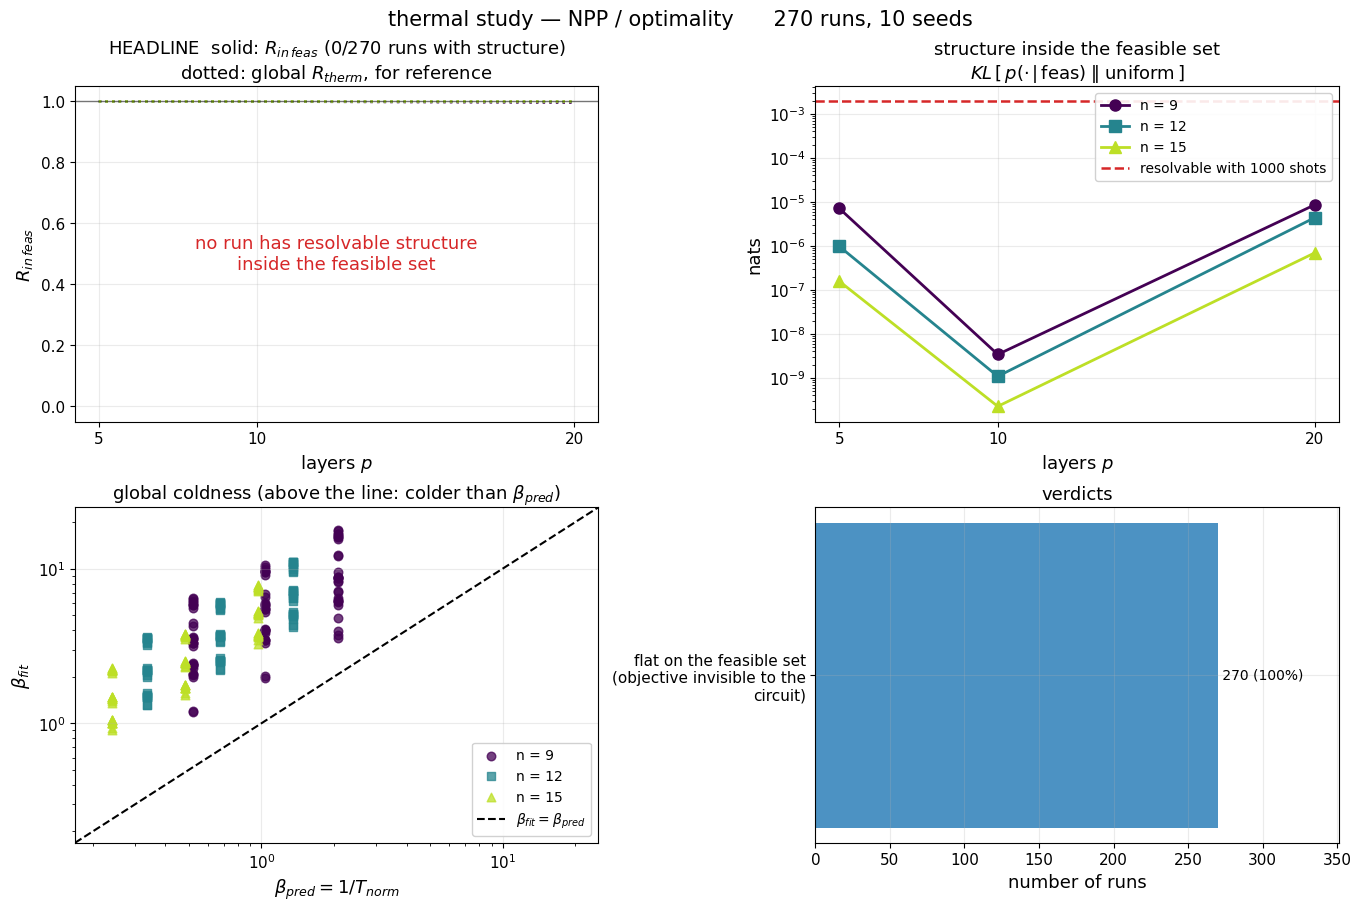

In [196]:
# select parameters
problem_type = "NPP"      # "NPP" | "TSP_rand" | "PO"
M_strategy   = "optimality"   # "feasibility" | "optimality"
n_shots      = 1000
subdir       = None            # e.g. "PO_optimality_maqaoa_percentile" to override data_subdir_for
# narrow the sweep with n_bits_list / layers_list / eta_req_list / vseed_list if it is too slow

df = thermal_sweep(problem_type, M_strategy, n_shots=n_shots, subdir=subdir,
                   save_csv=f"./data_qaoa/thermal_study/"
                            f"{subdir or data_subdir_for(problem_type, M_strategy)}.csv")
agg = thermal_summary(df)

cols = ["n_bits", "layers", "eta_req", "vseed", "S_in_feas", "R_in_feas", "R_therm",
        "frac_split", "beta_ratio", "n_eff_states", "verdict"]
structured = df[df.R_in_feas.notna()]
with pd.option_context("display.width", 240, "display.max_columns", None):
    if len(structured):
        print(f"\nleast thermal inside the feasible set:\n"
              f"{structured.nsmallest(5, 'R_in_feas')[cols].to_string(index=False)}")
        print(f"\nmost thermal inside the feasible set:\n"
              f"{structured.nlargest(5, 'R_in_feas')[cols].to_string(index=False)}")
    else:
        print(f"\nno run has resolvable structure inside the feasible set; by global R_therm:\n"
              f"{df.nsmallest(5, 'R_therm')[cols].to_string(index=False)}")

fig = plot_thermal_summary(df)
plt.show()
# fig.savefig(f"./misc_plots/thermal_summary_{problem_type}_{M_strategy}.pdf", bbox_inches="tight", format="pdf")

## Noisy emulator

### store optimized circuits

In [ ]:
### Build and store EVERY optimized circuit  (eta_req = 0.5; vanilla layers 20 skipped)

eta_required = 0.5
# (problem_type, M_strategy) -> (n_bits list, layers list)
# PO is served by its *_maqaoa* folders, whose depths are 1/2/3 rather than 5/10/20.
combos = {("NPP",      "feasibility"): ([9, 12, 15], [5, 10]),
          ("NPP",      "optimality"):  ([9, 12, 15], [5, 10]),
          ("PO",       "feasibility"): ([6, 9, 12],  [1, 2, 3]),
          ("PO",       "optimality"):  ([6, 9, 12],  [1, 2, 3]),
          ("PO", "optimality_maqaoa_percentile_interp"): ([6, 9, 12, 15], [1, 2, 3]),
          ("TSP_rand", "feasibility"): ([9, 16],     [5, 10])}

done, failed = 0, []
for (problem_type, M_strategy), (bits_list, layers_list) in combos.items():
    subdir = data_subdir_for(problem_type, M_strategy)
    for n_bits in bits_list:
        for layers in layers_list:
            # read the instance seeds off the file names, as elsewhere in this notebook
            pattern = (f"./data_qaoa/{subdir}/test_{problem_type}"
                       f"_bits_{n_bits}_vseed_*_layers_{layers}_etareq_{eta_required}.txt")
            vseeds = sorted(int(re.search(r"_vseed_(\d+)_", f).group(1))
                            for f in glob.glob(pattern))
            if not vseeds:
                print(f"!! no data for {subdir} bits={n_bits} layers={layers}")
                continue

            for vseed in tqdm.tqdm(vseeds, leave=False,
                                   desc=f"{subdir} n={n_bits} p={layers}"):
                try:
                    build_and_save_circuit(problem_type, M_strategy, n_bits, layers, vseed,
                                           eta_required=eta_required)
                    done += 1
                except Exception as e:
                    failed.append((subdir, n_bits, layers, vseed, repr(e)[:90]))
            print(f"{subdir:26s} bits={n_bits:2d} layers={layers:2d} -> {len(vseeds):2d} instances")

print(f"\n{done} circuits stored in ./optimized_circuits, {len(failed)} failures")
for f in failed[:10]:
    print("   ", f)

Vseeds found and to analyse:  [52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


NPP_feasibility            bits= 9 layers= 5 -> 10 instances
Vseeds found and to analyse:  [52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


NPP_feasibility            bits= 9 layers=10 -> 10 instances
Vseeds found and to analyse:  [52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


NPP_feasibility            bits=12 layers= 5 -> 10 instances
Vseeds found and to analyse:  [52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


NPP_feasibility            bits=12 layers=10 -> 10 instances
Vseeds found and to analyse:  [52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


...

PO_optimality_maqaoa       bits=12 layers= 3 -> 10 instances
Vseeds found and to analyse:  [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


TSP_rand_feasibility       bits= 9 layers= 5 -> 10 instances
Vseeds found and to analyse:  [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


TSP_rand_feasibility       bits= 9 layers=10 -> 10 instances
Vseeds found and to analyse:  [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


TSP_rand_feasibility       bits=16 layers= 5 -> 10 instances
Vseeds found and to analyse:  [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


TSP_rand_feasibility       bits=16 layers=10 -> 10 instances

340 circuits stored in ./optimized_circuits, 0 failures


In [128]:
### check sizes and credits of stored circuits

N_SHOTS = 100            # shot count assumed for the cost estimate

rows = []
for f in sorted(glob.glob("./optimized_circuits/*.pkl")):
    stem = re.match(r".*/(.+)_bits_(\d+)_vseed_(\d+)_etareq_([\d.]+)\.pkl", f)
    subdir, n_bits, vseed, eta = stem.group(1), int(stem.group(2)), int(stem.group(3)), float(stem.group(4))
    for layers, e in pickle.load(open(f, "rb")).items():
        hqc, _ = compute_credits(None, n_bits, e["1q_gates"], e["2q_gates"], shots=N_SHOTS)
        rows.append(dict(subdir=subdir, n_bits=n_bits, layers=layers, vseed=vseed,
                         n_1q=e["1q_gates"], n_2q=e["2q_gates"], HQC=hqc))

df = pd.DataFrame(rows).sort_values(["subdir", "n_bits", "layers", "vseed"])
print(df.groupby(["subdir", "n_bits", "layers"])[["n_1q", "n_2q"]].agg(["mean", "min", "max"]))

# HQC_avg          : one circuit, averaged over the vseeds
# HQC_subdir_total : every (n_bits, layers, vseed) of that subdir, shown once per block
cost   = df.groupby(["subdir", "n_bits", "layers"])["HQC"].mean().round(2).to_frame("HQC_avg")
totals = df.groupby("subdir")["HQC"].sum()
subs   = cost.index.get_level_values("subdir")
cost["HQC_subdir_total"] = [f"{totals[s]:.1f}" if first else ""
                            for s, first in zip(subs, ~subs.duplicated())]

print(f"\nCredits at {N_SHOTS} shots per circuit:")
print(cost)

                                      n_1q             n_2q          
                                      mean  min  max   mean  min  max
subdir                n_bits layers                                  
NPP_feasibility       9      5        72.0   72   72   89.4   84   90
                             10      115.0  115  115  179.1  171  180
                      12     5        97.0   97   97  138.6  111  150
                             10      153.8  152  154  287.1  246  300
                      15     5       121.6  119  122  174.9  132  198
                             10      191.7  189  193  389.7  309  447
NPP_optimality        9      5        72.0   72   72   89.4   84   90
                             10      115.0  115  115  179.1  171  180
                      12     5        97.0   97   97  138.3  111  150
                             10      153.8  152  154  286.5  243  300
                      15     5       121.6  119  122  174.9  132  198
                    

### simulate optimized circuit on noisy backend

In [ ]:
### run ONE stored circuit on the H2-2 noisy emulator

problem_type = "PO"             # "NPP" | "PO" | "TSP_rand"
# "feasibility" | "optimality" | (PO only) "optimality_maqaoa_percentile_interp"
M_strategy   = "optimality_maqaoa_percentile_interp"
# "optimality_maqaoa_percentile_interp_M00_Mstar"
n_bits       = 15
vseed        = 742
layers       = 1                # PO (ma-QAOA): 1/2/3    NPP & TSP_rand: 5/10
eta_required = 0.5
n_shots      = 1000
project_name = "noisy"

#### !!!! Uncomment only if you want to send the job to the server
path = run_optimized_circuit_wnoise(problem_type, M_strategy, n_bits, layers, vseed, eta_required=eta_required, n_shots=n_shots, project_name=project_name)
results = check_job_execution(path)
print_top_bitstrings(results, top=10)

Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_n15_v742_l1_20260916_150228
Job status: JobStatusEnum.SUBMITTED — Job has been submitted to Nexus.
no results


In [564]:
### Running ALL noisy executions (H2) for one (problem_type, M_strategy)
## NOTE: use the structures like in only_n_bits to restrct the run to specific sizes/vseeds

problem_type = "PO"             # fixed here; n_bits / vseed / layers are swept below
M_strategy   = "optimality_maqaoa_percentile_interp_M00_Ml1" # "optimality_maqaoa_percentile_interp"   # or "optimality" / "feasibility"
eta_required = 0.5
n_shots      = 1000
project_name = "noisy"
DRY_RUN      = False             # True -> only list what would be sent, no credits spent
only_n_bits  = 12               # restrict to one size; None -> every size in the subdir
# only_vseeds = [642, 742, 842, 942]      # None -> all

# sweep whatever build_and_save_circuit actually stored, so we never submit a circuit
# that failed to build, and the depths come from the files rather than a hardcoded list
subdir  = data_subdir_for(problem_type, M_strategy)
pattern = f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{eta_required}.pkl"

jobs = []
for fname in sorted(glob.glob(pattern)):
    m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
    with open(fname, "rb") as f:
        stored = pickle.load(f)
    for layers in sorted(stored):
        jobs.append((int(m.group(1)), int(m.group(2)), layers))
jobs = [j for j in jobs if (only_n_bits is None or j[0] == only_n_bits)]
                    #    and (only_vseeds is None or j[1] in only_vseeds)]
jobs.sort()

print(f"{len(jobs)} circuits for {subdir}, {n_shots} shots each"
      + (" -- DRY RUN, nothing submitted" if DRY_RUN else ""))

paths = []
for n_bits, vseed, layers in jobs:
    if DRY_RUN:
        print(f"   would submit  n={n_bits:2d}  p={layers:2d}  vseed={vseed}")
        continue
    paths.append(run_optimized_circuit_wnoise(problem_type, M_strategy, n_bits, layers, vseed,
                                              eta_required=eta_required, n_shots=n_shots,
                                              project_name=project_name))

30 circuits for PO_optimality_maqaoa_percentile_interp_M00_Ml1, 1000 shots each
Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_M00_Ml1_n12_v42_l1_20260919_213652
Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_M00_Ml1_n12_v42_l2_20260919_213656
Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_M00_Ml1_n12_v42_l3_20260919_213700
Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_M00_Ml1_n12_v142_l1_20260919_213703
Sent running request..
.. check back later in  /home/edo/Desktop/proj/hot-bigM/code/qaoa/quantinuum_jobs/noisy_PO_optimality_maqaoa_percentile_interp_M00_Ml1_n12_v142_l2_20260919_

RemoteProtocolError: Server disconnected without sending a response.

In [122]:
### check if a job has done

problem_type = "PO"
M_strategy   = "optimality_maqaoa_percentile_interp"   # or "optimality" / "feasibility"
n_bits       = 15
vseed        = 142
layers       = 3
proj_name    = "noisy"          # must match the project_name used at submission

results = retrieve_noisy_job(problem_type, M_strategy, n_bits, layers, vseed,
                             proj_name=proj_name, allow_partial=True)
if results is not None:
    print_top_bitstrings(results, top=10)

Unknown OpType in BackendInfo: `RZZ`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `Rxxyyzz`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `U1q`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `ZZ`, will omit from BackendInfo. Consider updating your pytket version.


bitstring        count    freq   (total 1000 shots)
011000000010010     892   0.892
011000000010000      10   0.010
011000000011010       9   0.009
011000010010010       7   0.007
011000000010011       6   0.006
111000000010010       6   0.006
001000000010010       5   0.005
010000000010010       5   0.005
011000001010010       4   0.004
011000000000010       3   0.003


### count noisy backend $\eta_{eff}$ and plot

In [377]:
### retrieve the finished emulator jobs and tabulate their eta_eff

problem_type = "PO"             # fixed, as in the batch-submission cell
M_strategy   = "optimality_maqaoa_percentile_interp"   # or "optimality" / "feasibility"
eta_required = 0.5
proj_name    = "noisy"          # must match the project_name used at submission
directory    = "PO_small"       # PO instance folder

subdir  = data_subdir_for(problem_type, M_strategy)
pattern = f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{eta_required}.pkl"

records, pending = [], 0
for fname in sorted(glob.glob(pattern)):
    m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
    n_bits, vseed = int(m.group(1)), int(m.group(2))
    with open(fname, "rb") as f:
        stored = pickle.load(f)

    for layers in sorted(stored):
        try:
            counts = retrieve_noisy_job(problem_type, M_strategy, n_bits, layers, vseed,
                                        proj_name=proj_name, allow_partial=True)
        except FileNotFoundError:
            pending += 1                 # never submitted
            continue
        if counts is None:
            pending += 1                 # submitted but not terminal yet
            continue

        # layers + eta_required let eta_eff_from_counts recover the E_f this run was
        # trained against (per-instance percentile for the *_percentile* folders)
        eta, shots, hits = eta_eff_from_counts(counts, problem_type, M_strategy,
                                               n_bits, vseed, directory=directory,
                                               layers=layers, eta_required=eta_required)

        # noiseless reference: the eta_eff recorded when the angles were trained
        train_file = (f"./data_qaoa/{subdir}/test_{problem_type}_bits_{n_bits}"
                      f"_vseed_{vseed}_layers_{layers}_etareq_{eta_required}.txt")
        with open(train_file, "rb") as f:
            eta_train = pickle.load(f)["eta_eff"]

        records.append(dict(n_bits=n_bits, layers=layers, vseed=vseed, shots=shots,
                            hits=hits, eta_noisy=eta, eta_train=eta_train,
                            n_1q=stored[layers]["1q_gates"], n_2q=stored[layers]["2q_gates"]))

df_eta = pd.DataFrame(records).sort_values(["n_bits", "layers", "vseed"]).reset_index(drop=True)
print(f"{subdir}: {len(df_eta)} jobs analysed, {pending} still pending/unsubmitted")
if len(df_eta):
    print(df_eta.groupby(["n_bits", "layers"])[["eta_noisy", "eta_train"]]
                .agg(["mean", "std", "count"]).round(3))

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

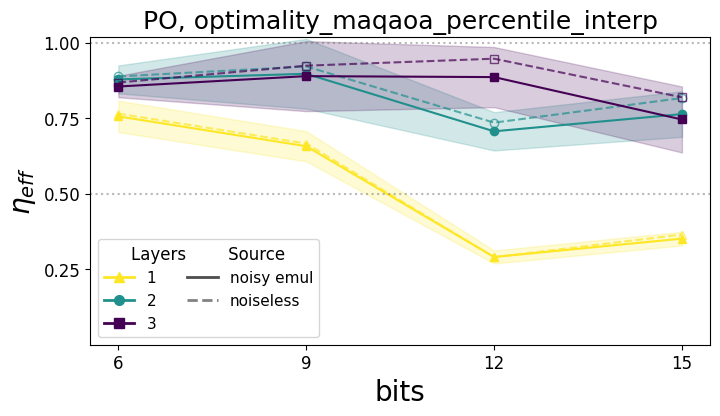

In [256]:
### plot eta_eff vs bits: noisy emulator (solid) vs noiseless model (dashed)

n_bits_list = np.array(sorted(df_eta["n_bits"].unique()))
layers_list = np.array(sorted(df_eta["layers"].unique()))

show_noiseless_band = False   # the 2 bands per depth overlap a lot; off by default

# mean / std over the vseeds, as (layers, n_bits) grids; missing combinations stay NaN
# so the line simply breaks there instead of being silently interpolated.
# eta_train is read from the same rows as eta_noisy, so the two curves are
# instance-matched (same vseeds) even while some emulator jobs are still pending
grp = df_eta.groupby(["layers", "n_bits"])
def _grid(col, how):
    s = grp[col].std(ddof=0) if how == "std" else grp[col].mean()
    return s.unstack().reindex(index=layers_list, columns=n_bits_list).values
mean_noisy, std_noisy = _grid("eta_noisy", "mean"), _grid("eta_noisy", "std")
mean_train, std_train = _grid("eta_train", "mean"), _grid("eta_train", "std")

markers = ["^", "o", "s", "x"]
assert len(layers_list) <= len(markers), "add markers before plotting more depths"
colormap = plt.cm.viridis.reversed()
discr_colors = ListedColormap(colormap(np.linspace(0, 1, len(layers_list))))

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(111)
ax.set_xlabel(r'bits', fontsize = 20)
ax.set_ylabel(r'$\eta_{eff}$', fontsize = 20)
ax.set_xticks(n_bits_list)
ax.set_yticks([.25, .5, .75, 1])
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)


# colour + marker = layers (as in the noiseless plots), line style = emulator vs noiseless
for j, layers in enumerate(layers_list):
    col = discr_colors.colors[j]
    # noisy emulator: solid line, filled marker, std band
    ax.plot(n_bits_list, mean_noisy[j], color=col, marker=markers[j], linestyle='-')
    ax.fill_between(n_bits_list, mean_noisy[j] - std_noisy[j], mean_noisy[j] + std_noisy[j],
                    color=col, alpha=.2)
    # noiseless model: dashed line, hollow marker
    ax.plot(n_bits_list, mean_train[j], color=col, marker=markers[j], linestyle='--',
            alpha=.7, markerfacecolor='none')
    if show_noiseless_band:
        ax.fill_between(n_bits_list, mean_train[j] - std_train[j], mean_train[j] + std_train[j],
                        color=col, alpha=.08)

# ---- Concise legend ----
layers_handles = [Line2D([0], [0], color=c, lw=2, marker=m, markersize=7, label=f'{L}')
                  for c, m, L in zip(discr_colors.colors, markers, layers_list)]
source_handles = [Line2D([0], [0], color='0.3', lw=2, label='noisy emul'),
                  Line2D([0], [0], color='0.3', lw=2, ls='--', alpha=.7, label='noiseless')]
all_handles = layers_handles + source_handles
all_labels  = [h.get_label() for h in all_handles]
ax.legend(handles=all_handles, labels=all_labels, title="Layers        Source",
          title_fontsize=12, fontsize=11, loc="best", ncol=2)
# --------

ax.set_ylim(0, 1.02)
ax.set_title(f"{problem_type}, {M_strategy}", fontsize = "18")
ax.axhline(eta_required, color='0.45', alpha=0.5, linestyle=':')
ax.axhline(1, color='0.45', alpha=0.5, linestyle=':')
plt.show()

# fig.savefig(f"./eta_eff_plots/noisy_{problem_type}_{M_strategy}.pdf", bbox_inches='tight', format="pdf")


In [378]:
### Credit cost of EVERY stored circuit of one (problem_type, M_strategy)
## Same price model as the "check sizes and credits" cell above, but restricted to a
## single subdir and broken down per circuit / per size / per vseed. Submits nothing.

problem_type = "PO"             # "NPP" | "PO" | "TSP_rand"
# "feasibility" | "optimality" | (PO only) "optimality_maqaoa_percentile_interp"
M_strategy   = "optimality_maqaoa_percentile_interp"
eta_required = 0.5
n_shots      = 100             # shots per circuit, as in the batch-submission cell

subdir  = data_subdir_for(problem_type, M_strategy)
pattern = f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{eta_required}.pkl"

rows = []
for fname in sorted(glob.glob(pattern)):
    m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
    n_bits, vseed = int(m.group(1)), int(m.group(2))
    with open(fname, "rb") as f:
        stored = pickle.load(f)
    for layers in sorted(stored):
        e = stored[layers]
        # the stored gate counts carry NO measurements -- run_optimized_circuit_wnoise
        # recompiles with measure_all, so the invoice moves by a few % around this
        hqc, _ = compute_credits(None, n_bits, e["1q_gates"], e["2q_gates"], shots=n_shots)
        rows.append(dict(n_bits=n_bits, vseed=vseed, layers=layers,
                         n_1q=e["1q_gates"], n_2q=e["2q_gates"],
                         HQC=hqc, USD=hqc * CREDITS_TO_USD))

if not rows:
    raise FileNotFoundError(f"no stored circuits match {pattern}")

df_cost = pd.DataFrame(rows).sort_values(["n_bits", "vseed", "layers"], ignore_index=True)
fmt = lambda v: f"{v:9.2f}"

def cumulative(by):
    return df_cost.groupby(by).agg(n_circuits=("HQC", "size"),
                                   HQC=("HQC", "sum"), USD=("USD", "sum"))

print(f"{subdir}   eta_req={eta_required}   {n_shots} shots/circuit   "
      f"{len(df_cost)} circuits   ({CREDITS_TO_USD:.2f} USD per HQC)\n")
print(df_cost.to_string(index=False, float_format=fmt))

print("\n===== cumulative per system size =====")
print(cumulative("n_bits").to_string(float_format=fmt))
print("\n===== cumulative per vseed =====")
print(cumulative("vseed").to_string(float_format=fmt))

## per depth: what a full submission at ONE p costs, across every size and vseed stored.
## These are the numbers to compare against a credit budget -- running p=1 everywhere, then
## p=2 everywhere, etc. They sum to the TOTAL below.
print("\n===== cumulative per depth p (FULL cost of each depth) =====")
print(cumulative("layers").to_string(float_format=fmt))

## the same money split both ways, since cost grows with n AND with p
print("\n===== HQC per depth x size =====")
print(df_cost.pivot_table(index="layers", columns="n_bits", values="HQC",
                          aggfunc="sum", margins=True, margins_name="all")
      .to_string(float_format=fmt))

print(f"\n===== TOTAL =====\n{len(df_cost)} circuits   "
      f"{df_cost['HQC'].sum():.2f} HQC   {df_cost['USD'].sum():.2f} USD")


PO_optimality_maqaoa_percentile_interp   eta_req=0.5   100 shots/circuit   120 circuits   (14.93 USD per HQC)

 n_bits  vseed  layers  n_1q  n_2q       HQC       USD
      6     42       1    18    15      9.56    142.69
      6     42       2    40    30     13.00    194.03
      6     42       3    53    45     16.26    242.69
      6    142       1    18    15      9.56    142.69
      6    142       2    40    30     13.00    194.03
      6    142       3    41    45     16.02    239.10
      6    242       1    18    15      9.56    142.69
      6    242       2    40    30     13.00    194.03
      6    242       3    48    45     16.16    241.19
      6    342       1    18    15      9.56    142.69
      6    342       2    42    30     13.04    194.63
      6    342       3    53    45     16.26    242.69
      6    442       1    18    15      9.56    142.69
      6    442       2    42    30     13.04    194.63
      6    442       3    51    45     16.22    242.09
      6  

## $M_{\ell_1}$ vs $M^*$ noiseless ($M_0=0$)

<!-- ## M0 = 0: the span-proxy fix -- where $M^*$ buys objective quality

The section above is a **negative control**. At the pipeline's own span proxy,
$s_{\rm conv} = (UB_{\rm obj}-LB_{\rm obj}) + M_0\,UB_{\rm pen}$ with $M_0 = M_{\ell_1}(T_{\rm norm})\sim 10^2$,
the penalty term dominates $s_{\rm conv}$ by three decades. Since
$T_{\rm unnorm} = s_{\rm conv}T_{\rm norm}$ and $M \sim T\,c_n$, *both* penalties land at $\sim 10^6$,
the objective is $\sim 10^{-7}$ of the trained Hamiltonian, and
$\max|Q_{\rm norm}(M^*) - Q_{\rm norm}(M_{\ell_1})| = 5\cdot 10^{-8}$. The two arms train the same
circuit, so that comparison cannot discriminate between the two penalty rules at all.

Setting $M_0 = 0$ -- span proxy $=$ objective span only, $M$-free by construction -- cuts the loop.
The self-consistent version of the equation has loop gain $G = B\,T_{\rm norm}c_n \sim 10^3$-$10^5$ and
therefore **no positive root** (`fixed_point_M.py`), which is why $M_0$ is load-bearing rather than a
convenience. With $M_0 = 0$, $M$ drops by 3-5 decades and the objective's share of the normalized
Hamiltonian rises to $\sim 10^{-2}$.

**Both a small $M$ and a converged optimizer are required; neither alone does anything.** Controls
already run: 3000 steps at `tol` $=10^{-4}$ reproduces the 500-step numbers *exactly*, and `tol`
$=10^{-8}$ at the pipeline's own $M$ converges to the blind projector ($\eta_{\rm eff}=0.7500$
exactly). Everything below is therefore at 3000 steps / `tol` $=10^{-8}$, with $M$ pinned
(`np.random.seed(12345)`) because `M_method_opt` samples the feasible spectrum off the global RNG and
otherwise drifts ~3%, which would unmatch the pairs. -->


In [ ]:
### [M0-zero] load dataset A (final, 240 records, one folder per arm)
import glob, pickle
import analyse_M_L1_vs_star as cmpML1        # cell [M00-noisy] uses cmpML1.spectra

A_DIRS = {"M*":   "data_qaoa/PO_optimality_final_Mstar",
          "M_L1": "data_qaoa/PO_optimality_final_Ml1"}
KEEP = ["bits", "layers", "vseed", "qaoa_seed", "M_used", "share_feas", "P_feas", "eta_eff",
        "mean_all", "mean_feas", "E_f", "steps", "tol", "AR", "AR_unif"]

_rows = []
for _arm, _d in A_DIRS.items():
    for _f in sorted(glob.glob(f"{_d}/*.pkl")):
        with open(_f, "rb") as _fh:
            _r = pickle.load(_fh)
        _rows.append({**{k: _r.get(k) for k in KEEP}, "arm": _arm})
df0 = pd.DataFrame(_rows)
df_AR = df0                                   # AR is stored, not derived

print(f"dataset A: {len(df0)} records  {df0['arm'].value_counts().to_dict()}")

## shared styling for every panel below
ARMS0 = {"M*": dict(ls="-", filled=True), "M_L1": dict(ls="--", filled=False)}
_PAL  = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD", "#D65F5F"]
PS    = sorted(df0.layers.unique());  BITS   = sorted(df0.bits.unique())
PS_A  = PS;                           BITS_A = BITS
COL0  = {p: _PAL[i % len(_PAL)] for i, p in enumerate(PS)}
COLN  = {b: _PAL[i % len(_PAL)] for i, b in enumerate(BITS)}

display(df0.groupby(["bits", "layers", "arm"]).agg(
    M=("M_used", "mean"), share=("share_feas", "mean"), P_feas=("P_feas", "mean"),
    eta=("eta_eff", "mean"), AR=("AR", "mean"), n=("vseed", "size")).round(4))

dataset A: 240 records  {'M*': 120, 'M_L1': 120}


M   share  P_feas     eta      AR   n
bits layers arm                                                
6    1      M*      26.2891  0.0032  1.0000  0.9750  0.6624  10
            M_L1   128.6806  0.0006  1.0000  0.9700  0.6610  10
     2      M*      14.0166  0.0059  1.0000  0.9896  0.8154  10
            M_L1    67.6524  0.0012  1.0000  0.9923  0.7025  10
     3      M*       9.7162  0.0085  1.0000  0.9999  0.9067  10
            M_L1    47.3097  0.0017  1.0000  0.9695  0.7749  10
9    1      M*      89.1077  0.0011  1.0000  0.9250  0.7450  10
            M_L1   464.5954  0.0002  1.0000  0.9000  0.6833  10
     2      M*      45.1363  0.0022  1.0000  1.0000  0.7876  10
            M_L1   237.0926  0.0004  1.0000  1.0000  0.6921  10
     3      M*      30.3616  0.0033  1.0000  0.9750  0.8810  10
            M_L1   161.2583  0.0006  1.0000  0.9250  0.7785  10
12   1      M*     210.2247  0.0006  0.5915  0.5915  0.6578  10
            M_L1  1342.5182  0.0001  0.5915  0.5816  0.6564  10
     2      M*     105.7757  0.0011  0.8000  0.7750  0.6572  10
            M_L1   678.1796  0.0002  0.8500  0.8146  0.6429  10
     3      M*      70.9775  0.0016  1.0000  1.0000  0.7327  10
            M_L1   456.7334  0.0002  1.0000  0.9455  0.6742  10
15   1      M*     423.3157  0.0003  0.6029  0.5556  0.6502  10
            M_L1  3239.6474  0.0000  0.6029  0.5143  0.6213  10
     2      M*     212.6174  0.0007  1.0000  0.9557  0.6896  10
            M_L1  1629.5110  0.0001  0.8969  0.7456  0.6379  10
     3      M*     142.2129  0.0010  1.0000  1.0000  0.8122  10
            M_L1  1092.7988  0.0001  1.0000  0.9813  0.6849  10

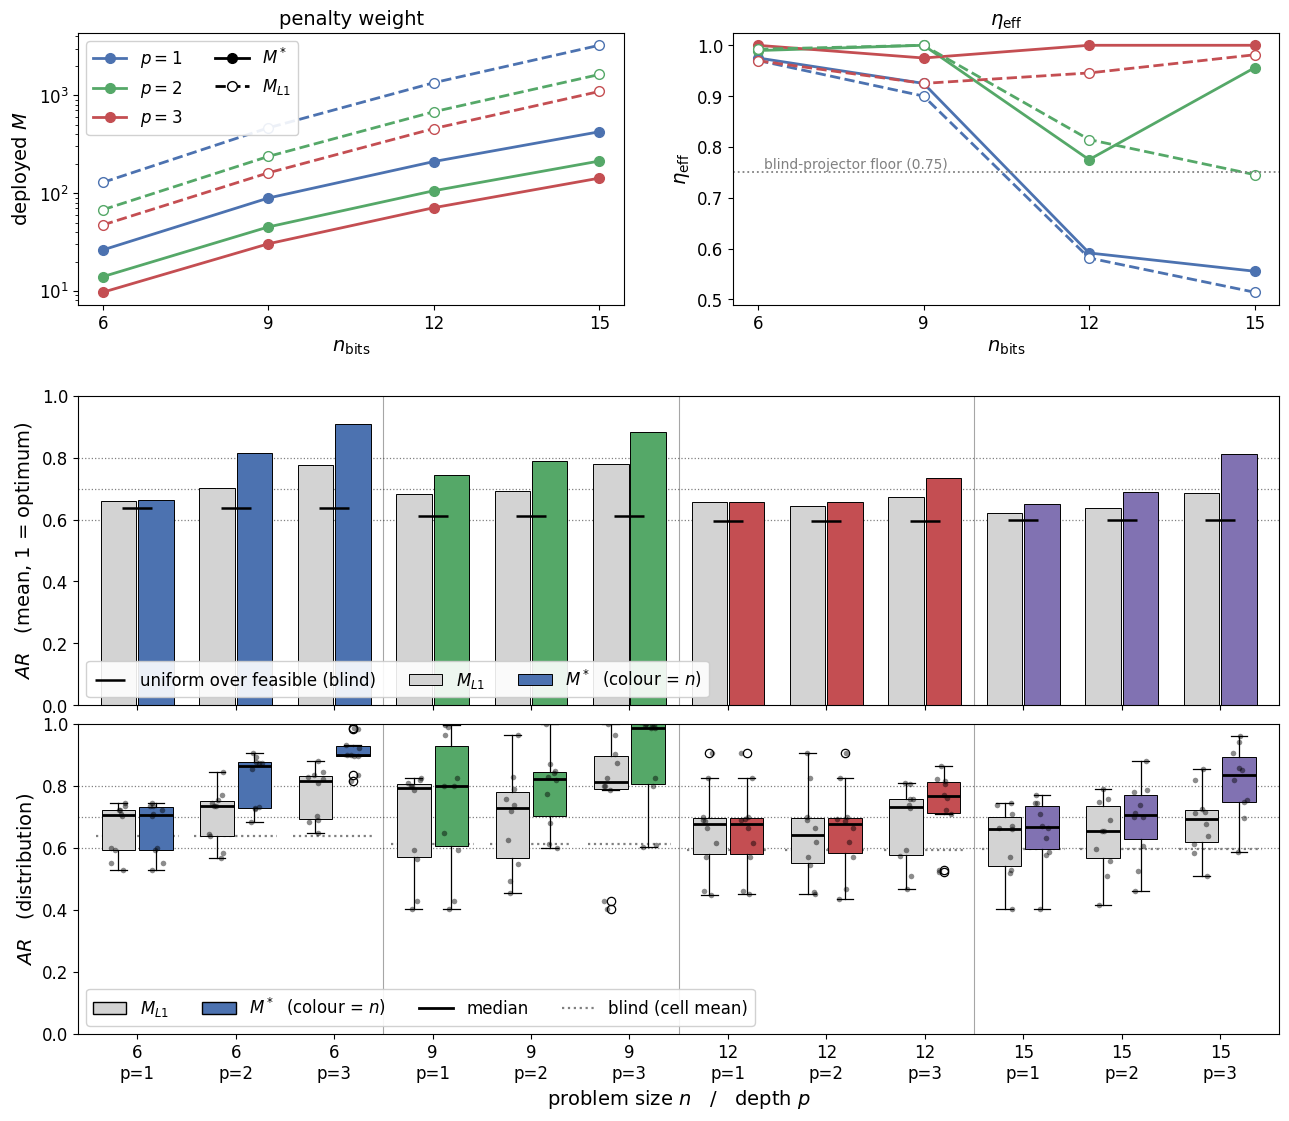


median vs mean AR by (n, p)  -- positive med-mean = left-skewed, mean understates:
             med_M*  mean_M*  med_M_L1  mean_M_L1  med-mean_M*
bits layers                                                   
6    1      +0.7064  +0.6624   +0.7064    +0.6610      +0.0441
     2      +0.8638  +0.8154   +0.7357    +0.7025      +0.0484
     3      +0.8991  +0.9067   +0.8152    +0.7749      -0.0075
9    1      +0.7997  +0.7450   +0.7940    +0.6833      +0.0546
     2      +0.8237  +0.7876   +0.7289    +0.6921      +0.0361
     3      +0.9873  +0.8810   +0.8133    +0.7785      +0.1063
12   1      +0.6775  +0.6578   +0.6758    +0.6564      +0.0197
     2      +0.6765  +0.6572   +0.6425    +0.6429      +0.0193
     3      +0.7666  +0.7327   +0.7327    +0.6742      +0.0340
15   1      +0.6671  +0.6502   +0.6622    +0.6213      +0.0169
     2      +0.7069  +0.6896   +0.6555    +0.6379      +0.0172
     3      +0.8352  +0.8122   +0.6949    +0.6849      +0.0230

paired N=120: 65 wins / 50 ties /

In [14]:
### [M0-zero] THE PAPER FIGURE -- penalty scaling, feasibility, and objective quality
## Everything the M0 = 0 result rests on, in one figure. Four sub-plots, two claims.
##
## TOP ROW (was panel 2). Solid + filled = M* (ours), dashed + hollow = M_L1 (naive), colour = p.
##   (a) the deployed penalty weight. M_L1 sits ~5.9x above M*, and the ratio grows with n.
##   (b) eta_eff, the weight on {feasible AND E_obj <= E_f}. Read this BEFORE the AR rows: AR is
##       conditioned on feasibility, so a good AR on top of a collapsed eta_eff is not a good run
##       (HANDOFF.md section 4). 0.75 is the blind-projector floor, not a success level.
##
## BOTTOM TWO ROWS (was panel 7), sharing the x axis so each cell's mean sits above its own
## distribution. AR is MAXIMISED: 1 = feasible optimum, higher is better.
##   (c) cell means. M_L1 grey, M* coloured by n, black ticks = the blind reference.
##   (d) the same cells as distributions. The means above are LEFT-SKEWED -- at (9,3) the M* median
##       is ~0.99 against a mean of ~0.88, dragged down by two weak instances -- and several cells
##       are a mixture of exact ties plus a few large wins rather than a uniform shift. Where the
##       median dAR is 0 the cell's margin comes from a minority of instances, which is a different
##       claim from "M* is better here" and is invisible in a bar of means.
##       Box = IQR, black line = median, whiskers 1.5*IQR, open circles = outliers, dots = the ten
##       individual instances (jittered horizontally only, so no point's AR is displaced).
##
## The blind reference is an INSTANCE property; the line drawn per cell is the mean of ten
## different values and is a guide only. A run is judged against its OWN instance's AR_unif.

from scipy.stats import wilcoxon

TIE = 0.01
## one place to scale every text element in the figure
FS = dict(tick=12, label=14, title=14, legend=12, note=10)

pv  = df_AR.pivot_table(index=["bits", "layers", "vseed"], columns="arm", values="AR").dropna()
dlt = pv["M*"] - pv["M_L1"]                      # > 0 means M* better (AR is maximised)
nw, nt, nl = (dlt > TIE).sum(), (dlt.abs() <= TIE).sum(), (dlt < -TIE).sum()

gg = df_AR.pivot_table(index=["bits", "layers"], columns="arm", values="AR")
cc = df_AR.pivot_table(index=["bits", "layers"], columns="arm", values="AR", aggfunc="count")
uu = df_AR.groupby(["bits", "layers"]).AR_unif.mean()
_cells = list(gg.index)
xx = np.arange(len(_cells))

## Arms share ONE colour convention across all four sub-plots and both figures of the noisy
## section: M_L1 is always neutral grey, M* always carries the per-size colour COLN[n].
ARMC = {"M_L1": "lightgrey", "M*": None}         # None = per-cell colour, filled in below
_MSTAR_LEGEND = COLN[BITS[0]]                    # a representative M* colour for the legend key

## Nested gridspecs, because the two gaps must differ: a normal one below the top row, to clear its
## axis labels, and a TIGHT one between bars and boxes, which is the whole point of stacking them
## -- a cell's mean has to sit directly above its own distribution. A single hspace cannot do both.
fig = plt.figure(figsize=(15.5, 13.0))
gs_outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 2.35], hspace=.20)
gs_top   = gs_outer[0].subgridspec(1, 2, wspace=.20)
gs_AR    = gs_outer[1].subgridspec(2, 1, hspace=.06)
axM   = fig.add_subplot(gs_top[0, 0])
axE   = fig.add_subplot(gs_top[0, 1])
axBar = fig.add_subplot(gs_AR[0, 0])
axBox = fig.add_subplot(gs_AR[1, 0], sharex=axBar)

## ---- (a) and (b): the two kept sub-plots of panel 2 -------------------------------------------
## ARMS0 / COL0 / PS / handles0 come from the load cell, so they cover whatever depths are on disk.
for ax, (col, ylab, title, scale) in zip(
        (axM, axE),
        [("M_used",  r"deployed $M$",         "penalty weight",    "log"),
         ("eta_eff", r"$\eta_{\rm eff}$",     r"$\eta_{\rm eff}$", "linear")]):
    for arm, st in ARMS0.items():
        for p in PS:
            s  = df0[(df0.arm == arm) & (df0.layers == p)]
            xs = sorted(s.bits.unique())
            ys = [s[s.bits == b][col].mean() for b in xs]
            ax.plot(xs, ys, st["ls"], marker="o", color=COL0[p], lw=2.0, ms=7,
                    markerfacecolor=(COL0[p] if st["filled"] else "white"))
    ax.set_xticks(sorted(df0.bits.unique()))
    ax.set_yscale(scale)
    ax.set_xlabel(r"$n_{\rm bits}$", fontsize=FS["label"])
    ax.set_ylabel(ylab, fontsize=FS["label"])
    ax.set_title(title, fontsize=FS["title"])
    ax.tick_params(labelsize=FS["tick"])

## 0.75 is where a circuit that ignores the objective entirely lands (uniform over the feasible
## set, E_f at the 75th percentile) -- a floor to clear, not a target to reach
axE.axhline(0.75, color="grey", ls=":", lw=1.3)
axE.text(min(df0.bits) + .1, 0.752, "blind-projector floor (0.75)", fontsize=FS["note"],
         color="grey", va="bottom")
## local handles rather than the load cell's handles0: that one labels the arm with the raw column
## name, which prints as a literal "M_L1" instead of a subscript
_h0 = ([plt.Line2D([], [], color=COL0[p], marker="o", lw=2.0, ms=7, label=f"$p={p}$") for p in PS]
       + [plt.Line2D([], [], color="k", ls=st["ls"], marker="o", lw=2.0, ms=7,
                     markerfacecolor=("k" if st["filled"] else "white"),
                     label=("$M^*$" if arm == "M*" else "$M_{L1}$"))
          for arm, st in ARMS0.items()])
axM.legend(handles=_h0, fontsize=FS["legend"], ncol=2, framealpha=.9)

## ---- (c) AR, cell means -----------------------------------------------------------------------
for _y in (.6, .7, .8):
    axBar.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
axBar.bar(xx - .19, gg["M_L1"], .36, color=ARMC["M_L1"], edgecolor="k", lw=.7, zorder=2,
          label="$M_{L1}$")
axBar.bar(xx + .19, gg["M*"], .36, color=[COLN[b] for b, _ in _cells], edgecolor="k", lw=.7,
          zorder=2, label="$M^*$  (colour = $n$)")
axBar.plot(xx, uu.values, "k_", ms=22, mew=1.8, ls="", zorder=5,
           label="uniform over feasible (blind)")
## a cell whose two arms hold different instance counts is not a like-for-like average -- hatch it
for i, idx in enumerate(_cells):
    if cc.loc[idx, "M*"] != cc.loc[idx, "M_L1"]:
        axBar.bar(i - .19, gg["M_L1"].loc[idx], .36, color="none", edgecolor="#b22222",
                  lw=1.2, hatch="///", zorder=4)
        axBar.text(i - .19, gg["M_L1"].loc[idx] + .012,
                   f"{int(cc.loc[idx, 'M_L1'])}/{int(cc.loc[idx, 'M*'])}", fontsize=FS["note"],
                   color="#b22222", ha="center")
axBar.set_ylabel(r"$AR$   (mean, 1 = optimum)", fontsize=FS["label"])
axBar.set_ylim(0, 1)
axBar.tick_params(labelsize=FS["tick"], labelbottom=False)   # x labels live under the boxes
## inside, bottom-left (user's preference, 2026-09-19): it does overlap the foot of the bars, but
## the bars carry no information down there -- every value of interest is the TOP edge -- and an
## inset legend keeps the figure compact
axBar.legend(fontsize=FS["legend"], framealpha=.9, ncol=3, loc="lower left")

## ---- (d) AR, cell distributions ---------------------------------------------------------------
## Same two positions and the same two fills as the bars directly above, so a box can be read
## against its own mean without re-checking the legend.
for _y in (.6, .7, .8):
    axBox.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
_rng = np.random.default_rng(0)                  # fixed, so the jitter is reproducible
for _k, _arm in enumerate(("M_L1", "M*")):       # M_L1 left, M* right -- the bar order above
    _off = (-.19, .19)[_k]
    _fills = ([ARMC["M_L1"]] * len(_cells) if _arm == "M_L1" else [COLN[b] for b, _ in _cells])
    _data = [df_AR[(df_AR.bits == b) & (df_AR.layers == p) & (df_AR.arm == _arm)].AR.values
             for b, p in _cells]
    _bp = axBox.boxplot(_data, positions=xx + _off, widths=.34, patch_artist=True, zorder=2,
                        medianprops=dict(color="black", lw=2.0),
                        boxprops=dict(edgecolor="k", lw=.7),
                        whiskerprops=dict(color="k", lw=.9), capprops=dict(color="k", lw=.9),
                        flierprops=dict(marker="o", mfc="none", mec="k", ms=6, mew=.9))
    for _pa, _fc in zip(_bp["boxes"], _fills):
        _pa.set(facecolor=_fc)
    ## raw instances on top. Black with a light alpha rather than the box colour: on lightgrey the
    ## same-colour dots vanish, and the points only need to show spread, not repeat the arm.
    for _i, _d in enumerate(_data):
        axBox.scatter(np.full(len(_d), _i) + _off + _rng.uniform(-.08, .08, len(_d)), _d,
                      s=16, color="k", alpha=.45, zorder=3, lw=0)
for _i, (b, p) in enumerate(_cells):
    axBox.plot([_i - .42, _i + .42], [uu.loc[(b, p)]] * 2, color="grey", ls=":", lw=1.6, zorder=1)
for _i in range(1, len(_cells)):
    if _cells[_i][0] != _cells[_i - 1][0]:
        axBar.axvline(_i - .5, color="k", lw=.8, alpha=.35)
        axBox.axvline(_i - .5, color="k", lw=.8, alpha=.35)
axBox.set_xticks(xx)
axBox.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=FS["tick"])
axBox.set_xlim(-.6, len(_cells) - .4)
axBox.set_ylim(0, 1)
axBox.tick_params(labelsize=FS["tick"])
axBox.set_xlabel("problem size $n$   /   depth $p$", fontsize=FS["label"])
axBox.set_ylabel(r"$AR$   (distribution)", fontsize=FS["label"])
_hb = [plt.Rectangle((0, 0), 1, 1, fc=ARMC["M_L1"], ec="k"),
       plt.Rectangle((0, 0), 1, 1, fc=_MSTAR_LEGEND, ec="k"),
       plt.Line2D([0], [0], color="k", lw=2.0),
       plt.Line2D([0], [0], color="grey", ls=":", lw=1.6)]
axBox.legend(_hb, ["$M_{L1}$", "$M^*$  (colour = $n$)", "median", "blind (cell mean)"],
             fontsize=FS["legend"], loc="lower left", ncol=4, framealpha=.9)

fig.savefig("misc_plots/M00_paper_figure.pdf", bbox_inches="tight")
fig.savefig("misc_plots/M00_paper_figure.png", dpi=170, bbox_inches="tight")
plt.show()

## median vs mean per cell -- where these disagree, the bar is not the typical instance
_md  = df_AR.pivot_table(index=["bits", "layers"], columns="arm", values="AR", aggfunc="median")
_cmp = pd.DataFrame({"med_M*": _md["M*"], "mean_M*": gg["M*"],
                     "med_M_L1": _md["M_L1"], "mean_M_L1": gg["M_L1"]})
_cmp["med-mean_M*"] = _cmp["med_M*"] - _cmp["mean_M*"]
print("\nmedian vs mean AR by (n, p)  -- positive med-mean = left-skewed, mean understates:")
print(_cmp.to_string(float_format=lambda x: f"{x:+.4f}"))
_dmed = dlt.groupby(level=["bits", "layers"]).median()
_tied = _dmed[_dmed.abs() <= 1e-9]
if len(_tied):
    print(f"\ncells whose MEDIAN dAR is exactly 0 (typical instance shows no difference): "
          f"{[tuple(int(x) for x in i) for i in _tied.index]}")

print(f"\npaired N={len(pv)}: {nw} wins / {nt} ties / {nl} losses   (tie = |dAR| <= {TIE})")
print(f"Wilcoxon p = {wilcoxon(pv['M*'], pv['M_L1']).pvalue:.2e}")
print(f"mean AR  M* {pv['M*'].mean():.4f}  vs  M_L1 {pv['M_L1'].mean():.4f}  "
      f"(margin {dlt.mean():+.4f})")
for n in BITS_A:
    s = dlt[dlt.index.get_level_values("bits") == n]
    print(f"  n={n:2d}: {int((s > TIE).sum())} / {int((s.abs() <= TIE).sum())} / "
          f"{int((s < -TIE).sum())}   margin {s.mean():+.4f}   (N={len(s)})")


## $M_{\ell_1}$ vs $M^*$ noisy emulator

In [ ]:
### [M00-noisy] retrieve the dataset-A emulator jobs, both arms, and pair them with the noiseless run
## Emulator vs the noiseless dataset-A result, on the SAME circuit: each job here was submitted from
## optimized_circuits/..._M00_{Mstar,Ml1}_bits_{n}_vseed_{v}_etareq_0.5.pkl, which was compiled from
## the trained angles in the dataset-A export. So a difference between the two columns is hardware
## noise, not a different circuit.
##
## Two wrinkles this cell works around, both worth knowing:
##
## 1. eta_eff_from_counts defaults to Ef_for_run to recover E_f, which looks for
##       data_qaoa/{subdir}/test_PO_bits_{n}_vseed_{v}_layers_{p}_etareq_{eta}.txt
##    That path does not exist for these arms: dataset A lives in its own per-arm folders,
##    data_qaoa/..._M00_norestart_{Mstar,Ml1}/, holding one PICKLE per record (star_/L1_ prefix
##    kept) rather than the sweep's per-run .txt files. Every norestart record stores its own E_f,
##    so we pass E_f explicitly and never call Ef_for_run.
##
## 2. There is no AR-from-counts helper (only eta_eff_from_counts), so ar_from_counts is defined
##    below. It mirrors the exact-AR definition: mean objective over the FEASIBLE shots only,
##    normalised by the feasible span of that instance.

NS        = [6, 9, 12, 15]          # sizes to retrieve; extend once more sizes have been submitted
PROJ      = "noisy"      # must match project_name at submission
ETA_REQ   = 0.5
DIRECTORY = "PO_small"   # PO instance folder

## obj_pen_unnormalized -> N_idx_from_bits does `lambda N: N * w` on the PO grid, so the notebook
## globals `w` (stocks per bit) and `N_stocks` must be their scalar/array selves here. An earlier
## panel used to leak `w = probs[mask]` (an ARRAY) into the global namespace, which made this cell
## die with "truth value of an array is ambiguous" from deep inside N_idx_from_bits. That leak is
## fixed at source in patch_nb_ML1.py, but re-asserting costs nothing and keeps this cell runnable
## out of order, which is how it will actually be used.
w = 3
N_stocks = np.arange(2, 9)

ARMS    = {"M*":   "optimality_maqaoa_percentile_interp_M00_Mstar",
           "M_L1": "optimality_maqaoa_percentile_interp_M00_Ml1"}
_ARMPFX = {"M*": "star", "M_L1": "L1"}
A_DIR   = {"M*":   "data_qaoa/PO_optimality_final_Mstar",
           "M_L1": "data_qaoa/PO_optimality_final_Ml1"}


def ar_from_counts(counts, n_bits, vseed, directory=DIRECTORY):
    """Feasible approximation ratio of a measured shot distribution.

    AR = (<E_obj>_feas - E_max_feas) / (E_min_feas - E_max_feas), 1 = feasible optimum.
    Conditioned on feasibility exactly like the exact AR, so its effective sample size is
    n_shots * P_feas, NOT n_shots -- that is why AR needs more shots than eta_eff.
    Also returns the SHOT-NOISE standard error of this run's AR -- the uncertainty that comes
    from having measured only n_shots times, with NO contribution from instance-to-instance
    spread. AR is a sample mean of E_obj over the feasible shots, so
        se(AR) = s / sqrt(N_feas) / |E_min_feas - E_max_feas|
    with s the (count-weighted) sample standard deviation of E_obj over those same shots. N_feas,
    not n_shots: the infeasible shots are discarded, so they buy no precision.

    Returns (AR, n_feasible_shots, P_feas_measured, se_AR_shots).
    """
    Q_obj, const_obj, Q_pen, const_pen, _ = obj_pen_unnormalized(
        "PO", n_bits, vseed, directory)
    E_obj_all, E_pen_all = cmpML1.spectra(int(n_bits), int(vseed))
    _f = np.isclose(E_pen_all, 0)
    lo, hi = E_obj_all[_f].min(), E_obj_all[_f].max()

    total = sum(counts.values())
    if total == 0:
        return np.nan, 0, np.nan, np.nan
    acc = nf = 0.0
    _E, _C = [], []                       # feasible outcomes only, and their shot counts
    for bits, c in counts.items():
        x = [int(b) for b in bits]
        if len(x) != n_bits:
            raise ValueError(f"counts key has {len(x)} bits, expected {n_bits}")
        if not np.isclose(evaluate_energy(x, Q_pen, const_pen), 0):
            continue
        _e = evaluate_energy(x, Q_obj, const_obj)
        acc += c * _e
        nf += c
        _E.append(_e)
        _C.append(c)
    if nf == 0:
        return np.nan, 0, 0.0, np.nan
    _mean = acc / nf
    _E, _C = np.asarray(_E, float), np.asarray(_C, float)
    ## count-weighted sample variance of E_obj over the feasible shots, then the standard error of
    ## their mean. Purely sampling: two reruns of the SAME circuit differ by about this much.
    _var = (_C * (_E - _mean) ** 2).sum() / (nf - 1) if nf > 1 else np.nan
    _se = np.sqrt(_var / nf) / abs(lo - hi)
    return (_mean - hi) / (lo - hi), int(nf), nf / total, _se


rows, pending, missing_ref = [], [], []
for arm, m_strategy in ARMS.items():
    subdir = data_subdir_for("PO", m_strategy)
    for fname in sorted(glob.glob(f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{ETA_REQ}.pkl")):
        _m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
        n_bits, vseed = int(_m.group(1)), int(_m.group(2))
        if n_bits not in NS:
            continue
        with open(fname, "rb") as _f:
            stored = pickle.load(_f)

        for layers in sorted(stored):
            ## noiseless reference: the dataset-A record this circuit was compiled from
            _ref = glob.glob(f"{A_DIR[arm]}/{_ARMPFX[arm]}_n{n_bits}_p{layers}_v{vseed}_s*.pkl")
            if not _ref:
                missing_ref.append((arm, n_bits, layers, vseed))
                continue
            with open(_ref[0], "rb") as _f:
                ref = pickle.load(_f)

            try:
                counts = retrieve_noisy_job("PO", m_strategy, n_bits, layers, vseed,
                                            proj_name=PROJ, allow_partial=True)
            except FileNotFoundError:
                pending.append((arm, n_bits, layers, vseed, "never submitted"))
                continue
            if counts is None:
                pending.append((arm, n_bits, layers, vseed, "not terminal yet"))
                continue

            ## E_f passed explicitly -- see note 1 above
            eta_n, shots, hits = eta_eff_from_counts(counts, "PO", m_strategy, n_bits, vseed,
                                                     directory=DIRECTORY, layers=layers,
                                                     eta_required=ETA_REQ, E_f=ref["E_f"])
            ar_n, nfeas, pf_n, ar_se = ar_from_counts(counts, n_bits, vseed)

            rows.append(dict(arm=arm, bits=n_bits, layers=layers, vseed=vseed,
                             qaoa_seed=int(ref["qaoa_seed"]), shots=shots,
                             eta_noisy=eta_n,   eta_exact=float(ref["eta_eff"]),
                             AR_noisy=ar_n,     AR_exact=float(ref["AR"]),
                             Pfeas_noisy=pf_n,  Pfeas_exact=float(ref["P_feas"]),
                             AR_unif=float(ref["AR_unif"]), n_feas_shots=nfeas,
                             AR_se_shots=ar_se,
                             n_1q=stored[layers]["1q_gates"], n_2q=stored[layers]["2q_gates"]))

df_noisy = pd.DataFrame(rows)
print(f"retrieved {len(df_noisy)} jobs for n={NS}   "
      f"({len(pending)} pending/unsubmitted, {len(missing_ref)} without a noiseless reference)")
if pending:
    _pp = pd.DataFrame(pending, columns=["arm", "bits", "layers", "vseed", "why"])
    print("\npending:")
    print(_pp.groupby(["arm", "why"]).size().to_string())
if missing_ref:
    print(f"\n!! no dataset-A record for: {missing_ref[:8]}")

if len(df_noisy):
    df_noisy = df_noisy.sort_values(["bits", "layers", "arm", "vseed"]).reset_index(drop=True)
    df_noisy["d_eta"] = df_noisy.eta_noisy - df_noisy.eta_exact
    df_noisy["d_AR"] = df_noisy.AR_noisy - df_noisy.AR_exact
    print("\nnoise cost (emulator - noiseless), mean over instances:")
    print(df_noisy.groupby(["bits", "layers", "arm"])[["d_eta", "d_AR"]]
          .agg(["mean", "std"]).to_string(float_format=lambda x: f"{x:+.4f}"))
    ## a cell with both arms present at every vseed is the only one that can be compared pairwise
    _cnt = df_noisy.pivot_table(index=["bits", "layers"], columns="arm", values="AR_noisy",
                                aggfunc="count")
    print("\ninstances retrieved per cell:")
    print(_cnt.to_string())


retrieved 240 jobs for n=[6, 9, 12, 15]   (0 pending/unsubmitted, 0 without a noiseless reference)

noise cost (emulator - noiseless), mean over instances:
                   d_eta            d_AR        
                    mean     std    mean     std
bits layers arm                                 
6    1      M*   -0.0092 +0.0056 +0.0004 +0.0084
            M_L1 -0.0101 +0.0042 +0.0052 +0.0099
     2      M*   -0.0117 +0.0080 -0.0017 +0.0074
            M_L1 -0.0132 +0.0050 +0.0020 +0.0054
     3      M*   -0.0215 +0.0056 -0.0011 +0.0024
            M_L1 -0.0216 +0.0047 -0.0035 +0.0050
9    1      M*   -0.0146 +0.0071 +0.0003 +0.0026
            M_L1 -0.0135 +0.0112 -0.0004 +0.0054
     2      M*   -0.0242 +0.0054 -0.0001 +0.0003
            M_L1 -0.0235 +0.0042 -0.0002 +0.0003
     3      M*   -0.0366 +0.0127 -0.0012 +0.0038
            M_L1 -0.0325 +0.0051 -0.0003 +0.0041
12   1      M*   -0.0112 +0.0157 -0.0008 +0.0026
            M_L1 -0.0148 +0.0116 -0.0001 +0.0025
     2     

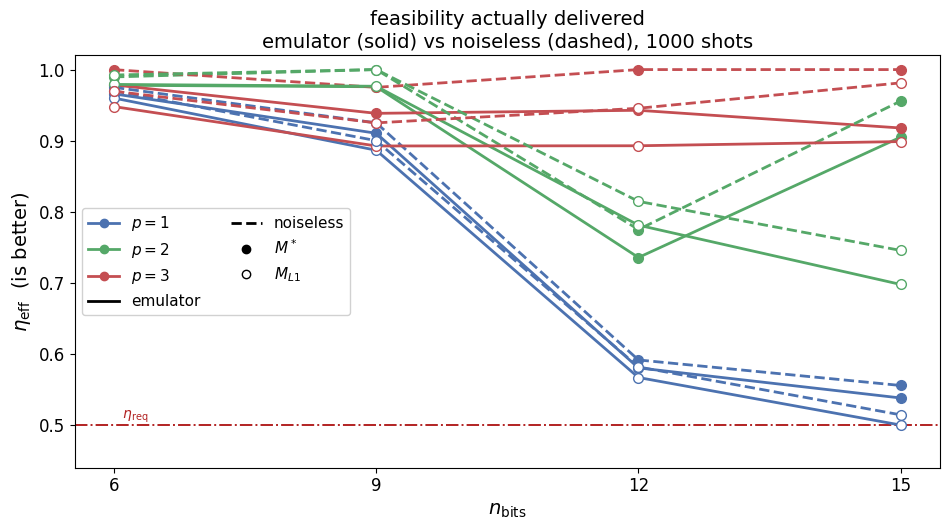

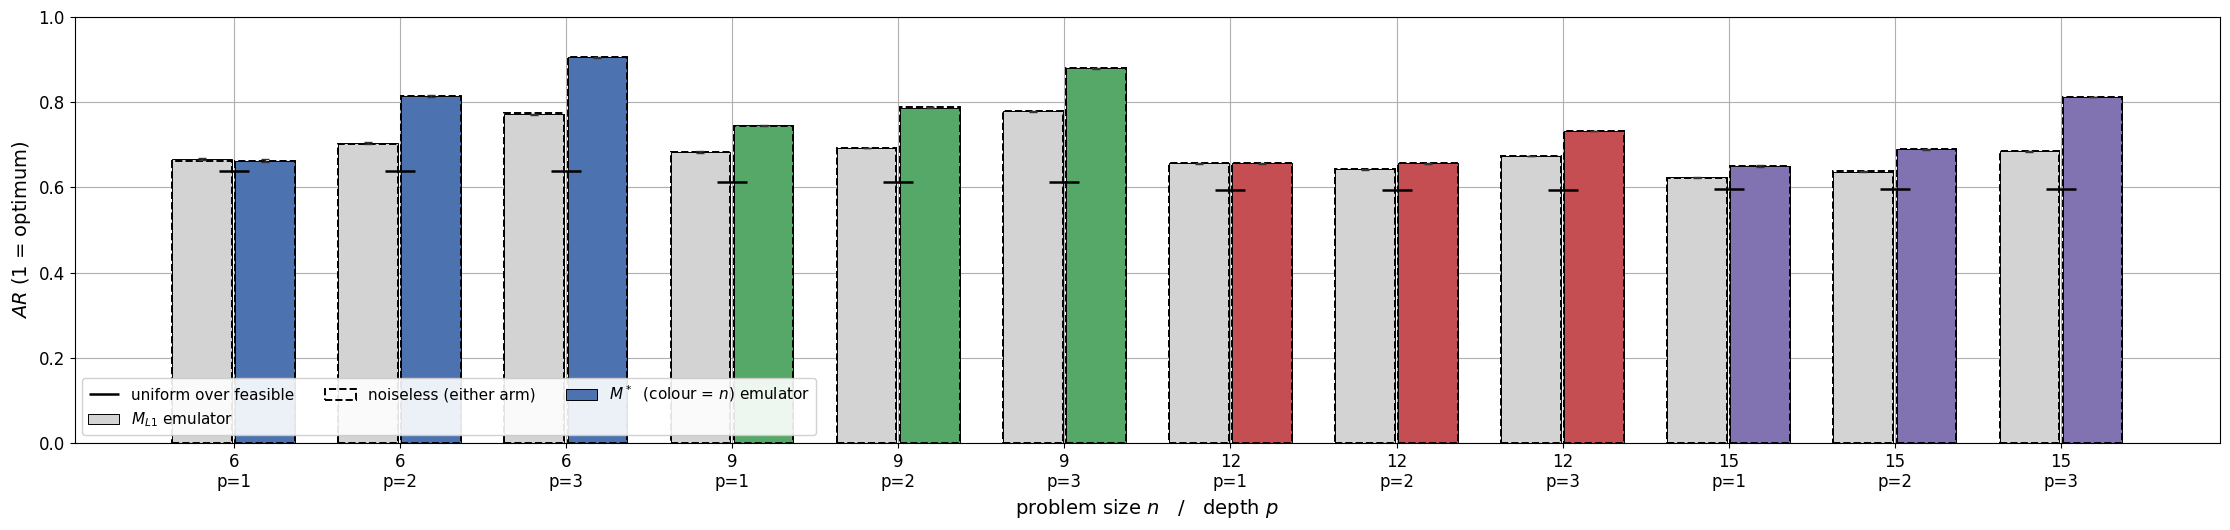

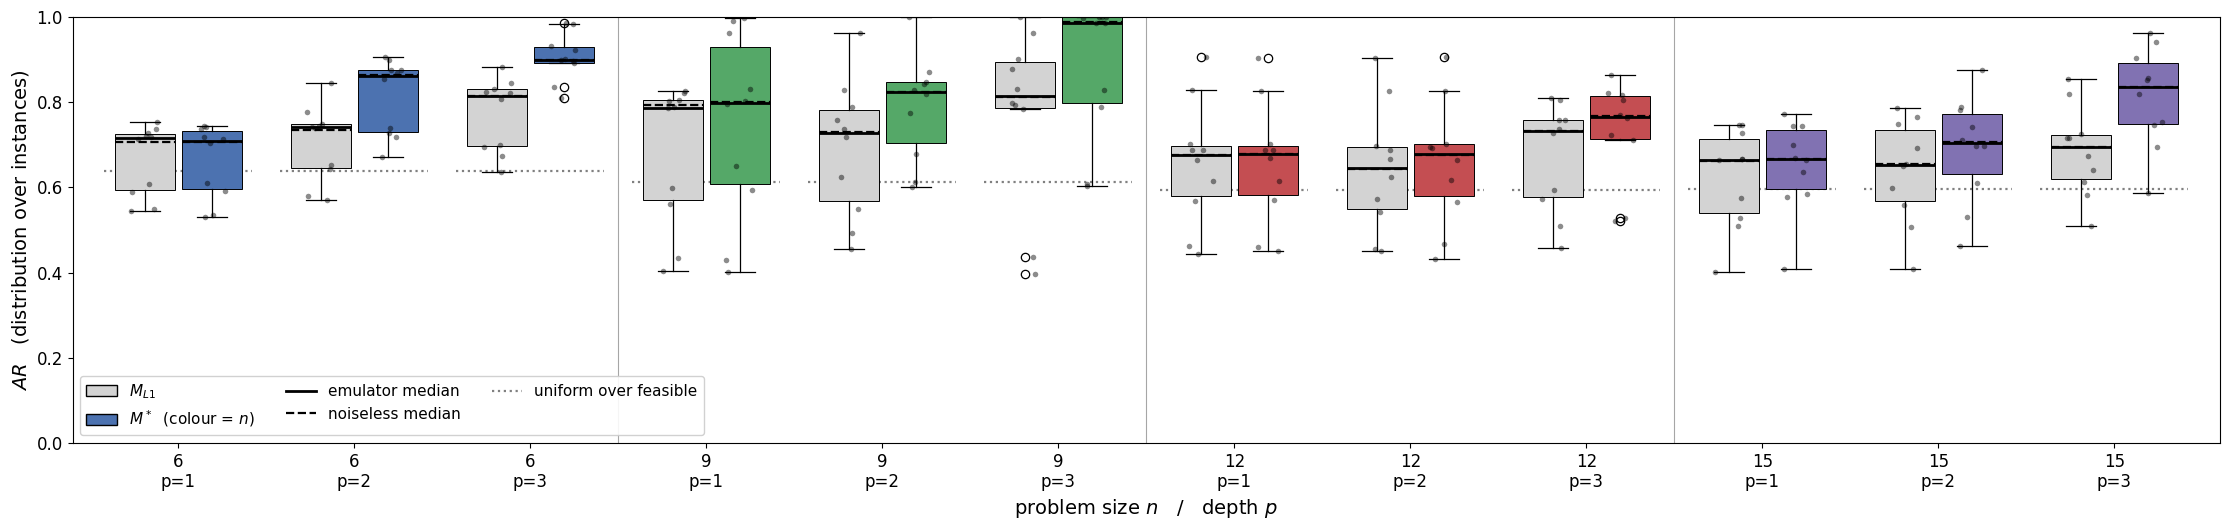


where the uncertainty on a cell mean actually comes from:
  shot_se     = sqrt(sum se_i^2)/K, the 1000-shot sampling error of the MEAN
  instance_sd = spread of AR across the ten instances (what the boxes show)
                     AR  shot_se  instance_sd     ratio
bits layers arm                                        
6    1      M*   0.6628   0.0029       0.0862   30.0378
            M_L1 0.6662   0.0029       0.0831   28.7330
     2      M*   0.8137   0.0021       0.0889   42.7305
            M_L1 0.7045   0.0023       0.0888   38.6450
     3      M*   0.9056   0.0008       0.0556   73.8548
            M_L1 0.7714   0.0020       0.0863   44.1148
9    1      M*   0.7454   0.0014       0.2197  156.8659
            M_L1 0.6829   0.0017       0.1675  100.0340
     2      M*   0.7875   0.0001       0.1242 1639.2439
            M_L1 0.6918   0.0001       0.1596 1539.2904
     3      M*   0.8798   0.0007       0.1639  219.5558
            M_L1 0.7782   0.0013       0.2034  157.9006
12  

In [635]:
### [M00-noisy] eta_eff and AR: M* vs M_L1, emulator vs noiseless
## Two figures, both keyed to the noiseless paper figure so they can be read against it.
##
## eta_eff as LINES vs n, the format of that figure's top row. A bar chart of eta_eff was the wrong
## object: every cell sits between 0.95 and 1.0, so the bars are four indistinguishable full-height
## blocks and the only quantity of interest -- the small gap between emulator and noiseless, which
## is the entire noise effect -- is a couple of pixels. On a line plot with an auto y range that
## same gap is the whole vertical scale.
##   colour   = depth p        (COL0, as in the noiseless figure)
##   solid    = emulator,  dashed = noiseless
##   filled   = M*,        hollow = M_L1
##
## AR stays a BAR chart, in the panel-7 palette: M_L1 lightgrey, M* the per-size colour COLN[n],
## emulator = solid fill, noiseless = dashed open bar of the same footprint. Bar below the dashes
## is what the hardware cost.
##
## Read eta_eff FIRST. AR is conditioned on feasibility, so an AR that survives the noise while
## eta_eff drops just means the feasible shots that got through were good ones -- it is not
## evidence the circuit still works (HANDOFF.md section 4).

if not len(df_noisy):
    print("nothing retrieved yet -- run the cell above once the jobs are terminal")
else:
    ## COLN / COL0 / PS come from the M0=0 load cell; the fallbacks keep this cell runnable if it
    ## is executed before that cell in a fresh kernel.
    _PAL_ = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD", "#D65F5F"]
    _BITS_N = sorted(df_noisy.bits.unique())
    _PS_N   = sorted(df_noisy.layers.unique())
    try:
        _COLN = COLN
    except NameError:
        _COLN = {b: _PAL_[i % len(_PAL_)] for i, b in enumerate(_BITS_N)}
    try:
        _COL0 = COL0
    except NameError:
        _COL0 = {p: _PAL_[i % len(_PAL_)] for i, p in enumerate(_PS_N)}

    _FS = dict(tick=12, label=14, title=14, legend=11, note=10)
    _cells = sorted({(b, p) for b, p in zip(df_noisy.bits, df_noisy.layers)})
    _x = np.arange(len(_cells))

    ## ---- eta_eff: lines vs n, four series per depth --------------------------------------------
    ## source (emulator / noiseless) takes the linestyle and arm takes the marker fill, which is the
    ## same mapping the noiseless figure uses for arm -- so "filled = M*" still reads the same way.
    _figE, _axE = plt.subplots(figsize=(9.6, 5.4))
    _seen = []
    for _arm, _filled in (("M*", True), ("M_L1", False)):
        for _src, _ls, _col in (("noisy", "-", "eta_noisy"), ("exact", "--", "eta_exact")):
        #_src, _ls, _col = "noisy", "-", "eta_noisy"
            for _p in _PS_N:
                _s = df_noisy[(df_noisy.arm == _arm) & (df_noisy.layers == _p)]
                _xs = [b for b in _BITS_N if (_s.bits == b).any()]
                if not _xs:
                    continue
                _ys = [_s[_s.bits == b][_col].mean() for b in _xs]
                _seen += _ys
                _axE.plot(_xs, _ys, _ls, marker="o", color=_COL0[_p], lw=2.0, ms=7,
                            markerfacecolor=(_COL0[_p] if _filled else "white"))
## Range from the DATA, not anchored at eta_req. Every cell currently sits above 0.89, so
    ## forcing 0.5 into view would spend 80% of the axis on empty space and squash the only thing
    ## this plot exists to show -- the emulator-to-noiseless gap, which is a few times 0.01. The
    ## eta_req line is drawn only when it is actually in range; otherwise it is stated in words.
    _lo, _hi = min(_seen), max(_seen)
    _pad = max(.02, .12 * (_hi - _lo))
    _axE.set_ylim(_lo - _pad, min(1.0 + _pad / 3, _hi + _pad))
    if _lo - _pad <= ETA_REQ:
        _axE.axhline(ETA_REQ, color="#b22222", ls="-.", lw=1.4, zorder=1)
        _axE.text(_BITS_N[0], ETA_REQ, r"  $\eta_{\rm req}$", fontsize=_FS["note"],
                  color="#b22222", va="bottom")
    else:
        _axE.text(.99, .02, rf"all cells clear $\eta_{{\rm req}}={ETA_REQ:g}$ "
                            f"(off-scale below)", transform=_axE.transAxes,
                  fontsize=_FS["note"], color="#b22222", ha="right", va="bottom")
    _axE.set_xticks(_BITS_N)
    _axE.set_xlabel(r"$n_{\rm bits}$", fontsize=_FS["label"])
    _axE.set_ylabel(r"$\eta_{\rm eff}$  (is better)", fontsize=_FS["label"])
    _axE.set_title(f"feasibility actually delivered\nemulator (solid) vs noiseless (dashed), "
                   f"{int(df_noisy.shots.max())} shots", fontsize=_FS["title"])
    _axE.tick_params(labelsize=_FS["tick"])
    _hE = ([plt.Line2D([], [], color=_COL0[p], marker="o", lw=2.0, label=f"$p={p}$")
            for p in _PS_N]
           + [plt.Line2D([], [], color="k", ls="-", lw=2.0, label="emulator"),
              plt.Line2D([], [], color="k", ls="--", lw=2.0, label="noiseless"),
              plt.Line2D([], [], color="k", marker="o", ls="", mfc="k", label="$M^*$"),
              plt.Line2D([], [], color="k", marker="o", ls="", mfc="white", label="$M_{L1}$")])
    _axE.legend(handles=_hE, fontsize=_FS["legend"], ncol=2, framealpha=.9)
    _figE.tight_layout()
    _figE.savefig("misc_plots/M00_noisy_eta.pdf", bbox_inches="tight")
    _figE.savefig("misc_plots/M00_noisy_eta.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## ---- AR: bars, panel-7 palette --------------------------------------------------------------
    _FILL = {"M*": [_COLN[b] for b, _ in _cells], "M_L1": ["lightgrey"] * len(_cells)}
    _figA, _axA = plt.subplots(figsize=(2.0 + 1.7 * len(_cells), 5.4))
    # for _y in (.6, .7, .8):
    #     _axA.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
    ## The error bar is SHOT NOISE on the cell mean, not the spread across instances.
    ## Each run's AR carries a sampling error se_i (AR_se_shots, from ar_from_counts); the ten runs
    ## are independent, so the mean of K of them has
    ##     se(cell mean) = sqrt( sum_i se_i^2 ) / K
    ## which is what a rerun of these same ten circuits at the same shot count would scatter by.
    ## Instance-to-instance spread is a property of the PROBLEM SET, not of the measurement, and is
    ## shown separately by the box figure below -- mixing the two into one bar conflates "we did not
    ## measure enough" with "these instances genuinely differ", which is why the std was replaced.
    def _se_of_mean(s):
        s = np.asarray(s, float)
        s = s[~np.isnan(s)]
        return np.sqrt((s ** 2).sum()) / len(s) if len(s) else np.nan

    for _k, _arm in enumerate(("M_L1", "M*")):          # M_L1 left, M* right, as in the bar row
        _o = (-.19, .19)[_k]
        _g = df_noisy[df_noisy.arm == _arm].groupby(["bits", "layers"])
        _mn = [_g["AR_noisy"].mean().get(c, np.nan) for c in _cells]
        _me = [_g["AR_exact"].mean().get(c, np.nan) for c in _cells]
        _sd = [_g["AR_se_shots"].apply(_se_of_mean).get(c, np.nan) for c in _cells]
        _axA.bar(_x + _o, _mn, .36, color=_FILL[_arm], edgecolor="k", lw=.7, zorder=2,
                 yerr=_sd, capsize=3, error_kw=dict(lw=.9, ecolor="#333", zorder=5),
                 label=("$M_{L1}$" if _arm == "M_L1" else "$M^*$  (colour = $n$)") + " emulator")
        ## noiseless: identical footprint, no fill, dashed black outline. Labelled ONCE -- the two
        ## arms' outlines are drawn identically, so a second key would be an indistinguishable
        ## duplicate; which arm an outline belongs to is read off its position, as for the bars.
        _axA.bar(_x + _o, _me, .36, color="none", edgecolor="k", lw=1.4, ls="--", zorder=4,
                 label="noiseless (either arm)" if _arm == "M_L1" else None)
    _bl = [df_noisy[(df_noisy.bits == b) & (df_noisy.layers == p)].AR_unif.mean()
           for b, p in _cells]
    _axA.plot(_x, _bl, "k_", ms=22, mew=1.8, ls="", zorder=6,
              label="uniform over feasible")
    _axA.set_xticks(_x)
    _axA.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=_FS["tick"])
    _axA.set_xlabel("problem size $n$   /   depth $p$", fontsize=_FS["label"])
    _axA.set_ylabel(r"$AR$ (1 = optimum)", fontsize=_FS["label"])
    _axA.set_ylim(0, 1)
    _axA.tick_params(labelsize=_FS["tick"])
    ## The caps are smaller than the bar edges at this shot count, so name their size in the title:
    ## an error bar nobody can see reads as a missing error bar.
    _semax = np.nanmax(df_noisy.groupby(["bits", "layers", "arm"])
                       ["AR_se_shots"].agg(_se_of_mean).values)
    _axA.legend(fontsize=_FS["legend"], ncol=3, framealpha=.9, loc="lower left")
    _axA.grid()
    _figA.tight_layout()
    # _figA.savefig("misc_plots/M00_noisy_AR.pdf", bbox_inches="tight")
    # _figA.savefig("misc_plots/M00_noisy_AR.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## ---- AR: the distribution over instances, same cells ----------------------------------------
    ## The companion to the bars above, and the same figure the noiseless section shows. The bars
    ## carry SHOT noise; these boxes carry INSTANCE spread. They answer different questions and the
    ## two are wildly different in size here -- the boxes span tenths of an AR unit, the error bars
    ## a few thousandths -- so the measurement is not what limits this result, the problem set is.
    ## Boxes are the EMULATOR distribution; the dashed black segment is the noiseless MEDIAN of the
    ## same ten circuits, the box-chart analogue of the dashed outline on the bars.
    _figBx, _axBx = plt.subplots(figsize=(2.0 + 1.7 * len(_cells), 5.4))
    # for _y in (.6, .7, .8):
    #     _axBx.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
    _rngN = np.random.default_rng(0)                 # fixed, so the jitter is reproducible
    for _k, _arm in enumerate(("M_L1", "M*")):
        _o = (-.19, .19)[_k]
        _data = [df_noisy[(df_noisy.bits == b) & (df_noisy.layers == p)
                          & (df_noisy.arm == _arm)].AR_noisy.dropna().values
                 for b, p in _cells]
        ## boxplot chokes on an empty cell, so draw only the populated positions
        _keep = [_i for _i, _d in enumerate(_data) if len(_d)]
        if not _keep:
            continue
        _bp = _axBx.boxplot([_data[_i] for _i in _keep], positions=_x[_keep] + _o, widths=.34,
                            patch_artist=True, zorder=2,
                            medianprops=dict(color="black", lw=2.0),
                            boxprops=dict(edgecolor="k", lw=.7),
                            whiskerprops=dict(color="k", lw=.9), capprops=dict(color="k", lw=.9),
                            flierprops=dict(marker="o", mfc="none", mec="k", ms=6, mew=.9))
        for _pa, _i in zip(_bp["boxes"], _keep):
            _pa.set(facecolor=_FILL[_arm][_i])
        for _i in _keep:
            _axBx.scatter(np.full(len(_data[_i]), _i) + _o
                          + _rngN.uniform(-.08, .08, len(_data[_i])), _data[_i],
                          s=16, color="k", alpha=.45, zorder=3, lw=0)
        ## noiseless median of the very same circuits
        for _i in _keep:
            _nm = df_noisy[(df_noisy.bits == _cells[_i][0]) & (df_noisy.layers == _cells[_i][1])
                           & (df_noisy.arm == _arm)].AR_exact.median()
            _axBx.plot([_i + _o - .17, _i + _o + .17], [_nm] * 2, color="k", ls="--", lw=1.6,
                       zorder=5)
    _blm = [df_noisy[(df_noisy.bits == b) & (df_noisy.layers == p)].AR_unif.mean()
            for b, p in _cells]
    for _i in range(len(_cells)):
        _axBx.plot([_i - .42, _i + .42], [_blm[_i]] * 2, color="grey", ls=":", lw=1.6, zorder=1)
    for _i in range(1, len(_cells)):
        if _cells[_i][0] != _cells[_i - 1][0]:
            _axBx.axvline(_i - .5, color="k", lw=.8, alpha=.35)
    _axBx.set_xticks(_x)
    _axBx.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=_FS["tick"])
    _axBx.set_xlim(-.6, len(_cells) - .4)
    _axBx.set_ylim(0, 1)
    _axBx.tick_params(labelsize=_FS["tick"])
    _axBx.set_xlabel("problem size $n$   /   depth $p$", fontsize=_FS["label"])
    _axBx.set_ylabel(r"$AR$   (distribution over instances)", fontsize=_FS["label"])
    _hbx = [plt.Rectangle((0, 0), 1, 1, fc="lightgrey", ec="k"),
            plt.Rectangle((0, 0), 1, 1, fc=_COLN[_BITS_N[0]], ec="k"),
            plt.Line2D([0], [0], color="k", lw=2.0),
            plt.Line2D([0], [0], color="k", ls="--", lw=1.6),
            plt.Line2D([0], [0], color="grey", ls=":", lw=1.6)]
    _axBx.legend(_hbx, ["$M_{L1}$", "$M^*$  (colour = $n$)", "emulator median",
                        "noiseless median", "uniform over feasible"],
                 fontsize=_FS["legend"], ncol=3, framealpha=.9, loc="lower left")
    _figBx.tight_layout()
    # _figBx.savefig("misc_plots/M00_noisy_AR_box.pdf", bbox_inches="tight")
    # _figBx.savefig("misc_plots/M00_noisy_AR_box.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## the two uncertainties side by side, since the bars and the boxes are easy to conflate
    _cmp_se = df_noisy.groupby(["bits", "layers", "arm"]).agg(
        AR=("AR_noisy", "mean"),
        shot_se=("AR_se_shots", _se_of_mean),
        instance_sd=("AR_noisy", "std"))
    _cmp_se["ratio"] = _cmp_se.instance_sd / _cmp_se.shot_se
    print("\nwhere the uncertainty on a cell mean actually comes from:")
    print("  shot_se     = sqrt(sum se_i^2)/K, the 1000-shot sampling error of the MEAN")
    print("  instance_sd = spread of AR across the ten instances (what the boxes show)")
    print(_cmp_se.to_string(float_format=lambda x: f"{x:.4f}"))

    ## P_feas is where the noise actually shows up, and AR cannot see it -- print it explicitly
    print("\nP_feas, exact vs emulator (the feasibility AR silently discards):")
    print(df_noisy.groupby(["bits", "layers", "arm"])[["Pfeas_exact", "Pfeas_noisy"]].mean()
          .to_string(float_format=lambda x: f"{x:.4f}"))

    ## the paired statement: on each instance, does M* still beat M_L1 once noise is on?
    _pv = df_noisy.pivot_table(index=["bits", "layers", "vseed"], columns="arm",
                               values=["AR_noisy", "AR_exact"]).dropna()
    if len(_pv):
        _dn = _pv[("AR_noisy", "M*")] - _pv[("AR_noisy", "M_L1")]
        _de = _pv[("AR_exact", "M*")] - _pv[("AR_exact", "M_L1")]
        _TIE = 0.01
        for _nm, _d in (("noiseless", _de), ("emulator", _dn)):
            _w = int((_d > _TIE).sum()); _l = int((_d < -_TIE).sum()); _t = len(_d) - _w - _l
            print(f"  {_nm:10s}: {_w} win / {_t} tie / {_l} loss   mean dAR {_d.mean():+.4f}")
        _flip = int((np.sign(_dn) != np.sign(_de)).sum())
        print(f"  instances whose sign flips under noise: {_flip}/{len(_pv)}")


## $M_{\ell_1}$ vs $M^*$ QPU

In [625]:
### Test one job on H2-2

import qnexus as qnx, pickle
from pytket.circuit import OpType

f = ("optimized_circuits/PO_optimality_maqaoa_percentile_interp_M00_Mstar"
     "_bits_6_vseed_42_etareq_0.5.pkl")
c = pickle.load(open(f, "rb"))[1]["tket_circuit"].copy()
c.measure_all()
c = Compile_tket_locally_wbackend(c, device_name="H2-2", optimisation_level=2,
                                  timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)
proj = qnx.projects.get_or_create(name="qpu_probe"); qnx.context.set_active_project(proj)
ref = qnx.circuits.upload(name="probe_n6_v42_p1", circuit=c, project=proj)
job = qnx.start_execute_job(
    programs=[ref], n_shots=[100],
    backend_config=qnx.QuantinuumConfig(device_name="H2-2"),
    name="probe_again")

import time; time.sleep(20)
st = qnx.jobs.status(job)
print(st.status, "|", st.message, "|", getattr(st, "error_detail", None))

JobStatusEnum.ERROR | Program has encountered an error | Job cost exceeds allowed cost (code: 1002)


In [ ]:
### Test one job on H2-1


f = ("optimized_circuits/PO_optimality_maqaoa_percentile_interp_M00_Mstar"
     "_bits_6_vseed_42_etareq_0.5.pkl")
c = pickle.load(open(f, "rb"))[1]["tket_circuit"].copy()   # p=1
c.measure_all()
c = Compile_tket_locally_wbackend(c, device_name="H2-1", optimisation_level=2,
                                  timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

proj = qnx.projects.get_or_create(name="qpu_probe"); qnx.context.set_active_project(proj)
ref = qnx.circuits.upload(name="probe_h21_n6_v42_p1", circuit=c, project=proj)
job = qnx.start_execute_job(programs=[ref], n_shots=[100],
                            backend_config=qnx.QuantinuumConfig(device_name="H2-1", max_batch_cost=50.0), name="probe_h21")

import time
for _ in range(30):                      # ~5 min
    st = qnx.jobs.status(job)
    print(st.status, "|", st.message, "|", getattr(st, "error_detail", None), flush=True)
    if str(st.status).endswith(("ERROR", "COMPLETED", "CANCELLED")):
        break
    time.sleep(10)

JobStatusEnum.SUBMITTED | Job has been submitted to Nexus. | None
JobStatusEnum.ERROR | Program has encountered an error | Job cost exceeds allowed cost (code: 1002)


In [624]:
### Test one job on H2-1 with Marco's flow


cfg = qnx.QuantinuumConfig(device_name="H2-2")

f = ("optimized_circuits/PO_optimality_maqaoa_percentile_interp_M00_Mstar"
     "_bits_6_vseed_42_etareq_0.5.pkl")
c = pickle.load(open(f, "rb"))[1]["tket_circuit"].copy()   # p=1
c.measure_all()
c = Compile_tket_locally_wbackend(c, device_name="H2-2", optimisation_level=2,
                                  timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)

proj = qnx.projects.get_or_create(name="qpu_probe"); qnx.context.set_active_project(proj)
ref = qnx.circuits.upload(name="probe_marcoflow_n6_v42_p1", circuit=c, project=proj)

comp = qnx.start_compile_job(programs=[ref], backend_config=cfg,
                             optimisation_level=2, name="probe_compile")
qnx.jobs.wait_for(comp)
ref_compiled = qnx.jobs.results(comp)[0].get_output()      # <-- submit THIS

job = qnx.start_execute_job(programs=[ref_compiled], n_shots=[100],
                            backend_config=cfg, name="probe_marcoflow")

In [616]:
### [QPU] Running ALL executions on the REAL H2 hardware for one (problem_type, M_strategy)
## THIS SPENDS REAL CREDITS ON THE QPU. The emulator cell above talks to H2-2E; this one talks to
## H2-2. DRY_RUN starts True on purpose -- it lists every circuit that would go out and totals the
## HQC first. Read the total, then set DRY_RUN = False.
##
## Four differences from the emulator cell, all of them safety:
##
##  1. DEVICE can be "H2-2SC", the syntax checker. It costs NOTHING, runs the full submission path
##     and returns garbage counts. Send the batch there once before sending it to H2-2 and you have
##     validated compilation, naming and the save path for free.
##  2. SKIP_ALREADY_SENT. A saved job ref means the server accepted the job, i.e. the credits are
##     already committed; re-running this cell never resubmits one. That also makes the cell a
##     resume: if the loop dies halfway, run it again and it picks up exactly what is missing.
##  3. MAX_COST_MARGIN sets max_cost per circuit, so Nexus refuses a job that would cost more than
##     the estimate times that margin. This is the backstop against a circuit that compiles far
##     worse on the QPU pass than it did locally.
##  4. Jobs land in their OWN directory and project (QPU_DIR / QPU_PROJ) so a QPU run can never be
##     confused with the emulator run of the same circuit at retrieval time.
##
## The submitted circuit is built exactly as in the emulator path: the stored H2-rebased circuit,
## plus measurements, recompiled so the compiler can absorb each qubit's final Rz into the Z-basis
## measurement. Same circuit, different backend -- so QPU vs emulator is a hardware comparison and
## nothing else.

problem_type = "PO"
M_strategy   = "optimality_maqaoa_percentile_interp_M00_Mstar"   # ..._Ml1 for the other arm
eta_required = 0.5
n_shots      = 100               # real shots are precious; 100 resolves the AR gap (see below)
DEVICE       = "H2-2SC"          # "H2-2SC" = free syntax checker | "H2-2" = THE REAL QPU
DRY_RUN      = True              # True -> list + cost only, nothing submitted, nothing spent
only_n_bits  = 6                 # restrict to one size; None -> every size in the subdir
only_vseeds  = None              # e.g. [42, 142]; None -> all
SKIP_ALREADY_SENT = True         # never resubmit an instance that already has a saved job ref
MAX_COST_MARGIN   = 1.2          # per-circuit max_cost = MARGIN * estimate; None -> no cap
DRY_RUN_COMPILE   = False        # True -> compile each circuit for an exact cost (slow, accurate)

## The syntax checker and the QPU must NOT share a ref directory. job_stem carries no device
## name, so an H2-2SC ref would make SKIP_ALREADY_SENT skip that circuit on the real run -- you
## would "submit" the batch to H2-2 and silently send nothing. Derived from DEVICE so that it
## cannot be forgotten, and so the retrieval cell (which reads quantinuum_jobs_qpu) never sees
## syntax-checker counts, which are meaningless.
QPU_DIR  = "quantinuum_jobs_qpu" + ("_sc" if DEVICE.endswith("SC") else "")
QPU_PROJ = "qpu_sc" if DEVICE.endswith("SC") else "qpu"
COMPILE_FOR = "H2-2"             # always compile for the QPU gateset, even when sent to the SC

## Why 100 shots. Resampling the 1000-shot emulator results down to 100 puts the shot-noise error
## on a cell mean at 0.0002-0.0091 in AR, against per-cell M* - M_L1 gaps of 0.03-0.13. Every cell
## except (6, p=1), which is a genuine tie, stays above 3.7 sigma. What 100 shots does NOT support
## is reading eta_eff to 4 decimals to detect the 0.7500 blind-projector signature.


def Run_H2_hardware(compiled_circuit, stem, device_name=DEVICE, project_name=QPU_PROJ,
                    dir_save=QPU_DIR, shots_number=100, max_cost=None, verbose=True):
    """Submit ONE compiled circuit to a real H2 target and save the job ref. Returns the path.

    QuantinuumConfig here carries neither `simulator` nor `noisy_simulation`: both only apply to
    simulated targets, and passing them is what makes a config an emulator config. Device name
    alone selects the backend -- H2-2 is the QPU, H2-2E its emulator, H2-2SC the free checker.
    """
    backend_object = qnx.QuantinuumConfig(device_name=device_name)

    project = qnx.projects.get_or_create(name=project_name)
    qnx.context.set_active_project(project)

    run_name = f"{stem}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    ref_circuit = qnx.circuits.upload(name=f"circ_{run_name}", circuit=compiled_circuit,
                                      project=project)
    ref_job = qnx.start_execute_job(
        programs=[ref_circuit], n_shots=[shots_number], backend_config=backend_object,
        name=run_name, **({"max_cost": float(max_cost)} if max_cost is not None else {}))

    path = Path.cwd() / dir_save / run_name
    qnx.filesystem.save(ref=ref_job, path=path, mkdir=True)
    if verbose:
        print(f"   submitted -> {path.name}")
    return path


def prepare_circuit(problem_type, M_strategy, n_bits, layers, vseed, eta_required=0.5,
                    dir_circ="optimized_circuits", device_name=COMPILE_FOR):
    """The exact object the emulator path submits: stored circuit + measurements, recompiled."""
    filename = (f"./{dir_circ}/{data_subdir_for(problem_type, M_strategy)}"
                f"_bits_{n_bits}_vseed_{vseed}_etareq_{eta_required}.pkl")
    with open(filename, "rb") as f:
        res = pickle.load(f)
    if layers not in res:
        raise KeyError(f"{filename} holds depths {sorted(res)}, not {layers}")
    tk = res[layers]["tket_circuit"].copy()      # copy: measure_all mutates in place
    tk.measure_all()
    tk = Compile_tket_locally_wbackend(tk, device_name=device_name, optimisation_level=2,
                                       timeout=900, target_2qb_gate=OpType.ZZPhase, verbose=False)
    return tk, res[layers]["1q_gates"], res[layers]["2q_gates"]


## ---- build the job list, exactly as the emulator cell does -------------------------------------
subdir  = data_subdir_for(problem_type, M_strategy)
pattern = f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{eta_required}.pkl"

jobs = []
for fname in sorted(glob.glob(pattern)):
    m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
    with open(fname, "rb") as f:
        stored = pickle.load(f)
    for layers in sorted(stored):
        jobs.append((int(m.group(1)), int(m.group(2)), layers, stored[layers]["1q_gates"],
                     stored[layers]["2q_gates"]))
jobs = [j for j in jobs if (only_n_bits is None or j[0] == only_n_bits)
                       and (only_vseeds is None or j[1] in only_vseeds)]
jobs.sort()

if SKIP_ALREADY_SENT:
    _before = len(jobs)
    jobs = [j for j in jobs
            if not list_job_paths(problem_type, M_strategy, j[0], j[2], j[1],
                                  proj_name=QPU_PROJ, dir_name=QPU_DIR)]
    if _before != len(jobs):
        print(f"resume: {_before - len(jobs)} already submitted to {QPU_DIR}, skipping them")

## ---- cost, BEFORE anything is sent -------------------------------------------------------------
## compute_credits uses HQC = 5 + (n_1q + 10*n_2q + 5*2n) * shots/5000. Fed the STORED gate counts
## it slightly OVER-estimates, because the recompile above absorbs each qubit's final Rz into the
## measurement: against 120 already-invoiced H2-2E jobs the stored counts came out 0.4-4% high.
## So the quick estimate is a safe upper bound. DRY_RUN_COMPILE=True compiles instead, which is
## exact but pays the full compile time (minutes per circuit at n=15 p=3).
_rows = []
for n_bits, vseed, layers, g1, g2 in jobs:
    if DRY_RUN_COMPILE:
        _tk, _, _ = prepare_circuit(problem_type, M_strategy, n_bits, layers, vseed, eta_required)
        g1, g2 = _tk.n_1qb_gates(), _tk.n_2qb_gates()
    _hqc, _ = compute_credits(None, n_bits, g1, g2, shots=n_shots)
    _rows.append(dict(n_bits=n_bits, vseed=vseed, p=layers, n_1q=g1, n_2q=g2, HQC=_hqc))
df_submit = pd.DataFrame(_rows)

print(f"\n{len(jobs)} circuits for {subdir}   device={DEVICE}   {n_shots} shots each"
      + ("   -- DRY RUN, nothing submitted" if DRY_RUN else ""))
if len(df_submit):
    print(df_submit.groupby(["n_bits", "p"])
          .agg(circuits=("HQC", "size"), HQC=("HQC", "sum"))
          .to_string(float_format=lambda x: f"{x:10.2f}"))
    _tot = df_submit.HQC.sum()
    _tag = "  (SYNTAX CHECKER -- costs nothing)" if DEVICE.endswith("SC") else ""
    print(f"\nTOTAL {'exact' if DRY_RUN_COMPILE else 'estimated (upper bound)'}: "
          f"{_tot:.2f} HQC{_tag}")
    print(f"  the fixed +5/circuit accounts for {500 * len(df_submit) / _tot:.0f}% of that")

## ---- submit ------------------------------------------------------------------------------------
paths = []
for n_bits, vseed, layers, g1, g2 in jobs:
    _est = float(df_submit[(df_submit.n_bits == n_bits) & (df_submit.vseed == vseed)
                           & (df_submit.p == layers)].HQC.iloc[0])
    if DRY_RUN:
        print(f"   would submit  n={n_bits:2d}  p={layers:2d}  vseed={vseed:4d}   ~{_est:7.2f} HQC")
        continue
    try:
        _tk, _, _ = prepare_circuit(problem_type, M_strategy, n_bits, layers, vseed, eta_required)
        paths.append(Run_H2_hardware(
            _tk, job_stem(problem_type, M_strategy, n_bits, layers, vseed, QPU_PROJ),
            device_name=DEVICE, shots_number=n_shots,
            max_cost=(_est * MAX_COST_MARGIN if MAX_COST_MARGIN else None)))
    except Exception as _e:
        ## one bad submission must not abandon the batch -- the failed instance simply has no ref
        ## file, so re-running this cell picks it up again
        print(f"   FAILED  n={n_bits} p={layers} v={vseed}: {type(_e).__name__}: {_e}")

if not DRY_RUN:
    print(f"\nsubmitted {len(paths)}/{len(jobs)} circuits to {DEVICE}; refs in {QPU_DIR}/")


resume: 6 already submitted to quantinuum_jobs_qpu_sc, skipping them

24 circuits for PO_optimality_maqaoa_percentile_interp_M00_Mstar   device=H2-2SC   100 shots each   -- DRY RUN, nothing submitted
          circuits        HQC
n_bits p                     
6      1         8      76.42
       2         8     102.94
       3         8     128.28

TOTAL estimated (upper bound): 307.64 HQC  (SYNTAX CHECKER -- costs nothing)
  the fixed +5/circuit accounts for 39% of that
   would submit  n= 6  p= 1  vseed= 242   ~   9.28 HQC
   would submit  n= 6  p= 2  vseed= 242   ~  12.88 HQC
   would submit  n= 6  p= 3  vseed= 242   ~  16.20 HQC
   would submit  n= 6  p= 1  vseed= 342   ~   9.68 HQC
   would submit  n= 6  p= 2  vseed= 342   ~  12.84 HQC
   would submit  n= 6  p= 3  vseed= 342   ~  16.24 HQC
   would submit  n= 6  p= 1  vseed= 442   ~   9.64 HQC
   would submit  n= 6  p= 2  vseed= 442   ~  13.06 HQC
   would submit  n= 6  p= 3  vseed= 442   ~  16.20 HQC
   would submit  n= 6  p= 1  

In [ ]:
### [QPU] retrieve the hardware jobs and pair them with the emulator and the noiseless run
## The twin of the [M00-noisy] retrieval cell, pointed at the QPU directory and project. It builds
## df_qpu with the SAME columns as df_noisy, so every downstream plot can treat the two alike.
##
## Requires the [M00-noisy] retrieval cell to have been run: ar_from_counts, eta_eff_from_counts
## and the E_f workaround live there and are not duplicated here (two copies would drift).

QPU_DIR   = "quantinuum_jobs_qpu"
QPU_PROJ  = "qpu"
NS_QPU    = [6]            # sizes to retrieve; extend as more are submitted
ETA_REQ   = 0.5
DIRECTORY = "PO_small"
ARMS    = {"M*":   "optimality_maqaoa_percentile_interp_M00_Mstar",
           "M_L1": "optimality_maqaoa_percentile_interp_M00_Ml1"}
_ARMPFX = {"M*": "star", "M_L1": "L1"}
A_DIR   = {"M*":   "data_qaoa/PO_optimality_final_Mstar",
           "M_L1": "data_qaoa/PO_optimality_final_Ml1"}

for _needed in ("ar_from_counts", "eta_eff_from_counts"):
    if _needed not in dir():
        raise NameError(f"{_needed} is undefined -- run the [M00-noisy] retrieval cell first")

rows, pending, missing_ref = [], [], []
for arm, m_strategy in ARMS.items():
    subdir = data_subdir_for("PO", m_strategy)
    for fname in sorted(glob.glob(
            f"./optimized_circuits/{subdir}_bits_*_vseed_*_etareq_{ETA_REQ}.pkl")):
        _m = re.search(r"_bits_(\d+)_vseed_(\d+)_", fname)
        n_bits, vseed = int(_m.group(1)), int(_m.group(2))
        if n_bits not in NS_QPU:
            continue
        with open(fname, "rb") as _f:
            stored = pickle.load(_f)

        for layers in sorted(stored):
            ## noiseless reference: the dataset-A record this circuit was compiled from
            _ref = glob.glob(f"{A_DIR[arm]}/{_ARMPFX[arm]}_n{n_bits}_p{layers}_v{vseed}_s*.pkl")
            if not _ref:
                missing_ref.append((arm, n_bits, layers, vseed))
                continue
            with open(_ref[0], "rb") as _f:
                ref = pickle.load(_f)

            try:
                counts = retrieve_noisy_job("PO", m_strategy, n_bits, layers, vseed,
                                            proj_name=QPU_PROJ, dir_name=QPU_DIR,
                                            allow_partial=True)
            except FileNotFoundError:
                pending.append((arm, n_bits, layers, vseed, "never submitted"))
                continue
            if counts is None:
                pending.append((arm, n_bits, layers, vseed, "not terminal yet"))
                continue

            eta_q, shots, hits = eta_eff_from_counts(counts, "PO", m_strategy, n_bits, vseed,
                                                     directory=DIRECTORY, layers=layers,
                                                     eta_required=ETA_REQ, E_f=ref["E_f"])
            ar_q, nfeas, pf_q, ar_se = ar_from_counts(counts, n_bits, vseed)

            rows.append(dict(arm=arm, bits=n_bits, layers=layers, vseed=vseed,
                             qaoa_seed=int(ref["qaoa_seed"]), shots=shots,
                             eta_qpu=eta_q,   eta_exact=float(ref["eta_eff"]),
                             AR_qpu=ar_q,     AR_exact=float(ref["AR"]),
                             Pfeas_qpu=pf_q,  Pfeas_exact=float(ref["P_feas"]),
                             AR_unif=float(ref["AR_unif"]), n_feas_shots=nfeas,
                             AR_se_shots=ar_se,
                             n_1q=stored[layers]["1q_gates"], n_2q=stored[layers]["2q_gates"]))

df_qpu = pd.DataFrame(rows)
print(f"retrieved {len(df_qpu)} QPU jobs for n={NS_QPU}   "
      f"({len(pending)} pending/unsubmitted, {len(missing_ref)} without a noiseless reference)")
if pending:
    print("\npending:")
    print(pd.DataFrame(pending, columns=["arm", "bits", "layers", "vseed", "why"])
          .groupby(["arm", "why"]).size().to_string())
if missing_ref:
    print(f"\n!! no dataset-A record for: {missing_ref[:8]}")

if len(df_qpu):
    df_qpu = df_qpu.sort_values(["bits", "layers", "arm", "vseed"]).reset_index(drop=True)
    df_qpu["d_eta"] = df_qpu.eta_qpu - df_qpu.eta_exact
    df_qpu["d_AR"] = df_qpu.AR_qpu - df_qpu.AR_exact
    print("\nhardware cost (QPU - noiseless), mean over instances:")
    print(df_qpu.groupby(["bits", "layers", "arm"])[["d_eta", "d_AR"]]
          .agg(["mean", "std"]).to_string(float_format=lambda x: f"{x:+.4f}"))

    ## the same circuits on the emulator, if that section has been run -- the single number that
    ## says whether the noise model was right
    if "df_noisy" in dir() and len(df_noisy):
        _k = ["arm", "bits", "layers", "vseed"]
        _j = df_qpu.merge(df_noisy[_k + ["eta_noisy", "AR_noisy", "Pfeas_noisy"]], on=_k,
                          how="inner")
        if len(_j):
            print(f"\n{len(_j)} circuits have BOTH a QPU and an emulator run:")
            print(_j.assign(d_eta_qe=_j.eta_qpu - _j.eta_noisy,
                            d_AR_qe=_j.AR_qpu - _j.AR_noisy)
                  .groupby(["bits", "layers", "arm"])[["d_eta_qe", "d_AR_qe"]].mean()
                  .to_string(float_format=lambda x: f"{x:+.4f}"))
            print("  (QPU - emulator: how far the emulator's noise model missed)")


In [ ]:
### [QPU] eta_eff and AR on hardware: M* vs M_L1
## Same two figures and the same conventions as the emulator section, so they can be read side by
## side: eta_eff as LINES vs n (a bar chart of values all sitting near 1.0 hides the only thing
## worth seeing), AR as BARS with M_L1 lightgrey and M* in the per-size colour COLN[n].
##
## The AR error bars are SHOT NOISE on the cell mean, not the spread across instances:
##     se(cell mean) = sqrt( sum_i se_i^2 ) / K
## with se_i the sampling error of one run's AR. Instance spread is a property of the problem set,
## not of the measurement, and is shown by the box figure at the end.

if "df_qpu" not in dir() or not len(df_qpu):
    print("nothing retrieved yet -- run the QPU retrieval cell once the jobs are terminal")
else:
    _PAL_ = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD", "#D65F5F"]
    _BITS_Q = sorted(df_qpu.bits.unique())
    _PS_Q   = sorted(df_qpu.layers.unique())
    try:
        _COLN = COLN
    except NameError:
        _COLN = {b: _PAL_[i % len(_PAL_)] for i, b in enumerate(_BITS_Q)}
    try:
        _COL0 = COL0
    except NameError:
        _COL0 = {p: _PAL_[i % len(_PAL_)] for i, p in enumerate(_PS_Q)}

    _FS = dict(tick=12, label=14, title=14, legend=11, note=10)
    _cells = sorted({(b, p) for b, p in zip(df_qpu.bits, df_qpu.layers)})
    _x = np.arange(len(_cells))

    def _se_of_mean(s):
        s = np.asarray(s, float)
        s = s[~np.isnan(s)]
        return np.sqrt((s ** 2).sum()) / len(s) if len(s) else np.nan

    ## ---- eta_eff: QPU vs noiseless, lines ------------------------------------------------------
    _figE, _axE = plt.subplots(figsize=(9.6, 5.4))
    _seen = []
    for _arm, _filled in (("M*", True), ("M_L1", False)):
        for _ls, _col in (("-", "eta_qpu"), ("--", "eta_exact")):
            for _p in _PS_Q:
                _s = df_qpu[(df_qpu.arm == _arm) & (df_qpu.layers == _p)]
                _xs = [b for b in _BITS_Q if (_s.bits == b).any()]
                if not _xs:
                    continue
                _ys = [_s[_s.bits == b][_col].mean() for b in _xs]
                _seen += _ys
                _axE.plot(_xs, _ys, _ls, marker="o", color=_COL0[_p], lw=2.0, ms=9,
                          markerfacecolor=(_COL0[_p] if _filled else "white"))
    _lo, _hi = min(_seen), max(_seen)
    _pad = max(.02, .12 * (_hi - _lo))
    _axE.set_ylim(_lo - _pad, min(1.0 + _pad / 3, _hi + _pad))
    if _lo - _pad <= ETA_REQ:
        _axE.axhline(ETA_REQ, color="#b22222", ls="-.", lw=1.4, zorder=1)
        _axE.text(_BITS_Q[0], ETA_REQ, r"  $\eta_{\rm req}$", fontsize=_FS["note"],
                  color="#b22222", va="bottom")
    else:
        _axE.text(.99, .02, rf"all cells clear $\eta_{{\rm req}}={ETA_REQ:g}$ (off-scale below)",
                  transform=_axE.transAxes, fontsize=_FS["note"], color="#b22222",
                  ha="right", va="bottom")
    _axE.set_xticks(_BITS_Q)
    _axE.set_xlabel(r"$n_{\rm bits}$", fontsize=_FS["label"])
    _axE.set_ylabel(r"$\eta_{\rm eff}$   (higher is better)", fontsize=_FS["label"])
    _axE.set_title(f"H2 hardware: feasibility actually delivered\nQPU (solid) vs noiseless "
                   f"(dashed), {int(df_qpu.shots.max())} shots", fontsize=_FS["title"])
    _axE.tick_params(labelsize=_FS["tick"])
    _hE = ([plt.Line2D([], [], color=_COL0[p], marker="o", lw=2.0, label=f"$p={p}$")
            for p in _PS_Q]
           + [plt.Line2D([], [], color="k", ls="-", lw=2.0, label="QPU"),
              plt.Line2D([], [], color="k", ls="--", lw=2.0, label="noiseless"),
              plt.Line2D([], [], color="k", marker="o", ls="", mfc="k", label="$M^*$"),
              plt.Line2D([], [], color="k", marker="o", ls="", mfc="white", label="$M_{L1}$")])
    _axE.legend(handles=_hE, fontsize=_FS["legend"], ncol=2, framealpha=.9)
    _figE.tight_layout()
    _figE.savefig("misc_plots/QPU_eta.pdf", bbox_inches="tight")
    _figE.savefig("misc_plots/QPU_eta.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## ---- AR: bars, panel-7 palette -------------------------------------------------------------
    _FILL = {"M*": [_COLN[b] for b, _ in _cells], "M_L1": ["lightgrey"] * len(_cells)}
    _figA, _axA = plt.subplots(figsize=(2.0 + 1.7 * len(_cells), 5.4))
    for _y in (.6, .7, .8):
        _axA.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
    for _k, _arm in enumerate(("M_L1", "M*")):
        _o = (-.19, .19)[_k]
        _g = df_qpu[df_qpu.arm == _arm].groupby(["bits", "layers"])
        _mn = [_g["AR_qpu"].mean().get(c, np.nan) for c in _cells]
        _me = [_g["AR_exact"].mean().get(c, np.nan) for c in _cells]
        _sd = [_g["AR_se_shots"].apply(_se_of_mean).get(c, np.nan) for c in _cells]
        _axA.bar(_x + _o, _mn, .36, color=_FILL[_arm], edgecolor="k", lw=.7, zorder=2,
                 yerr=_sd, capsize=4, error_kw=dict(lw=1.2, ecolor="#333", zorder=5),
                 label=("$M_{L1}$" if _arm == "M_L1" else "$M^*$  (colour = $n$)") + " QPU")
        _axA.bar(_x + _o, _me, .36, color="none", edgecolor="k", lw=1.4, ls="--", zorder=4,
                 label="noiseless (either arm)" if _arm == "M_L1" else None)
    _axA.plot(_x, [df_qpu[(df_qpu.bits == b) & (df_qpu.layers == p)].AR_unif.mean()
                   for b, p in _cells], "k_", ms=22, mew=1.8, ls="", zorder=6,
              label="uniform over feasible (blind)")
    _axA.set_xticks(_x)
    _axA.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=_FS["tick"])
    _axA.set_xlabel("problem size $n$   /   depth $p$", fontsize=_FS["label"])
    _axA.set_ylabel(r"$AR$   (higher is better, 1 = optimum)", fontsize=_FS["label"])
    _axA.set_ylim(0, 1)
    _axA.tick_params(labelsize=_FS["tick"])
    _axA.legend(fontsize=_FS["legend"], ncol=3, framealpha=.9, loc="lower left")
    _figA.tight_layout()
    _figA.savefig("misc_plots/QPU_AR.pdf", bbox_inches="tight")
    _figA.savefig("misc_plots/QPU_AR.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## ---- AR: the distribution over instances ---------------------------------------------------
    _figBx, _axBx = plt.subplots(figsize=(2.0 + 1.7 * len(_cells), 5.4))
    for _y in (.6, .7, .8):
        _axBx.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
    _rngQ = np.random.default_rng(0)
    for _k, _arm in enumerate(("M_L1", "M*")):
        _o = (-.19, .19)[_k]
        _data = [df_qpu[(df_qpu.bits == b) & (df_qpu.layers == p)
                        & (df_qpu.arm == _arm)].AR_qpu.dropna().values for b, p in _cells]
        _keep = [_i for _i, _d in enumerate(_data) if len(_d)]
        if not _keep:
            continue
        _bp = _axBx.boxplot([_data[_i] for _i in _keep], positions=_x[_keep] + _o, widths=.34,
                            patch_artist=True, zorder=2,
                            medianprops=dict(color="black", lw=2.0),
                            boxprops=dict(edgecolor="k", lw=.7),
                            whiskerprops=dict(color="k", lw=.9), capprops=dict(color="k", lw=.9),
                            flierprops=dict(marker="o", mfc="none", mec="k", ms=6, mew=.9))
        for _pa, _i in zip(_bp["boxes"], _keep):
            _pa.set(facecolor=_FILL[_arm][_i])
        for _i in _keep:
            _axBx.scatter(np.full(len(_data[_i]), _i) + _o
                          + _rngQ.uniform(-.08, .08, len(_data[_i])), _data[_i],
                          s=16, color="k", alpha=.45, zorder=3, lw=0)
            _nm = df_qpu[(df_qpu.bits == _cells[_i][0]) & (df_qpu.layers == _cells[_i][1])
                         & (df_qpu.arm == _arm)].AR_exact.median()
            _axBx.plot([_i + _o - .17, _i + _o + .17], [_nm] * 2, color="k", ls="--", lw=1.6,
                       zorder=5)
    for _i, (b, p) in enumerate(_cells):
        _axBx.plot([_i - .42, _i + .42],
                   [df_qpu[(df_qpu.bits == b) & (df_qpu.layers == p)].AR_unif.mean()] * 2,
                   color="grey", ls=":", lw=1.6, zorder=1)
    _axBx.set_xticks(_x)
    _axBx.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=_FS["tick"])
    _axBx.set_xlim(-.6, len(_cells) - .4)
    _axBx.set_ylim(0, 1)
    _axBx.tick_params(labelsize=_FS["tick"])
    _axBx.set_xlabel("problem size $n$   /   depth $p$", fontsize=_FS["label"])
    _axBx.set_ylabel(r"$AR$   (distribution over instances)", fontsize=_FS["label"])
    _hbx = [plt.Rectangle((0, 0), 1, 1, fc="lightgrey", ec="k"),
            plt.Rectangle((0, 0), 1, 1, fc=_COLN[_BITS_Q[0]], ec="k"),
            plt.Line2D([0], [0], color="k", lw=2.0),
            plt.Line2D([0], [0], color="k", ls="--", lw=1.6),
            plt.Line2D([0], [0], color="grey", ls=":", lw=1.6)]
    _axBx.legend(_hbx, ["$M_{L1}$", "$M^*$  (colour = $n$)", "QPU median", "noiseless median",
                        "blind (cell mean)"],
                 fontsize=_FS["legend"], ncol=3, framealpha=.9, loc="lower left")
    _figBx.tight_layout()
    _figBx.savefig("misc_plots/QPU_AR_box.pdf", bbox_inches="tight")
    _figBx.savefig("misc_plots/QPU_AR_box.png", dpi=170, bbox_inches="tight")
    plt.show()

    ## P_feas is where the noise shows and AR structurally cannot see it
    print("\nP_feas, noiseless vs QPU (the feasibility AR silently discards):")
    print(df_qpu.groupby(["bits", "layers", "arm"])[["Pfeas_exact", "Pfeas_qpu"]].mean()
          .to_string(float_format=lambda x: f"{x:.4f}"))

    ## does M* still beat M_L1 on hardware?
    _pv = df_qpu.pivot_table(index=["bits", "layers", "vseed"], columns="arm",
                             values=["AR_qpu", "AR_exact"]).dropna()
    if len(_pv):
        _dq = _pv[("AR_qpu", "M*")] - _pv[("AR_qpu", "M_L1")]
        _de = _pv[("AR_exact", "M*")] - _pv[("AR_exact", "M_L1")]
        for _nm, _d in (("noiseless", _de), ("QPU", _dq)):
            _w = int((_d > 0.01).sum()); _l = int((_d < -0.01).sum())
            print(f"  {_nm:10s}: {_w} win / {len(_d) - _w - _l} tie / {_l} loss   "
                  f"mean dAR {_d.mean():+.4f}")
        print(f"  instances whose sign flips on hardware: "
              f"{int((np.sign(_dq) != np.sign(_de)).sum())}/{len(_pv)}")


In [ ]:
### [QPU] eta_eff and AR: QPU vs noisy emulator vs noiseless, both arms
## The three-way comparison. Needs df_qpu (cell above) AND df_noisy (the [M00-noisy] retrieval
## cell); it plots only the circuits present in BOTH, so every point is the same circuit measured
## three ways and the differences are attributable.
##
## Encoding, extending the two-way convention rather than inventing a new one:
##   eta_eff (lines)   colour = depth p;  solid = QPU, dashed = emulator, dotted = noiseless;
##                     filled marker = M*, hollow = M_L1
##   AR (bars)         fill = QPU (M_L1 lightgrey, M* the per-size colour);
##                     dashed outline = emulator, dotted outline = noiseless, same footprint
##
## What to look for: emulator-to-QPU is the noise model's error, noiseless-to-emulator is the
## modelled noise. If the dashed and solid agree, the emulator was predictive and the cheaper
## emulator sweeps can stand in for hardware at larger n.

if "df_qpu" not in dir() or not len(df_qpu):
    print("no QPU results yet -- run the QPU retrieval cell first")
elif "df_noisy" not in dir() or not len(df_noisy):
    print("no emulator results in memory -- run the [M00-noisy] retrieval cell first")
else:
    _k = ["arm", "bits", "layers", "vseed"]
    df3 = df_qpu.merge(df_noisy[_k + ["eta_noisy", "AR_noisy", "Pfeas_noisy"]], on=_k, how="inner")
    if not len(df3):
        print("no circuit has both a QPU and an emulator run yet")
    else:
        print(f"{len(df3)} circuits measured three ways "
              f"(sizes {sorted(df3.bits.unique())}, depths {sorted(df3.layers.unique())})")

        _PAL_ = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974", "#64B5CD", "#D65F5F"]
        _BITS3 = sorted(df3.bits.unique())
        _PS3   = sorted(df3.layers.unique())
        try:
            _COLN = COLN
        except NameError:
            _COLN = {b: _PAL_[i % len(_PAL_)] for i, b in enumerate(_BITS3)}
        try:
            _COL0 = COL0
        except NameError:
            _COL0 = {p: _PAL_[i % len(_PAL_)] for i, p in enumerate(_PS3)}

        _FS = dict(tick=12, label=14, title=14, legend=11, note=10)
        _cells = sorted({(b, p) for b, p in zip(df3.bits, df3.layers)})
        _x = np.arange(len(_cells))
        _SRC = (("QPU", "-", "eta_qpu", "AR_qpu"),
                ("emulator", "--", "eta_noisy", "AR_noisy"),
                ("noiseless", ":", "eta_exact", "AR_exact"))

        def _se_of_mean(s):
            s = np.asarray(s, float)
            s = s[~np.isnan(s)]
            return np.sqrt((s ** 2).sum()) / len(s) if len(s) else np.nan

        ## ---- eta_eff -----------------------------------------------------------------------
        _figE, _axE = plt.subplots(figsize=(10.2, 5.6))
        _seen = []
        for _arm, _filled in (("M*", True), ("M_L1", False)):
            for _lab, _ls, _ecol, _ in _SRC:
                for _p in _PS3:
                    _s = df3[(df3.arm == _arm) & (df3.layers == _p)]
                    _xs = [b for b in _BITS3 if (_s.bits == b).any()]
                    if not _xs:
                        continue
                    _ys = [_s[_s.bits == b][_ecol].mean() for b in _xs]
                    _seen += _ys
                    _axE.plot(_xs, _ys, _ls, marker="o", color=_COL0[_p], lw=2.0, ms=9,
                              markerfacecolor=(_COL0[_p] if _filled else "white"))
        _lo, _hi = min(_seen), max(_seen)
        _pad = max(.02, .12 * (_hi - _lo))
        _axE.set_ylim(_lo - _pad, min(1.0 + _pad / 3, _hi + _pad))
        _axE.set_xticks(_BITS3)
        _axE.set_xlabel(r"$n_{\rm bits}$", fontsize=_FS["label"])
        _axE.set_ylabel(r"$\eta_{\rm eff}$   (higher is better)", fontsize=_FS["label"])
        _axE.set_title("feasibility delivered: hardware vs emulator vs exact",
                       fontsize=_FS["title"])
        _axE.tick_params(labelsize=_FS["tick"])
        _hE = ([plt.Line2D([], [], color=_COL0[p], marker="o", lw=2.0, label=f"$p={p}$")
                for p in _PS3]
               + [plt.Line2D([], [], color="k", ls=_ls, lw=2.0, label=_lab)
                  for _lab, _ls, _, _ in _SRC]
               + [plt.Line2D([], [], color="k", marker="o", ls="", mfc="k", label="$M^*$"),
                  plt.Line2D([], [], color="k", marker="o", ls="", mfc="white",
                             label="$M_{L1}$")])
        _axE.legend(handles=_hE, fontsize=_FS["legend"], ncol=3, framealpha=.9)
        _figE.tight_layout()
        _figE.savefig("misc_plots/QPU_vs_emul_eta.pdf", bbox_inches="tight")
        _figE.savefig("misc_plots/QPU_vs_emul_eta.png", dpi=170, bbox_inches="tight")
        plt.show()

        ## ---- AR ----------------------------------------------------------------------------
        _FILL = {"M*": [_COLN[b] for b, _ in _cells], "M_L1": ["lightgrey"] * len(_cells)}
        _figA, _axA = plt.subplots(figsize=(2.4 + 1.9 * len(_cells), 5.6))
        for _y in (.6, .7, .8):
            _axA.axhline(_y, color="grey", ls=":", lw=.9, zorder=0)
        for _k2, _arm in enumerate(("M_L1", "M*")):
            _o = (-.19, .19)[_k2]
            _g = df3[df3.arm == _arm].groupby(["bits", "layers"])
            _axA.bar(_x + _o, [_g["AR_qpu"].mean().get(c, np.nan) for c in _cells], .36,
                     color=_FILL[_arm], edgecolor="k", lw=.7, zorder=2,
                     yerr=[_g["AR_se_shots"].apply(_se_of_mean).get(c, np.nan) for c in _cells],
                     capsize=4, error_kw=dict(lw=1.2, ecolor="#333", zorder=6),
                     label=("$M_{L1}$" if _arm == "M_L1" else "$M^*$  (colour = $n$)") + " QPU")
            for _lab, _ls, _, _acol in _SRC[1:]:
                _axA.bar(_x + _o, [_g[_acol].mean().get(c, np.nan) for c in _cells], .36,
                         color="none", edgecolor="k", lw=1.4, ls=_ls, zorder=4,
                         label=(f"{_lab} (either arm)" if _arm == "M_L1" else None))
        _axA.plot(_x, [df3[(df3.bits == b) & (df3.layers == p)].AR_unif.mean()
                       for b, p in _cells], "k_", ms=22, mew=1.8, ls="", zorder=7,
                  label="uniform over feasible (blind)")
        _axA.set_xticks(_x)
        _axA.set_xticklabels([f"{b}\np={p}" for b, p in _cells], fontsize=_FS["tick"])
        _axA.set_xlabel("problem size $n$   /   depth $p$", fontsize=_FS["label"])
        _axA.set_ylabel(r"$AR$   (higher is better, 1 = optimum)", fontsize=_FS["label"])
        _axA.set_ylim(0, 1)
        _axA.tick_params(labelsize=_FS["tick"])
        _axA.legend(fontsize=_FS["legend"], ncol=3, framealpha=.9, loc="lower left")
        _figA.tight_layout()
        _figA.savefig("misc_plots/QPU_vs_emul_AR.pdf", bbox_inches="tight")
        _figA.savefig("misc_plots/QPU_vs_emul_AR.png", dpi=170, bbox_inches="tight")
        plt.show()

        ## ---- the numbers the figures are making claims about --------------------------------
        _t = df3.groupby(["bits", "layers", "arm"]).agg(
            eta_exact=("eta_exact", "mean"), eta_emul=("eta_noisy", "mean"),
            eta_qpu=("eta_qpu", "mean"),
            AR_exact=("AR_exact", "mean"), AR_emul=("AR_noisy", "mean"), AR_qpu=("AR_qpu", "mean"),
            Pf_emul=("Pfeas_noisy", "mean"), Pf_qpu=("Pfeas_qpu", "mean"))
        print("\nthree-way means:")
        print(_t.to_string(float_format=lambda x: f"{x:.4f}"))
        print("\nwas the emulator predictive?  (QPU - emulator; ~0 means yes)")
        print(pd.DataFrame({"d_eta": _t.eta_qpu - _t.eta_emul,
                            "d_AR": _t.AR_qpu - _t.AR_emul,
                            "d_Pfeas": _t.Pf_qpu - _t.Pf_emul})
              .to_string(float_format=lambda x: f"{x:+.4f}"))
